# Galapagos Sharks: EDA and Hidden Markov Modeling
**Data:** Two individual shark biologging datasets (high-frequency sensors)  
**Variables:** depth, water temperature, light intensity, tri-axial acceleration  
**Goal:** Identify latent behavioral states using HMM on mean depth + log(ODBA)

## 1. Data Loading & Cleaning

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

shark1 = pd.read_csv("20240604-203035-test 89.csv", encoding="latin1")
shark2 = pd.read_csv("20240605-214932-CC-07-90.csv", encoding="latin1")

def clean_columns(df):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    return df

shark1 = clean_columns(shark1)
shark2 = clean_columns(shark2)

print(shark1.columns.tolist())
print(shark2.columns.tolist())

def rename_shark1(df):
    rename_map = {}
    for c in df.columns:
        if "Accelerometer X" in c:
            rename_map[c] = "acc_x"
        elif "Accelerometer Y" in c:
            rename_map[c] = "acc_y"
        elif "Accelerometer Z" in c:
            rename_map[c] = "acc_z"
        elif "Gyroscope X" in c:
            rename_map[c] = "gyro_x"
        elif "Gyroscope Y" in c:
            rename_map[c] = "gyro_y"
        elif "Gyroscope Z" in c:
            rename_map[c] = "gyro_z"
        elif "Magnetometer X" in c:
            rename_map[c] = "mag_x"
        elif "Magnetometer Y" in c:
            rename_map[c] = "mag_y"
        elif "Magnetometer Z" in c:
            rename_map[c] = "mag_z"
        elif "Temperature (imu)" in c:
            rename_map[c] = "temp_imu"
        elif "Depth (100bar) 1" in c:
            rename_map[c] = "depth_m"
        elif "Depth (100bar) 2" in c:
            rename_map[c] = "depth_temp"
        elif "Light intensity 1" in c:
            rename_map[c] = "light_1"
        elif "Light intensity 2" in c:
            rename_map[c] = "light_2"
        elif c == "BATT [V]":
            rename_map[c] = "batt_v"
        elif c == "BATT [mA]":
            rename_map[c] = "batt_ma"
        elif c == "BATT [mAh]":
            rename_map[c] = "batt_mah"
    return df.rename(columns=rename_map)

def rename_shark2(df):
    rename_map = {}
    for c in df.columns:
        if "Accelerometer X" in c:
            rename_map[c] = "acc_x"
        elif "Accelerometer Y" in c:
            rename_map[c] = "acc_y"
        elif "Accelerometer Z" in c:
            rename_map[c] = "acc_z"
        elif "Gyroscope X" in c:
            rename_map[c] = "gyro_x"
        elif "Gyroscope Y" in c:
            rename_map[c] = "gyro_y"
        elif "Gyroscope Z" in c:
            rename_map[c] = "gyro_z"
        elif "Magnetometer X" in c:
            rename_map[c] = "mag_x"
        elif "Magnetometer Y" in c:
            rename_map[c] = "mag_y"
        elif "Magnetometer Z" in c:
            rename_map[c] = "mag_z"
        elif "Temperature (imu)" in c:
            rename_map[c] = "temp_imu"
        elif "Depth (200bar) 1" in c:
            rename_map[c] = "depth_m"
        elif "Depth (200bar) 2" in c:
            rename_map[c] = "depth_temp"
        elif "Light intensity 1" in c:
            rename_map[c] = "light_1"
        elif "Light intensity 2" in c:
            rename_map[c] = "light_2"
        elif c == "BATT [V]":
            rename_map[c] = "batt_v"
        elif c == "BATT [mA]":
            rename_map[c] = "batt_ma"
        elif c == "BATT [mAh]":
            rename_map[c] = "batt_mah"
    return df.rename(columns=rename_map)

shark1 = rename_shark1(shark1)
shark2 = rename_shark2(shark2)

date_local_col1 = [c for c in shark1.columns if "Date (local)" in c][0]
time_local_col1 = [c for c in shark1.columns if "Time (local)" in c][0]

date_local_col2 = [c for c in shark2.columns if "Date (local)" in c][0]
time_local_col2 = [c for c in shark2.columns if "Time (local)" in c][0]

shark1["datetime_local"] = pd.to_datetime(
    shark1[date_local_col1].astype(str) + " " + shark1[time_local_col1].astype(str),
    format="%d.%m.%Y %H:%M:%S.%f",
    errors="coerce"
)

shark2["datetime_local"] = pd.to_datetime(
    shark2[date_local_col2].astype(str) + " " + shark2[time_local_col2].astype(str),
    format="%d.%m.%Y %H:%M:%S.%f",
    errors="coerce"
)

print(shark1[["datetime_local", "acc_x", "depth_m", "light_1"]].head())
print(shark2[["datetime_local", "acc_x", "depth_m", "light_1"]].head())


['Date (UTC)', 'Time (UTC)', 'Date (local)', 'Time (local)', 'Accelerometer X [m/s²]', 'Accelerometer Y [m/s²]', 'Accelerometer Z [m/s²]', 'Gyroscope X [mrad/s]', 'Gyroscope Y [mrad/s]', 'Gyroscope Z [mrad/s]', 'Magnetometer X [µT]', 'Magnetometer Y [µT]', 'Magnetometer Z [µT]', 'Temperature (imu) [°C]', 'Depth (100bar) 1 [m]', 'Depth (100bar) 2 [°C]', 'Light intensity 1 [raw]', 'Light intensity 2 [raw]', 'System error', 'BATT [V]', 'BATT [mA]', 'BATT [mAh]', 'Camera', 'Flags', 'LED', 'Camera time', 'CC status', 'CC vid. size [kBytes]']
['Date (UTC)', 'Time (UTC)', 'Date (local)', 'Time (local)', 'Accelerometer X [m/s²]', 'Accelerometer Y [m/s²]', 'Accelerometer Z [m/s²]', 'Gyroscope X [mrad/s]', 'Gyroscope Y [mrad/s]', 'Gyroscope Z [mrad/s]', 'Magnetometer X [µT]', 'Magnetometer Y [µT]', 'Magnetometer Z [µT]', 'Temperature (imu) [°C]', 'GPS 1', 'GPS 2', 'GPS 3', 'GPS 4', 'Pitot 1 [Pa]', 'Pitot 2 [°C]', 'Temperature type K [raw]', 'Depth (200bar) 1 [m]', 'Depth (200bar) 2 [°C]', 'Light

## 2. ODBA Computation, Windowed Aggregation & HMM Fitting

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

# -----------------------------
# 1. COMPUTE ODBA
# -----------------------------
roll_n = 200

for df in [shark1, shark2]:
    for col in ["acc_x", "acc_y", "acc_z"]:
        static_col = f"{col}_static"
        dyn_col = f"{col}_dyn"
        df[static_col] = df[col].rolling(window=roll_n, center=True, min_periods=1).mean()
        df[dyn_col] = df[col] - df[static_col]

    df["odba"] = (
        df["acc_x_dyn"].abs()
        + df["acc_y_dyn"].abs()
        + df["acc_z_dyn"].abs()
    )

shark1["shark_id"] = "Shark1"
shark2["shark_id"] = "Shark2"

# -----------------------------
# 2. BUILD WINDOWED DATA (using mean depth)
# -----------------------------
def build_windowed_hmm_df(df, shark_name, window_minutes=5):
    out = df.copy()
    out["shark_id"] = shark_name

    for col in ["depth_m", "depth_temp", "light_1", "light_2", "odba"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=["datetime_local", "depth_m", "odba"]).copy()
    out = out.sort_values("datetime_local").reset_index(drop=True)

    out["time_window"] = out["datetime_local"].dt.floor(f"{window_minutes}min")

    win = (
        out.groupby("time_window", as_index=False)
        .agg(
            mean_depth=("depth_m", "mean"),
            mean_odba=("odba", "mean"),
            mean_temp=("depth_temp", "mean"),
            mean_light_1=("light_1", "mean"),
            mean_light_2=("light_2", "mean"),
            n_in_window=("depth_m", "size")
        )
        .sort_values("time_window")
        .reset_index(drop=True)
    )

    win["log_odba"] = np.log1p(win["mean_odba"])
    win["hours_since_start"] = (
        win["time_window"] - win["time_window"].min()
    ).dt.total_seconds() / 3600.0
    win["shark_id"] = shark_name

    win = win.replace([np.inf, -np.inf], np.nan)
    win = win.dropna(subset=["mean_depth", "log_odba"]).copy()

    for col in ["mean_depth", "log_odba"]:
        mu = win[col].mean()
        sd = win[col].std(ddof=0)
        if sd == 0 or np.isnan(sd):
            raise ValueError(f"{shark_name}: {col} has zero or invalid standard deviation.")
        win[f"{col}_z"] = (win[col] - mu) / sd

    rng = np.random.default_rng(490)
    win["mean_depth_z_jit"] = win["mean_depth_z"] + rng.normal(0, 1e-6, len(win))
    win["log_odba_z_jit"] = win["log_odba_z"] + rng.normal(0, 1e-6, len(win))

    return win

window_minutes = 5

shark1_win = build_windowed_hmm_df(shark1, "Shark1", window_minutes=window_minutes)
shark2_win = build_windowed_hmm_df(shark2, "Shark2", window_minutes=window_minutes)

print("Shark1 windowed shape:", shark1_win.shape)
print("Shark2 windowed shape:", shark2_win.shape)

# -----------------------------
# 3. FIT HMM WITH MULTIPLE STARTS
# -----------------------------
def fit_best_hmm(X, n_states, seeds=(11, 22, 33, 44, 55, 66, 77, 88, 99, 490)):
    best_model = None
    best_score = -np.inf

    for seed in seeds:
        model = GaussianHMM(
            n_components=n_states,
            covariance_type="diag",
            n_iter=500,
            random_state=seed
        )
        model.fit(X)
        score = model.score(X)

        if score > best_score:
            best_score = score
            best_model = model

    return best_model, best_score

def hmm_summary_table(df_results):
    tab = (
        df_results.groupby("state", as_index=False)
        .agg(
            mean_depth=("mean_depth", "mean"),
            sd_depth=("mean_depth", "std"),
            mean_odba=("mean_odba", "mean"),
            sd_odba=("mean_odba", "std"),
            mean_temp=("mean_temp", "mean"),
            mean_light_1=("mean_light_1", "mean"),
            mean_light_2=("mean_light_2", "mean"),
            n=("state", "size")
        )
    )
    tab["prop"] = tab["n"] / tab["n"].sum()
    return tab

def hmm_aic_bic(loglik, n_states, n_features, n_obs):
    n_params = (
        (n_states - 1) +
        n_states * (n_states - 1) +
        n_states * n_features +
        n_states * n_features
    )
    aic = -2 * loglik + 2 * n_params
    bic = -2 * loglik + np.log(n_obs) * n_params
    return aic, bic

# -----------------------------
# 4. SHARK 1: 2-STATE AND 3-STATE
# -----------------------------
X1 = shark1_win[["mean_depth_z_jit", "log_odba_z_jit"]].to_numpy()

model_sh1_2, ll_sh1_2 = fit_best_hmm(X1, n_states=2)
model_sh1_3, ll_sh1_3 = fit_best_hmm(X1, n_states=3)

shark1_res_2 = shark1_win.copy()
shark1_res_2["state"] = model_sh1_2.predict(X1) + 1

shark1_res_3 = shark1_win.copy()
shark1_res_3["state"] = model_sh1_3.predict(X1) + 1

aic_sh1_2, bic_sh1_2 = hmm_aic_bic(ll_sh1_2, n_states=2, n_features=2, n_obs=len(X1))
aic_sh1_3, bic_sh1_3 = hmm_aic_bic(ll_sh1_3, n_states=3, n_features=2, n_obs=len(X1))

print("\nShark1 2-state summary")
print(hmm_summary_table(shark1_res_2))
print("AIC:", aic_sh1_2, "BIC:", bic_sh1_2)

print("\nShark1 3-state summary")
print(hmm_summary_table(shark1_res_3))
print("AIC:", aic_sh1_3, "BIC:", bic_sh1_3)

# -----------------------------
# 5. SHARK 2: 2-STATE AND 3-STATE
# -----------------------------
X2 = shark2_win[["mean_depth_z_jit", "log_odba_z_jit"]].to_numpy()

model_sh2_2, ll_sh2_2 = fit_best_hmm(X2, n_states=2)
model_sh2_3, ll_sh2_3 = fit_best_hmm(X2, n_states=3)

shark2_res_2 = shark2_win.copy()
shark2_res_2["state"] = model_sh2_2.predict(X2) + 1

shark2_res_3 = shark2_win.copy()
shark2_res_3["state"] = model_sh2_3.predict(X2) + 1

aic_sh2_2, bic_sh2_2 = hmm_aic_bic(ll_sh2_2, n_states=2, n_features=2, n_obs=len(X2))
aic_sh2_3, bic_sh2_3 = hmm_aic_bic(ll_sh2_3, n_states=3, n_features=2, n_obs=len(X2))

print("\nShark2 2-state summary")
print(hmm_summary_table(shark2_res_2))
print("AIC:", aic_sh2_2, "BIC:", bic_sh2_2)

print("\nShark2 3-state summary")
print(hmm_summary_table(shark2_res_3))
print("AIC:", aic_sh2_3, "BIC:", bic_sh2_3)

# -----------------------------
# 6. MODEL COMPARISON TABLE
# -----------------------------
model_compare = pd.DataFrame({
    "shark": ["Shark1", "Shark1", "Shark2", "Shark2"],
    "model": ["2-state", "3-state", "2-state", "3-state"],
    "n_states": [2, 3, 2, 3],
    "logLik": [ll_sh1_2, ll_sh1_3, ll_sh2_2, ll_sh2_3],
    "AIC": [aic_sh1_2, aic_sh1_3, aic_sh2_2, aic_sh2_3],
    "BIC": [bic_sh1_2, bic_sh1_3, bic_sh2_2, bic_sh2_3]
}).sort_values(["shark", "n_states"]).reset_index(drop=True)

print("\nModel comparison")
print(model_compare)


Shark1 windowed shape: (379, 14)
Shark2 windowed shape: (362, 14)

Shark1 2-state summary
   state  mean_depth   sd_depth  mean_odba   sd_odba  mean_temp  mean_light_1  \
0      1   36.467156  20.550161   0.649520  0.257169  23.066317  14612.548347   
1      2    1.619283   0.064564   4.410421  0.260601  24.749164  19947.397468   

   mean_light_2    n      prop  
0   4958.941199  317  0.836412  
1   5310.406216   62  0.163588  
AIC: 481.20447825233686 BIC: 524.5173765082435

Shark1 3-state summary
   state  mean_depth   sd_depth  mean_odba   sd_odba  mean_temp  mean_light_1  \
0      1   34.429903  16.397335   0.564555  0.104428  23.264995  15780.070209   
1      2   44.520671  30.987134   0.985399  0.380149  22.280921   9997.188486   
2      3    1.619283   0.064564   4.410421  0.260601  24.749164  19947.397468   

   mean_light_2    n      prop  
0   5802.913202  253  0.667546  
1   1622.614375   64  0.168865  
2   5310.406216   62  0.163588  
AIC: 258.0477857827336 BIC: 336.7985098

Model is not converging.  Current: 9.949151133568076 is not greater than 9.949152365892594. Delta is -1.2323245179857167e-06



Shark2 2-state summary
   state  mean_depth   sd_depth  mean_odba   sd_odba  mean_temp  mean_light_1  \
0      1    0.631766   0.294202   4.536598  0.303833  25.006894  21839.091713   
1      2   35.727215  15.845579   0.584916  0.141792  23.239214   9993.497646   

   mean_light_2    n     prop  
0   7606.786756   74  0.20442  
1    591.331847  288  0.79558  
AIC: 2.1016977328525925 BIC: 44.909784062936076

Shark2 3-state summary
   state  mean_depth   sd_depth  mean_odba   sd_odba  mean_temp  mean_light_1  \
0      1   47.880589  11.006201   0.674424  0.128653  22.927607  16353.204691   
1      2    0.631766   0.294202   4.536598  0.303833  25.006894  21839.091713   
2      3   22.699497   7.863505   0.488968  0.078349  23.573238   3176.257719   

   mean_light_2    n      prop  
0   1012.532532  149  0.411602  
1   7606.786756   74  0.204420  
2    139.828954  139  0.383978  
AIC: -425.01856113485707 BIC: -347.1856768983416

Model comparison
    shark    model  n_states      logLik

## 3. Decoded State Visualizations

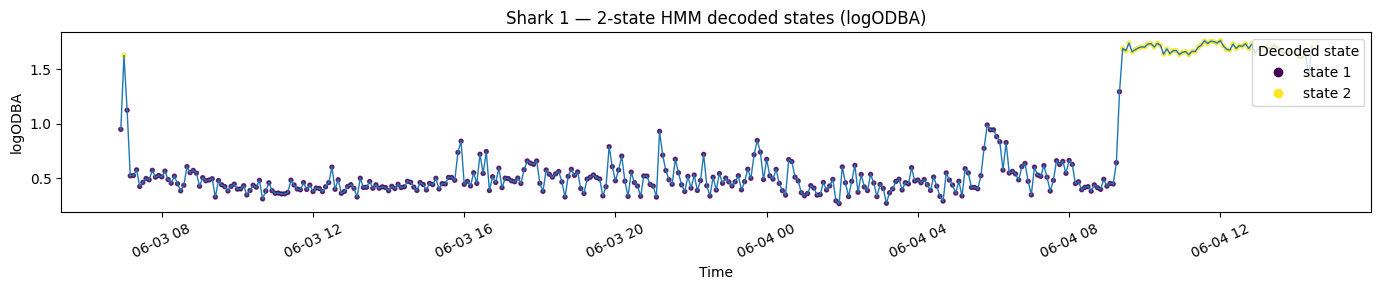

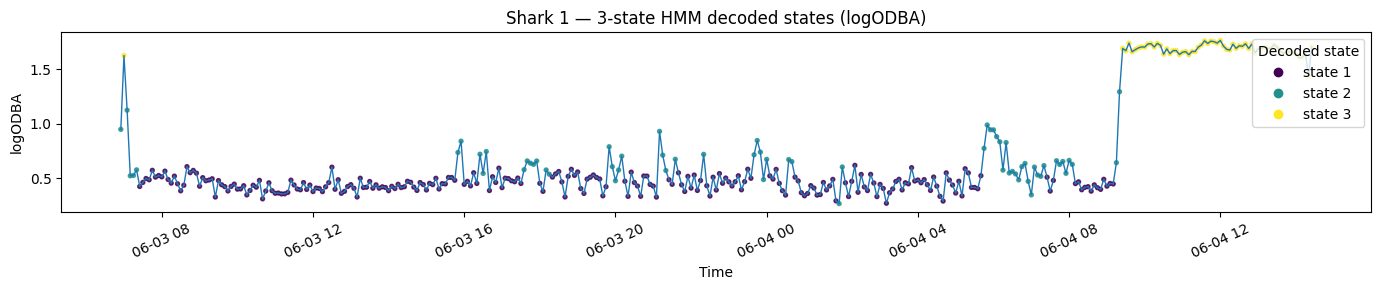

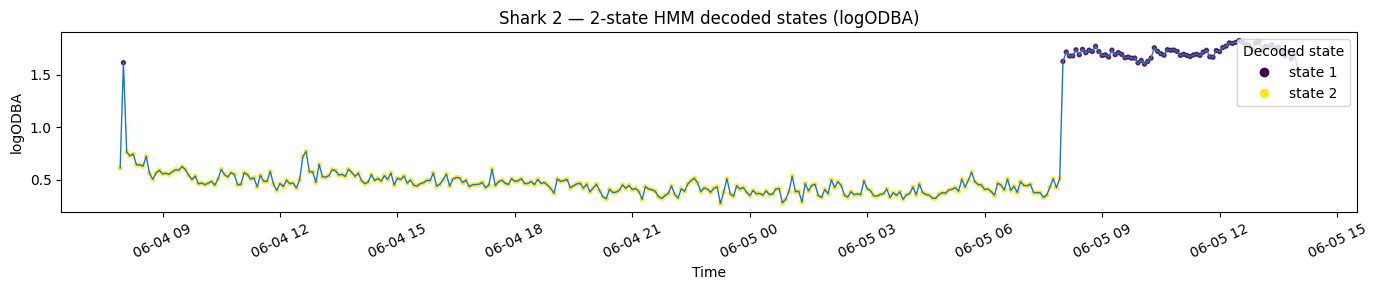

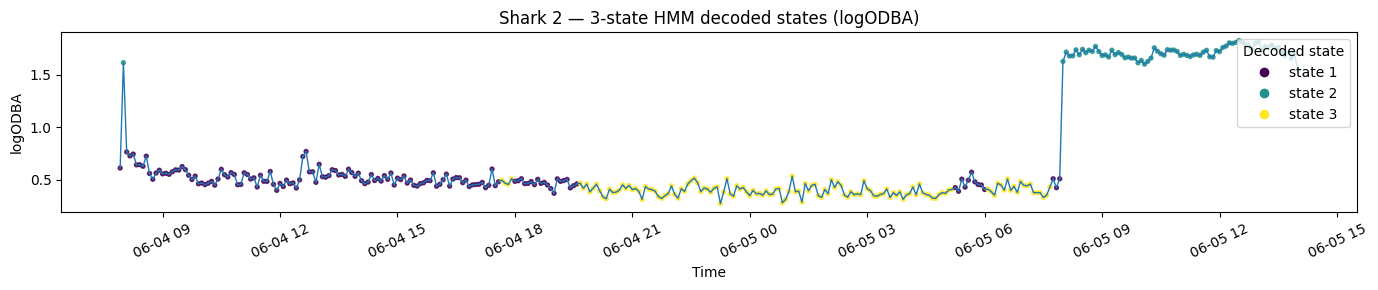

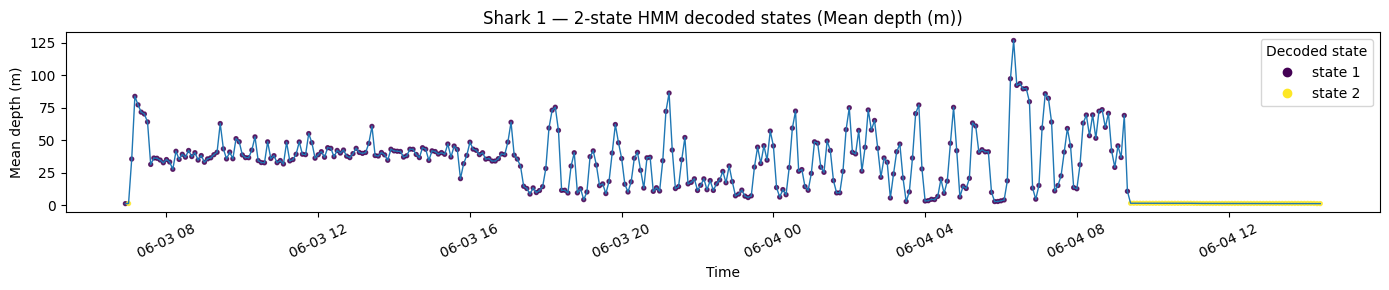

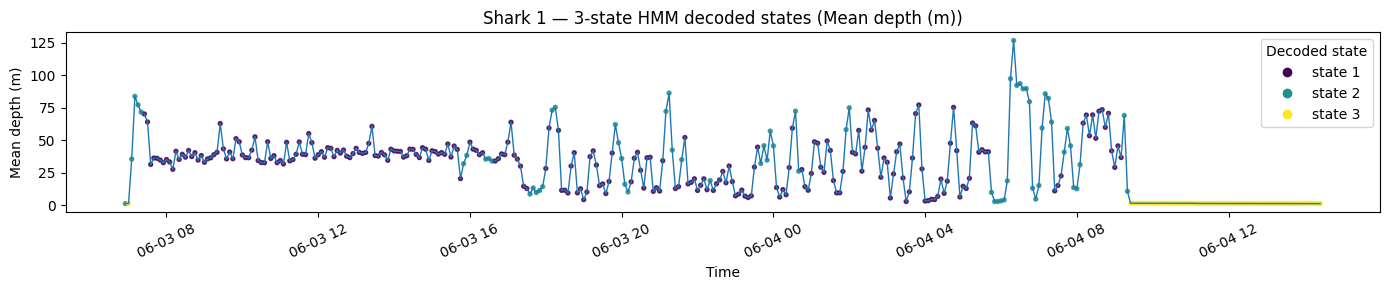

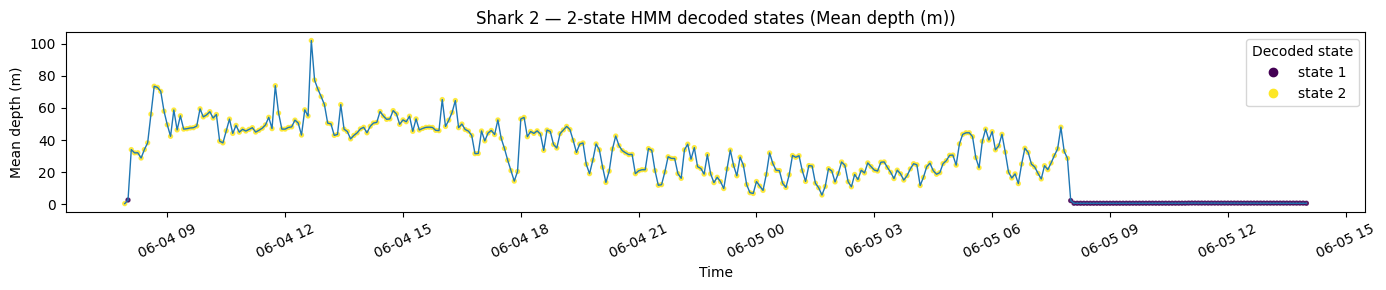

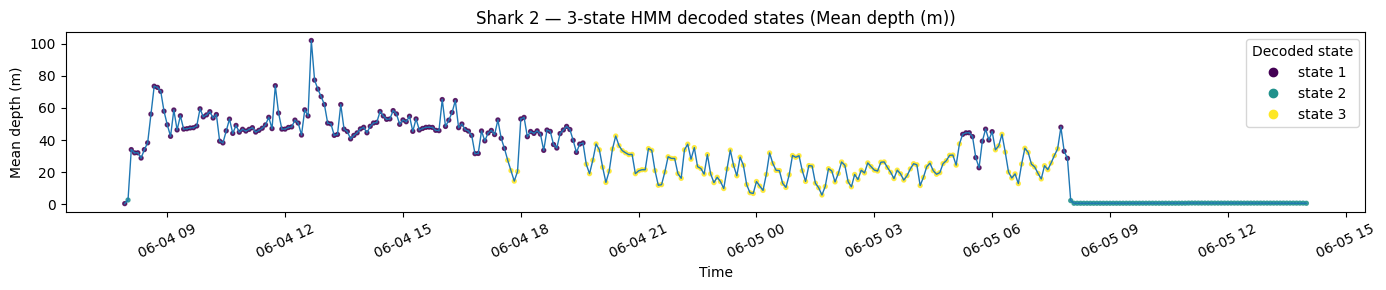

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def plot_decoded_states(df, shark_name, n_states, time_col="time_window",
                        value_col="log_odba", ylabel="logODBA",
                        state_col="state", point_size=8, alpha=0.8, cmap="viridis"):
    d = df[[time_col, value_col, state_col]].dropna().sort_values(time_col).reset_index(drop=True)

    plt.figure(figsize=(14, 3))
    plt.plot(d[time_col], d[value_col], linewidth=1, color="tab:blue")

    sc = plt.scatter(d[time_col], d[value_col], c=d[state_col],
                     s=point_size, alpha=alpha, cmap=cmap)

    state_ids = sorted(d[state_col].unique().astype(int).tolist())
    handles = [
        Line2D([0], [0], marker="o", linestyle="None", markersize=6,
               markerfacecolor=sc.cmap(sc.norm(s)), markeredgecolor=sc.cmap(sc.norm(s)),
               label=f"state {s}")
        for s in state_ids
    ]
    plt.legend(handles=handles, title="Decoded state", loc="upper right", frameon=True)
    plt.title(f"{shark_name} — {n_states}-state HMM decoded states ({ylabel})")
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

# --- logODBA plots ---
plot_decoded_states(shark1_res_2, "Shark 1", 2, value_col="log_odba", ylabel="logODBA")
plot_decoded_states(shark1_res_3, "Shark 1", 3, value_col="log_odba", ylabel="logODBA")
plot_decoded_states(shark2_res_2, "Shark 2", 2, value_col="log_odba", ylabel="logODBA")
plot_decoded_states(shark2_res_3, "Shark 2", 3, value_col="log_odba", ylabel="logODBA")

# --- Depth plots ---
plot_decoded_states(shark1_res_2, "Shark 1", 2, value_col="mean_depth", ylabel="Mean depth (m)")
plot_decoded_states(shark1_res_3, "Shark 1", 3, value_col="mean_depth", ylabel="Mean depth (m)")
plot_decoded_states(shark2_res_2, "Shark 2", 2, value_col="mean_depth", ylabel="Mean depth (m)")
plot_decoded_states(shark2_res_3, "Shark 2", 3, value_col="mean_depth", ylabel="Mean depth (m)")



## 4. Model Comparison & State Summaries

Model comparison (3-state preferred for both sharks):
    shark    model  n_states      logLik         AIC         BIC
0  Shark1  2-state         2 -229.602239  481.204478  524.517377
1  Shark1  3-state         3 -109.023893  258.047786  336.798510
2  Shark2  2-state         2    9.949151    2.101698   44.909784
3  Shark2  3-state         3  232.509281 -425.018561 -347.185677

State-level summaries:
    shark    model  state  mean_depth   sd_depth  mean_odba   sd_odba    n  \
0  Shark1  2-state      1   36.467156  20.550161   0.649520  0.257169  317   
1  Shark1  2-state      2    1.619283   0.064564   4.410421  0.260601   62   
2  Shark1  3-state      1   34.429903  16.397335   0.564555  0.104428  253   
3  Shark1  3-state      2   44.520671  30.987134   0.985399  0.380149   64   
4  Shark1  3-state      3    1.619283   0.064564   4.410421  0.260601   62   
5  Shark2  2-state      1    0.631766   0.294202   4.536598  0.303833   74   
6  Shark2  2-state      2   35.727215  15.845579   

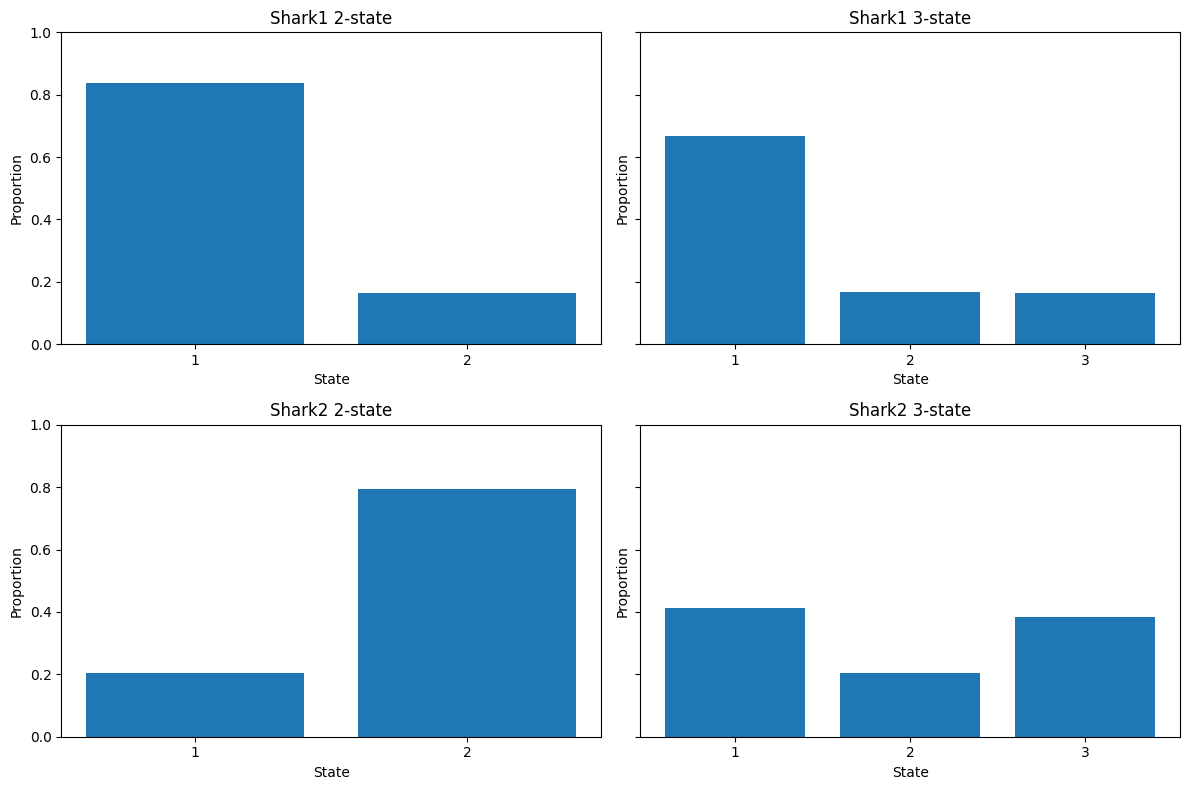

In [33]:
# --- Model comparison (AIC / BIC) ---
model_compare = pd.DataFrame({
    "shark": ["Shark1", "Shark1", "Shark2", "Shark2"],
    "model": ["2-state", "3-state", "2-state", "3-state"],
    "n_states": [2, 3, 2, 3],
    "logLik": [ll_sh1_2, ll_sh1_3, ll_sh2_2, ll_sh2_3],
    "AIC": [aic_sh1_2, aic_sh1_3, aic_sh2_2, aic_sh2_3],
    "BIC": [bic_sh1_2, bic_sh1_3, bic_sh2_2, bic_sh2_3]
}).sort_values(["shark", "n_states"]).reset_index(drop=True)

print("Model comparison (3-state preferred for both sharks):")
print(model_compare)

# --- State-level summaries ---
sh1_2_summary = hmm_summary_table(shark1_res_2).assign(shark="Shark1", model="2-state")
sh1_3_summary = hmm_summary_table(shark1_res_3).assign(shark="Shark1", model="3-state")
sh2_2_summary = hmm_summary_table(shark2_res_2).assign(shark="Shark2", model="2-state")
sh2_3_summary = hmm_summary_table(shark2_res_3).assign(shark="Shark2", model="3-state")

state_compare = pd.concat(
    [sh1_2_summary, sh1_3_summary, sh2_2_summary, sh2_3_summary],
    ignore_index=True
)[["shark", "model", "state", "mean_depth", "sd_depth", "mean_odba", "sd_odba", "n", "prop"]]
state_compare = state_compare.sort_values(["shark", "model", "state"]).reset_index(drop=True)
print("\nState-level summaries:")
print(state_compare)

# --- State proportion bar plots ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
plot_order = [("Shark1", "2-state"), ("Shark1", "3-state"),
              ("Shark2", "2-state"), ("Shark2", "3-state")]

for ax, (shark_name, model_name) in zip(axes.flatten(), plot_order):
    d = state_compare[
        (state_compare["shark"] == shark_name) &
        (state_compare["model"] == model_name)
    ]
    ax.bar(d["state"].astype(str), d["prop"])
    ax.set_title(f"{shark_name} {model_name}")
    ax.set_xlabel("State")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()



## 5. Light Intensity and Decoded States

### chunk 1 Descriptive statistics, distributions, and formal statistical tests

LIGHT INTENSITY: DESCRIPTIVE STATISTICS BY STATE (3-state HMM)

──────────────────────────────────────────────────────────────────────────────────────────
  Shark 1
──────────────────────────────────────────────────────────────────────────────────────────

  Variable: mean_light_1
  State        n       Mean         SD     Median          IQR        Min        Max
  S1         253    15780.1    16494.8     7258.6      0–36390        0.0    37177.0
  S2          64     9997.2    13751.8      457.3      0–22206        0.0    36762.6
  S3          62    19947.4     3693.6    19151.0  17992–20146    16779.5    37177.0

  Variable: mean_light_2
  State        n       Mean         SD     Median          IQR        Min        Max
  S1         253     5802.9    10543.8      267.2       0–4320        0.0    36783.7
  S2          64     1622.6     4776.0       12.3       0–1112        0.0    33280.5
  S3          62     5310.4     6202.5     4038.8    2626–4833     2174.6    37141.1

───────────


  mean_light_1:
    Kruskal-Wallis H = 11.81, p = 2.73e-03, η² ≈ 0.026
    Pairwise Mann-Whitney U (Bonferroni corrected, 3 comparisons):
      S1 vs S2: U = 9071, p_adj = 0.3799 ns, r = -0.120
      S1 vs S3: U = 6620, p_adj = 0.1598 ns, r = 0.156
      S2 vs S3: U = 1010, p_adj = 0.0000 ***, r = 0.491

  mean_light_2:
    Kruskal-Wallis H = 49.44, p = 1.84e-11, η² ≈ 0.126
    Pairwise Mann-Whitney U (Bonferroni corrected, 3 comparisons):
      S1 vs S2: U = 8716, p_adj = 0.9892 ns, r = -0.077
      S1 vs S3: U = 4142, p_adj = 0.0000 ***, r = 0.472
      S2 vs S3: U = 362, p_adj = 0.0000 ***, r = 0.818

--- Shark 2 ---

  mean_light_1:
    Kruskal-Wallis H = 185.38, p = 5.56e-41, η² ≈ 0.511
    Pairwise Mann-Whitney U (Bonferroni corrected, 3 comparisons):
      S1 vs S2: U = 3881, p_adj = 0.0010 ***, r = 0.296
      S1 vs S3: U = 18642, p_adj = 0.0000 ***, r = -0.800
      S2 vs S3: U = 9590, p_adj = 0.0000 ***, r = -0.865

  mean_light_2:
    Kruskal-Wallis H = 256.69, p = 1.83e-56

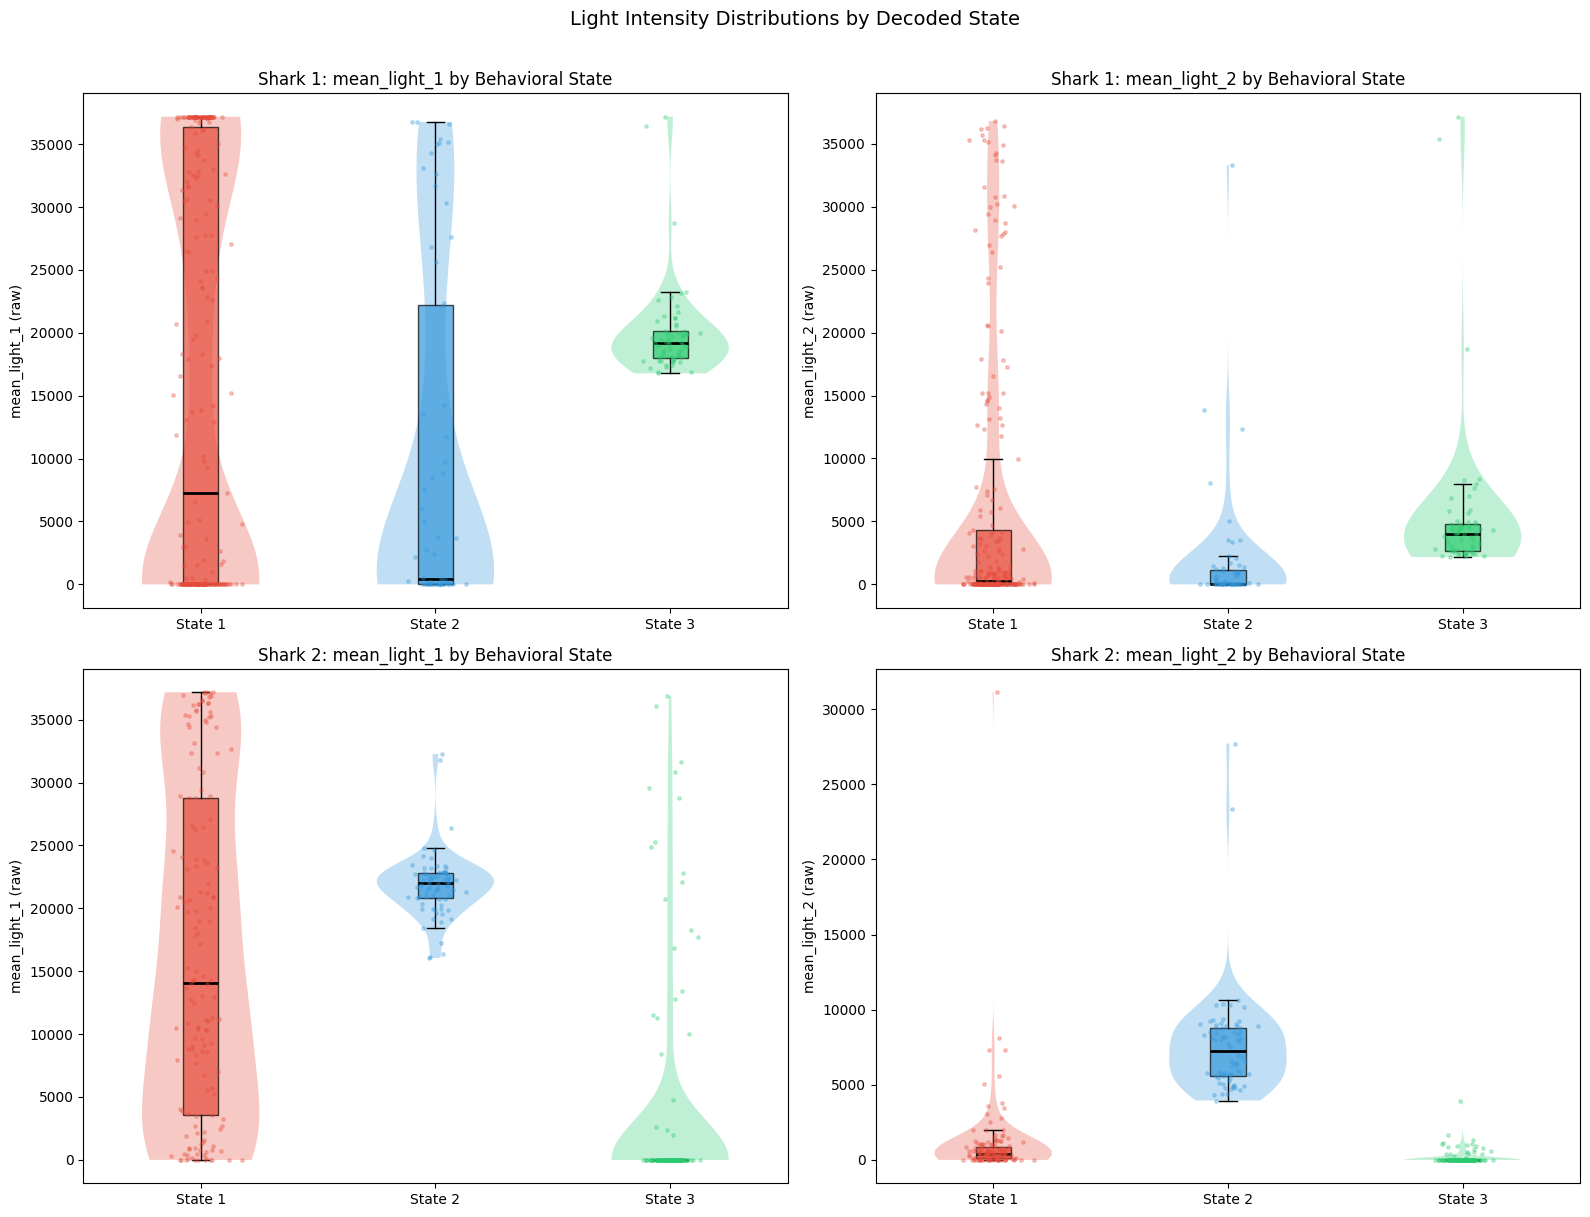

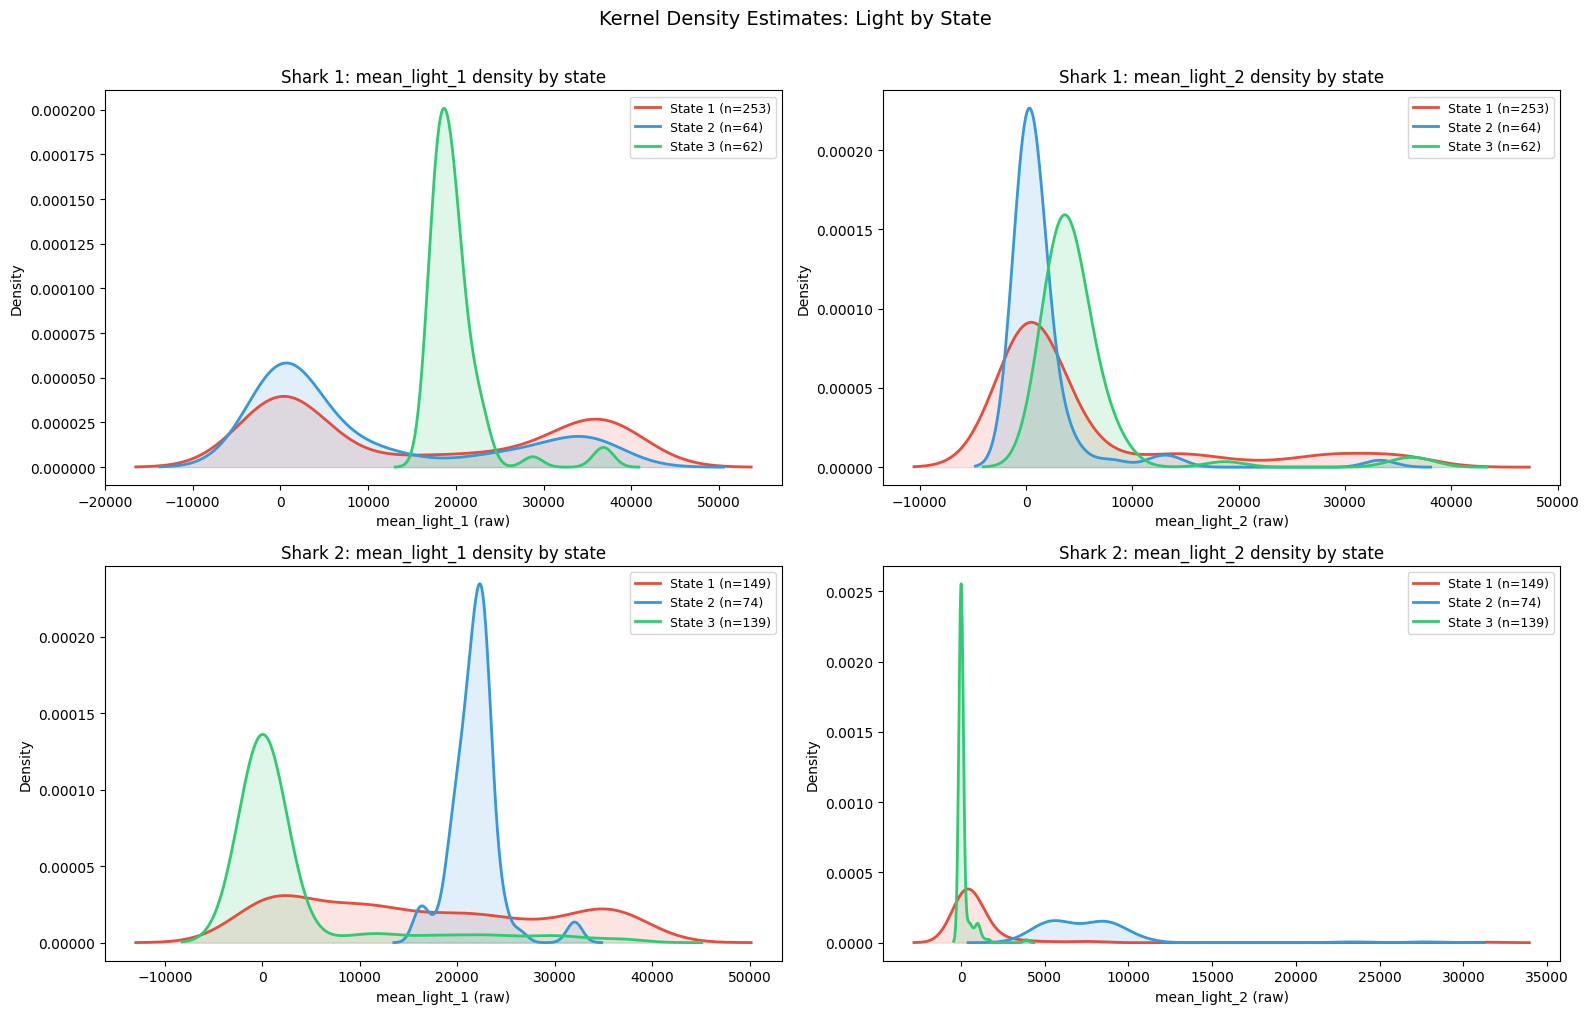

In [34]:
# =============================================================================
# LIGHT INTENSITY ANALYSIS — CHUNK 1/3
# Descriptive statistics, distributions, and formal statistical tests
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- 1a. Detailed summary statistics by state ----
print("=" * 90)
print("LIGHT INTENSITY: DESCRIPTIVE STATISTICS BY STATE (3-state HMM)")
print("=" * 90)

for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    print(f"\n{'─'*90}")
    print(f"  {name}")
    print(f"{'─'*90}")
    for light_col in ["mean_light_1", "mean_light_2"]:
        print(f"\n  Variable: {light_col}")
        print(f"  {'State':<8} {'n':>5} {'Mean':>10} {'SD':>10} {'Median':>10} "
              f"{'IQR':>12} {'Min':>10} {'Max':>10}")
        for s in sorted(df["state"].unique()):
            vals = df.loc[df["state"] == s, light_col].dropna()
            q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
            print(f"  S{s:<7} {len(vals):>5} {vals.mean():>10.1f} {vals.std():>10.1f} "
                  f"{vals.median():>10.1f} {f'{q1:.0f}–{q3:.0f}':>12} "
                  f"{vals.min():>10.1f} {vals.max():>10.1f}")

# ---- 1b. Kruskal-Wallis + pairwise Mann-Whitney U tests ----
print(f"\n{'='*90}")
print("STATISTICAL TESTS: DO STATES DIFFER IN LIGHT INTENSITY?")
print(f"{'='*90}")

from itertools import combinations

for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    print(f"\n--- {name} ---")
    for light_col in ["mean_light_1", "mean_light_2"]:
        groups = [df.loc[df["state"] == s, light_col].dropna().values
                  for s in sorted(df["state"].unique())]
        state_ids = sorted(df["state"].unique())

        # Kruskal-Wallis (non-parametric ANOVA)
        kw_stat, kw_p = stats.kruskal(*groups)
        # Effect size: eta-squared approximation
        n_total = sum(len(g) for g in groups)
        eta_sq = (kw_stat - len(groups) + 1) / (n_total - len(groups))
        eta_sq = max(0, eta_sq)

        print(f"\n  {light_col}:")
        print(f"    Kruskal-Wallis H = {kw_stat:.2f}, p = {kw_p:.2e}, η² ≈ {eta_sq:.3f}")

        # Pairwise Mann-Whitney U with Bonferroni correction
        pairs = list(combinations(range(len(groups)), 2))
        n_comparisons = len(pairs)
        print(f"    Pairwise Mann-Whitney U (Bonferroni corrected, {n_comparisons} comparisons):")
        for i, j in pairs:
            u_stat, u_p = stats.mannwhitneyu(groups[i], groups[j], alternative="two-sided")
            adj_p = min(u_p * n_comparisons, 1.0)
            # rank-biserial correlation as effect size
            n1, n2 = len(groups[i]), len(groups[j])
            r_rb = 1 - (2 * u_stat) / (n1 * n2)
            sig = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else "ns"
            print(f"      S{state_ids[i]} vs S{state_ids[j]}: "
                  f"U = {u_stat:.0f}, p_adj = {adj_p:.4f} {sig}, r = {r_rb:.3f}")

# ---- 1c. Violin + box + strip plots ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors_map = {1: "#e74c3c", 2: "#3498db", 3: "#2ecc71"}

for row_idx, (df, name) in enumerate([(shark1_res_3, "Shark 1"),
                                       (shark2_res_3, "Shark 2")]):
    for col_idx, light_col in enumerate(["mean_light_1", "mean_light_2"]):
        ax = axes[row_idx, col_idx]
        state_ids = sorted(df["state"].unique())
        data_by_state = [df.loc[df["state"] == s, light_col].dropna().values
                         for s in state_ids]

        # Violin plot
        parts = ax.violinplot(data_by_state, positions=state_ids,
                              showmedians=False, showextrema=False)
        for idx, body in enumerate(parts["bodies"]):
            body.set_facecolor(colors_map[state_ids[idx]])
            body.set_alpha(0.3)

        # Box plot overlay
        bp = ax.boxplot(data_by_state, positions=state_ids, widths=0.15,
                        patch_artist=True, showfliers=False,
                        medianprops={"color": "black", "linewidth": 2})
        for idx, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(colors_map[state_ids[idx]])
            patch.set_alpha(0.7)

        # Strip plot (jittered raw points)
        for idx, s in enumerate(state_ids):
            vals = data_by_state[idx]
            jitter = np.random.default_rng(42).normal(0, 0.06, len(vals))
            ax.scatter(s + jitter, vals, s=6, alpha=0.3,
                       color=colors_map[s], zorder=3)

        ax.set_xticks(state_ids)
        ax.set_xticklabels([f"State {s}" for s in state_ids])
        ax.set_ylabel(f"{light_col} (raw)")
        ax.set_title(f"{name}: {light_col} by Behavioral State")

plt.suptitle("Light Intensity Distributions by Decoded State", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("light_analysis_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 1d. Overlapping density plots ----
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row_idx, (df, name) in enumerate([(shark1_res_3, "Shark 1"),
                                       (shark2_res_3, "Shark 2")]):
    for col_idx, light_col in enumerate(["mean_light_1", "mean_light_2"]):
        ax = axes[row_idx, col_idx]
        for s in sorted(df["state"].unique()):
            vals = df.loc[df["state"] == s, light_col].dropna()
            # KDE
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(vals, bw_method=0.3)
            x_grid = np.linspace(vals.min() - vals.std(), vals.max() + vals.std(), 300)
            ax.plot(x_grid, kde(x_grid), color=colors_map[s], linewidth=2,
                    label=f"State {s} (n={len(vals)})")
            ax.fill_between(x_grid, kde(x_grid), color=colors_map[s], alpha=0.15)

        ax.set_xlabel(f"{light_col} (raw)")
        ax.set_ylabel("Density")
        ax.set_title(f"{name}: {light_col} density by state")
        ax.legend(fontsize=9)

plt.suptitle("Kernel Density Estimates: Light by State", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("light_analysis_density.png", dpi=150, bbox_inches="tight")
plt.show()

### chunk 2 Relationships

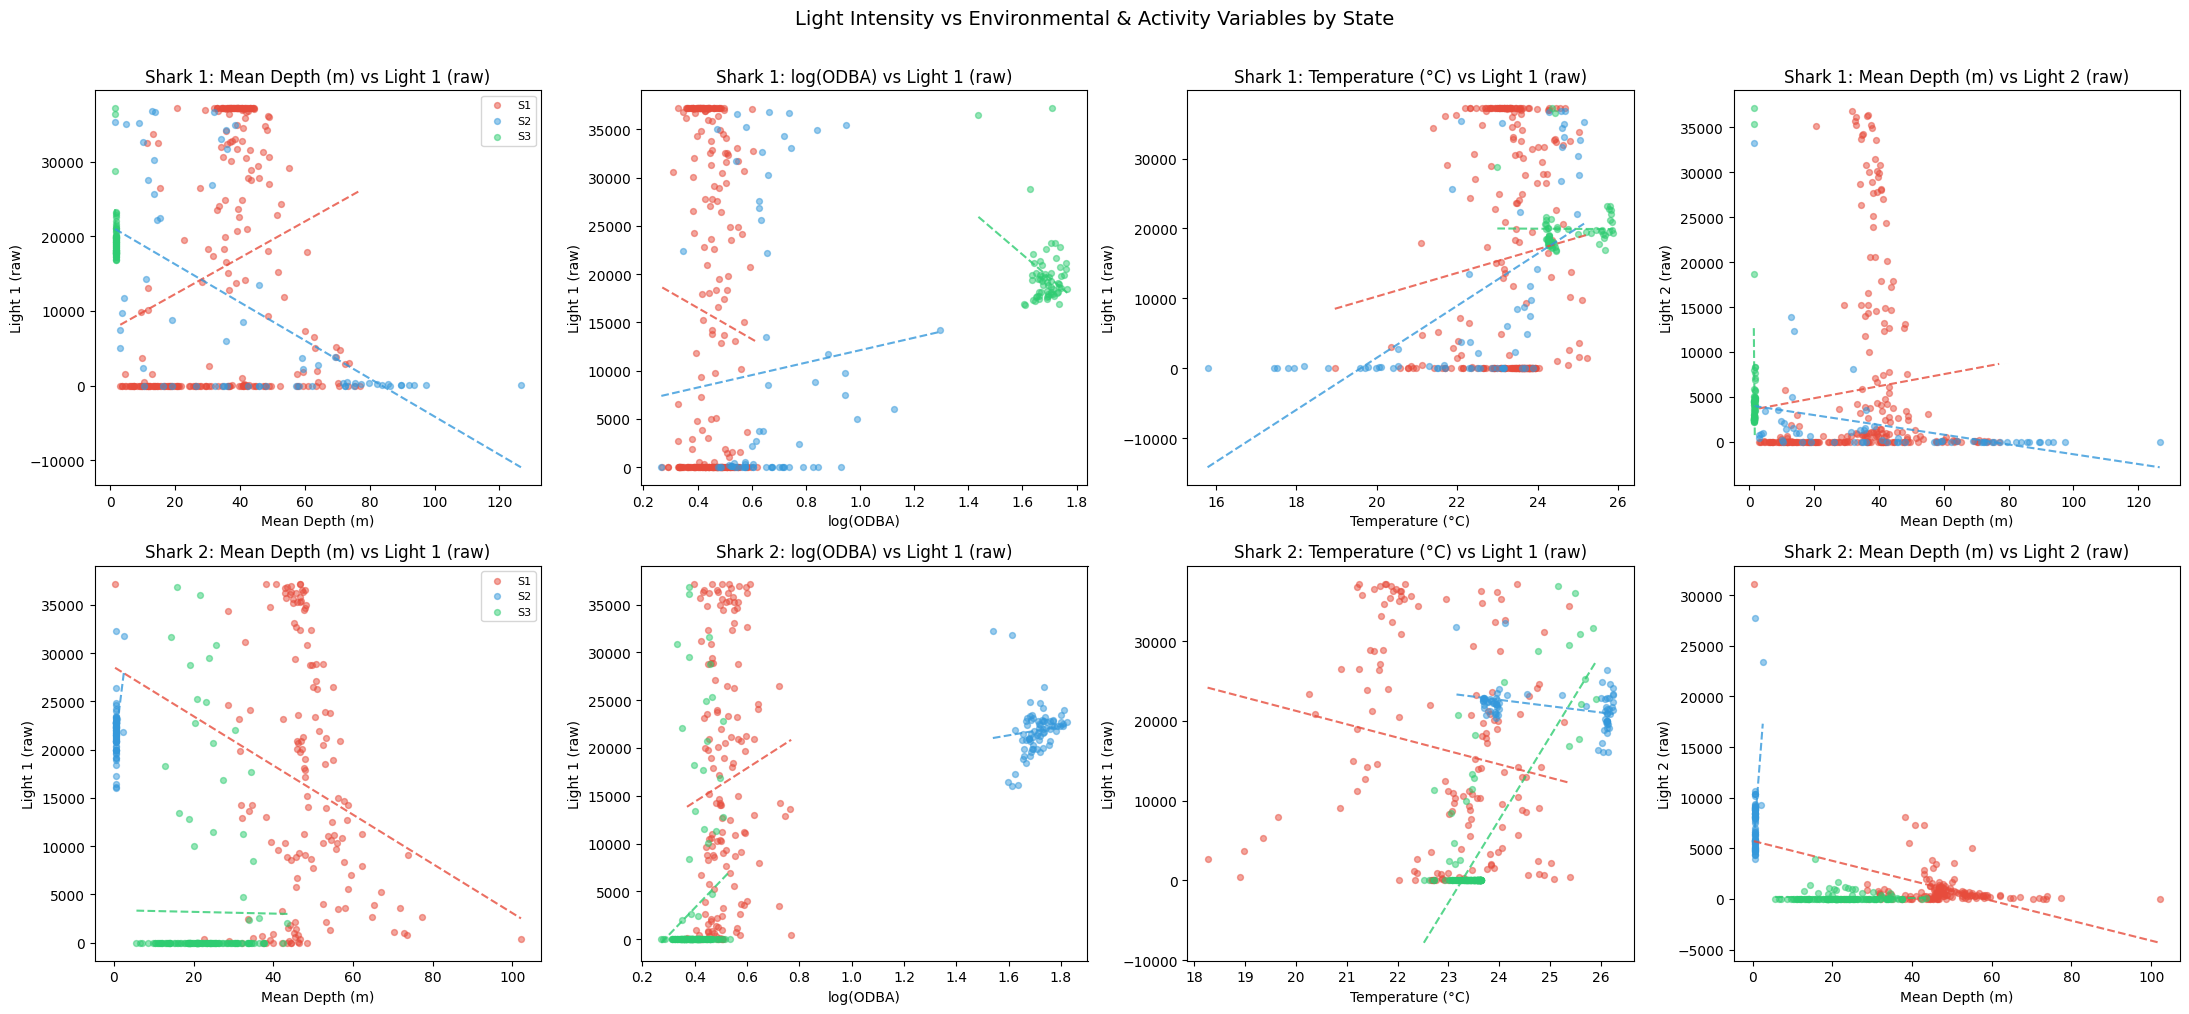

WITHIN-STATE CORRELATIONS WITH LIGHT INTENSITY

--- Shark 1 ---
                                 State 1             State 2             State 3
  Light1 vs Depth     r= 0.32 (p=0.000)***  r=-0.50 (p=0.000)***  r=-0.08 (p=0.526)   
  Light1 vs log(ODBA)  r=-0.11 (p=0.091)     r= 0.13 (p=0.303)     r= 0.11 (p=0.392)   
  Light1 vs Temperature  r=-0.08 (p=0.179)     r= 0.57 (p=0.000)***  r= 0.16 (p=0.216)   
  Light1 vs Light 2   r= 0.98 (p=0.000)***  r= 0.99 (p=0.000)***  r= 0.88 (p=0.000)***

--- Shark 2 ---
                                 State 1             State 2             State 3
  Light1 vs Depth     r=-0.06 (p=0.466)     r= 0.31 (p=0.008) **  r= 0.11 (p=0.183)   
  Light1 vs log(ODBA)  r= 0.19 (p=0.019)  *  r= 0.37 (p=0.001) **  r= 0.22 (p=0.009) **
  Light1 vs Temperature  r=-0.20 (p=0.013)  *  r=-0.23 (p=0.046)  *  r= 0.21 (p=0.012)  *
  Light1 vs Light 2   r= 0.99 (p=0.000)***  r= 0.61 (p=0.000)***  r= 1.00 (p=0.000)***


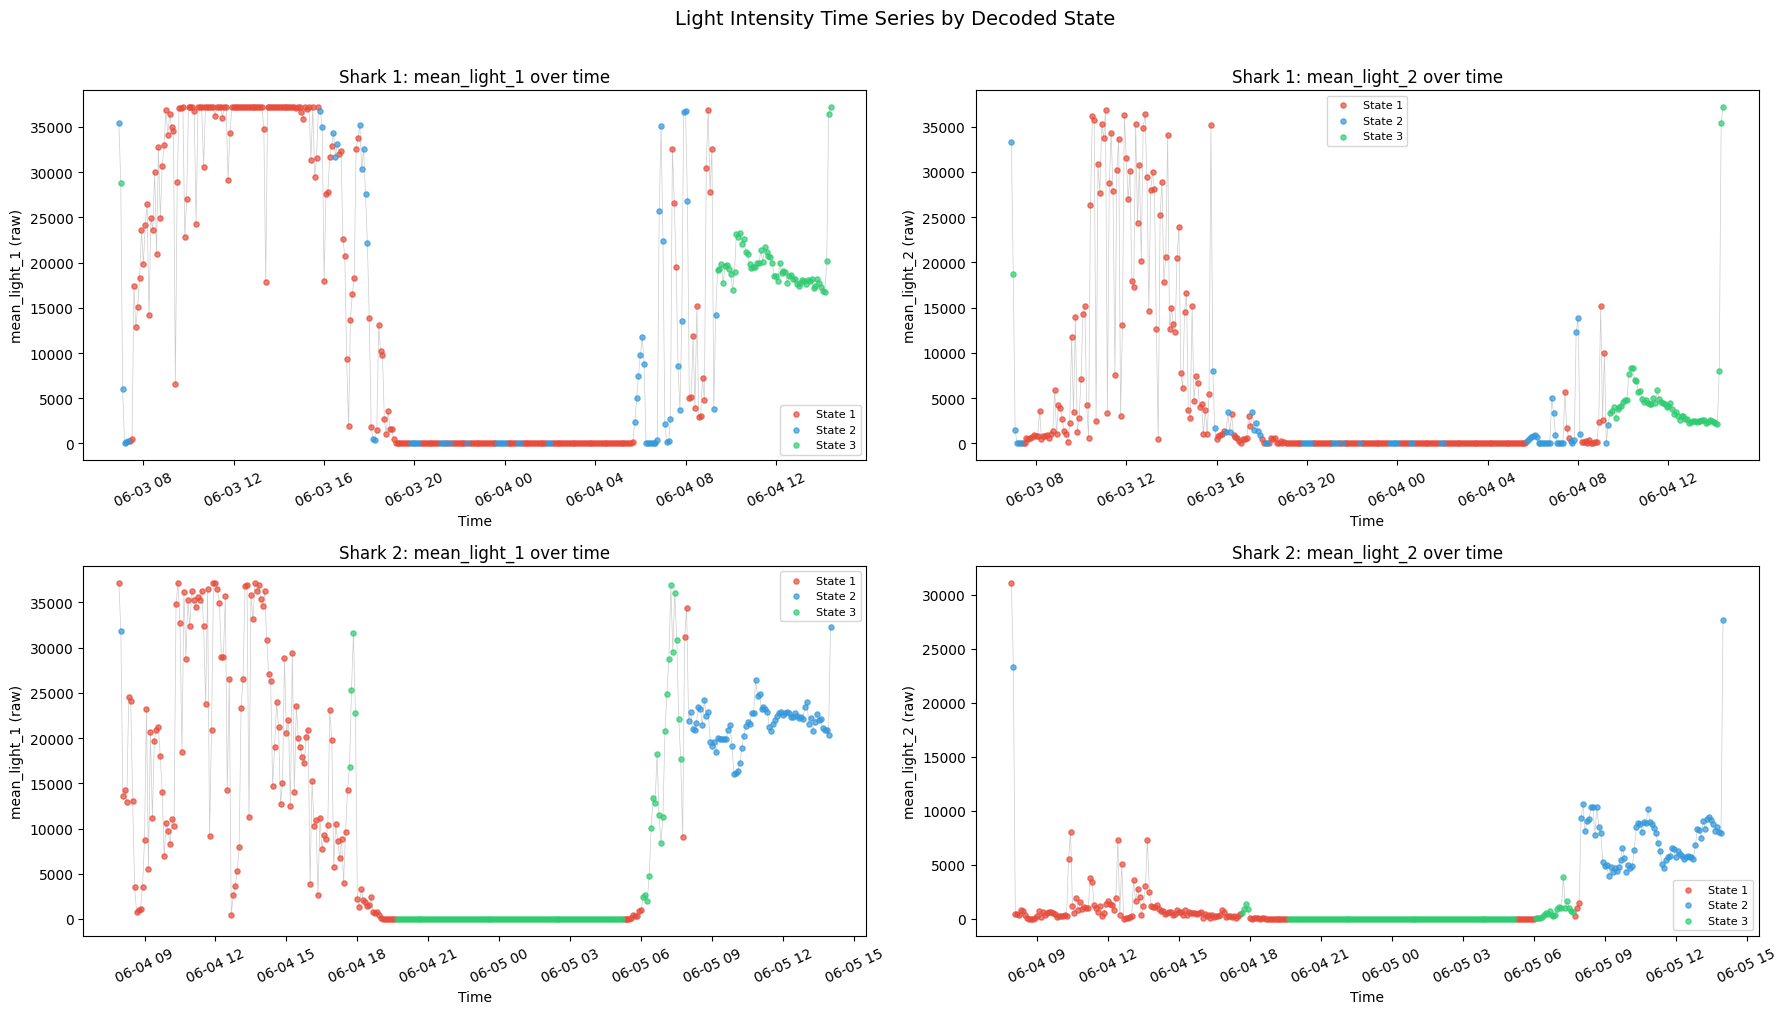

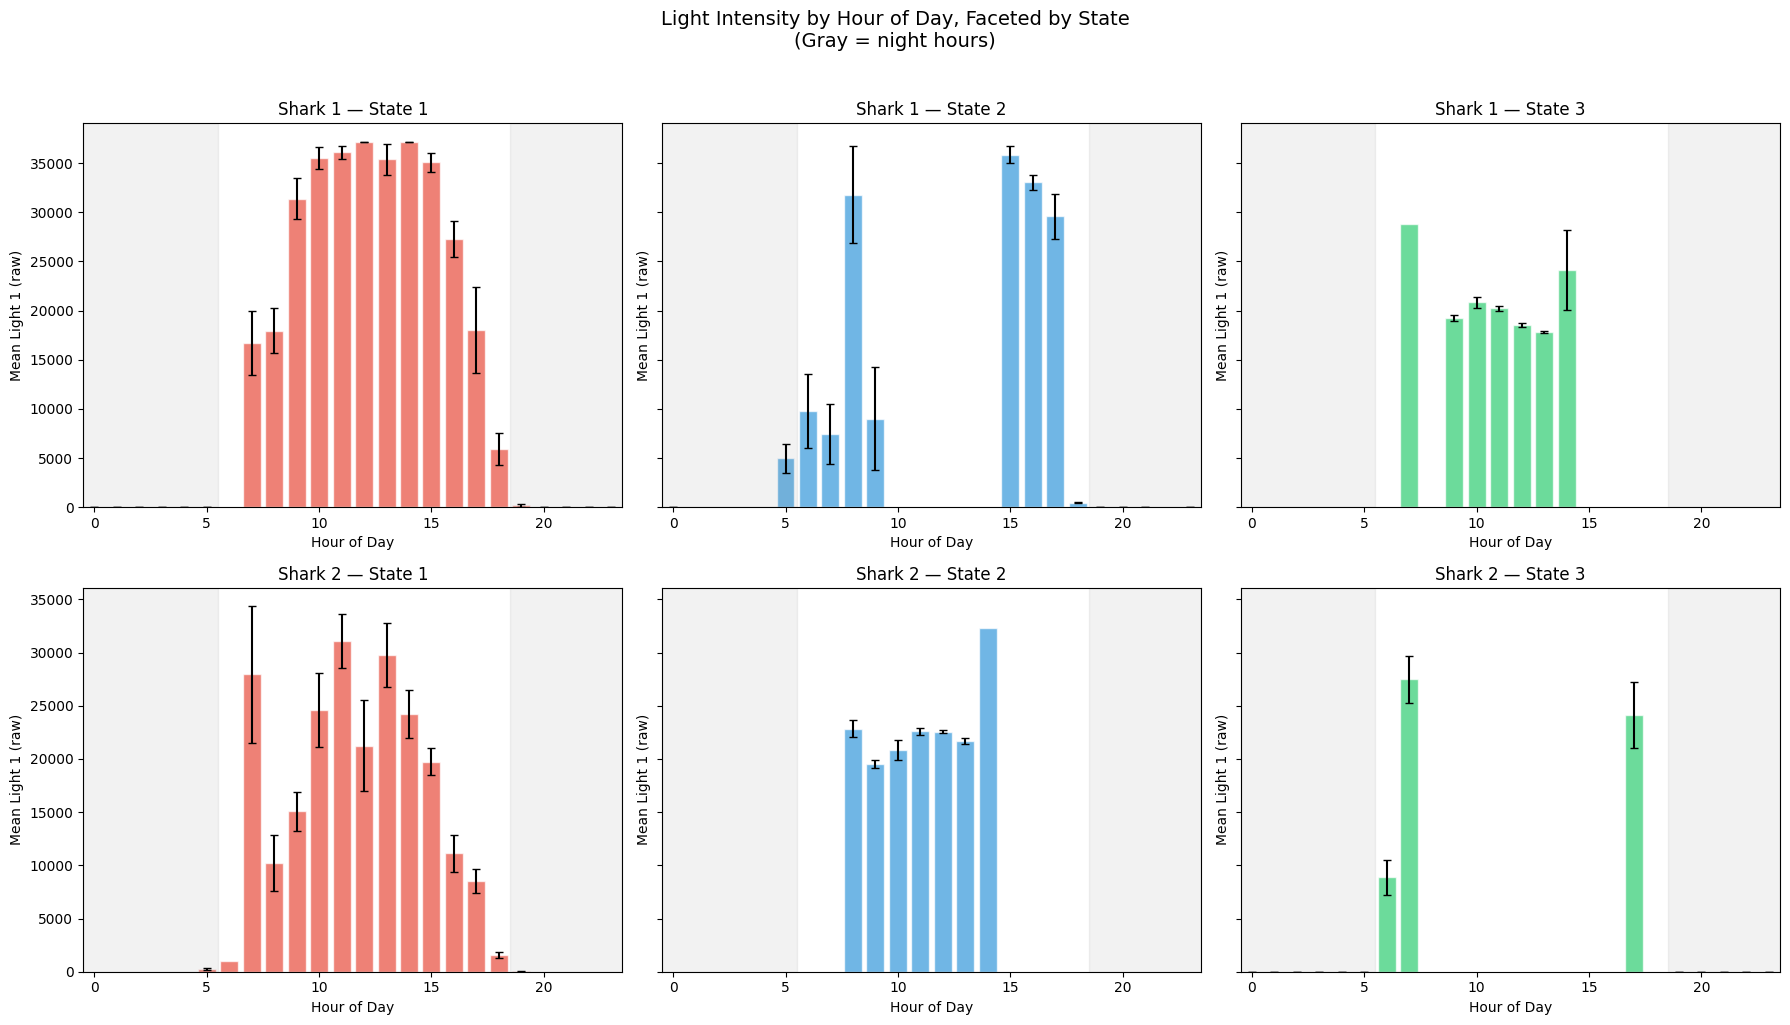

In [35]:
# =============================================================================
# LIGHT INTENSITY ANALYSIS — CHUNK 2/3
# Relationships: light vs depth, ODBA, temperature; temporal patterns;
# within-state correlations
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

colors_map = {1: "#e74c3c", 2: "#3498db", 3: "#2ecc71"}

# ---- 2a. Scatter matrix: light vs depth, ODBA, temp — colored by state ----
scatter_pairs = [
    ("mean_depth",  "mean_light_1", "Mean Depth (m)",    "Light 1 (raw)"),
    ("log_odba",    "mean_light_1", "log(ODBA)",         "Light 1 (raw)"),
    ("mean_temp",   "mean_light_1", "Temperature (°C)",  "Light 1 (raw)"),
    ("mean_depth",  "mean_light_2", "Mean Depth (m)",    "Light 2 (raw)"),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for row_idx, (df, name) in enumerate([(shark1_res_3, "Shark 1"),
                                       (shark2_res_3, "Shark 2")]):
    for col_idx, (xvar, yvar, xlabel, ylabel) in enumerate(scatter_pairs):
        ax = axes[row_idx, col_idx]
        for s in sorted(df["state"].unique()):
            mask = df["state"] == s
            ax.scatter(df.loc[mask, xvar], df.loc[mask, yvar],
                       s=18, alpha=0.5, color=colors_map[s], label=f"S{s}")
            # Per-state regression line
            sub = df.loc[mask, [xvar, yvar]].dropna()
            if len(sub) > 5:
                slope, intercept, r, p, se = stats.linregress(sub[xvar], sub[yvar])
                x_line = np.linspace(sub[xvar].min(), sub[xvar].max(), 50)
                ax.plot(x_line, slope * x_line + intercept,
                        color=colors_map[s], linewidth=1.5, linestyle="--", alpha=0.8)

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name}: {xlabel} vs {ylabel}")
        if col_idx == 0:
            ax.legend(fontsize=8)

plt.suptitle("Light Intensity vs Environmental & Activity Variables by State",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("light_analysis_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 2b. Within-state correlation table ----
print("=" * 90)
print("WITHIN-STATE CORRELATIONS WITH LIGHT INTENSITY")
print("=" * 90)

corr_vars = [("mean_depth", "Depth"), ("log_odba", "log(ODBA)"),
             ("mean_temp", "Temperature"), ("mean_light_2", "Light 2")]

for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    print(f"\n--- {name} ---")
    print(f"  {'':>18}", end="")
    for s in sorted(df["state"].unique()):
        print(f"  {'State '+str(s):>18}", end="")
    print()

    for var, label in corr_vars:
        print(f"  Light1 vs {label:<8}", end="")
        for s in sorted(df["state"].unique()):
            sub = df.loc[df["state"] == s, ["mean_light_1", var]].dropna()
            if len(sub) > 3:
                r, p = stats.spearmanr(sub["mean_light_1"], sub[var])
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
                print(f"  r={r:>5.2f} (p={p:.3f}){sig:>3}", end="")
            else:
                print(f"  {'n/a':>18}", end="")
        print()

# ---- 2c. Light intensity time series colored by state ----
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for row_idx, (df, name) in enumerate([(shark1_res_3, "Shark 1"),
                                       (shark2_res_3, "Shark 2")]):
    for col_idx, light_col in enumerate(["mean_light_1", "mean_light_2"]):
        ax = axes[row_idx, col_idx]

        # Background line
        ax.plot(df["time_window"], df[light_col], color="gray",
                linewidth=0.5, alpha=0.4, zorder=1)

        for s in sorted(df["state"].unique()):
            mask = df["state"] == s
            ax.scatter(df.loc[mask, "time_window"], df.loc[mask, light_col],
                       s=14, alpha=0.7, color=colors_map[s], label=f"State {s}", zorder=2)

        ax.set_xlabel("Time")
        ax.set_ylabel(f"{light_col} (raw)")
        ax.set_title(f"{name}: {light_col} over time")
        ax.legend(fontsize=8)
        ax.tick_params(axis="x", rotation=25)

plt.suptitle("Light Intensity Time Series by Decoded State", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("light_analysis_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 2d. Light by hour of day, faceted by state ----
for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    df["hour"] = df["time_window"].dt.hour

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey="row")

for row_idx, (df, name) in enumerate([(shark1_res_3, "Shark 1"),
                                       (shark2_res_3, "Shark 2")]):
    for col_idx, s in enumerate(sorted(df["state"].unique())):
        ax = axes[row_idx, col_idx]
        sub = df[df["state"] == s]
        hourly = sub.groupby("hour")["mean_light_1"].agg(["mean", "std", "count"]).reset_index()
        hourly["se"] = hourly["std"] / np.sqrt(hourly["count"])

        ax.bar(hourly["hour"], hourly["mean"], yerr=hourly["se"],
               color=colors_map[s], alpha=0.7, capsize=3, edgecolor="white")
        ax.axvspan(-0.5, 5.5, color="gray", alpha=0.1)
        ax.axvspan(18.5, 23.5, color="gray", alpha=0.1)
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Mean Light 1 (raw)")
        ax.set_title(f"{name} — State {s}")
        ax.set_xlim(-0.5, 23.5)

plt.suptitle("Light Intensity by Hour of Day, Faceted by State\n(Gray = night hours)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("light_analysis_hourly_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

### chunk 3 Discriminative Power — Can Light Predict State? + HMM with Light

LOGISTIC REGRESSION: CAN LIGHT PREDICT DECODED STATE?

  Shark 1 — Depth + ODBA only:
    Accuracy = 92.9%
    State 1: precision=0.92, recall=0.99, F1=0.95
    State 2: precision=0.93, recall=0.62, F1=0.75
    State 3: precision=0.98, recall=1.00, F1=0.99

  Shark 1 — Depth + ODBA + Light:
    Accuracy = 93.1%
    State 1: precision=0.92, recall=0.99, F1=0.95
    State 2: precision=0.93, recall=0.64, F1=0.76
    State 3: precision=0.98, recall=1.00, F1=0.99

  → Accuracy gain from adding light: +0.3%

  Shark 2 — Depth + ODBA only:
    Accuracy = 95.9%
    State 1: precision=0.96, recall=0.94, F1=0.95
    State 2: precision=1.00, recall=1.00, F1=1.00
    State 3: precision=0.94, recall=0.96, F1=0.95

  Shark 2 — Depth + ODBA + Light:
    Accuracy = 97.5%
    State 1: precision=0.98, recall=0.96, F1=0.97
    State 2: precision=1.00, recall=1.00, F1=1.00
    State 3: precision=0.96, recall=0.98, F1=0.97

  → Accuracy gain from adding light: +1.7%


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

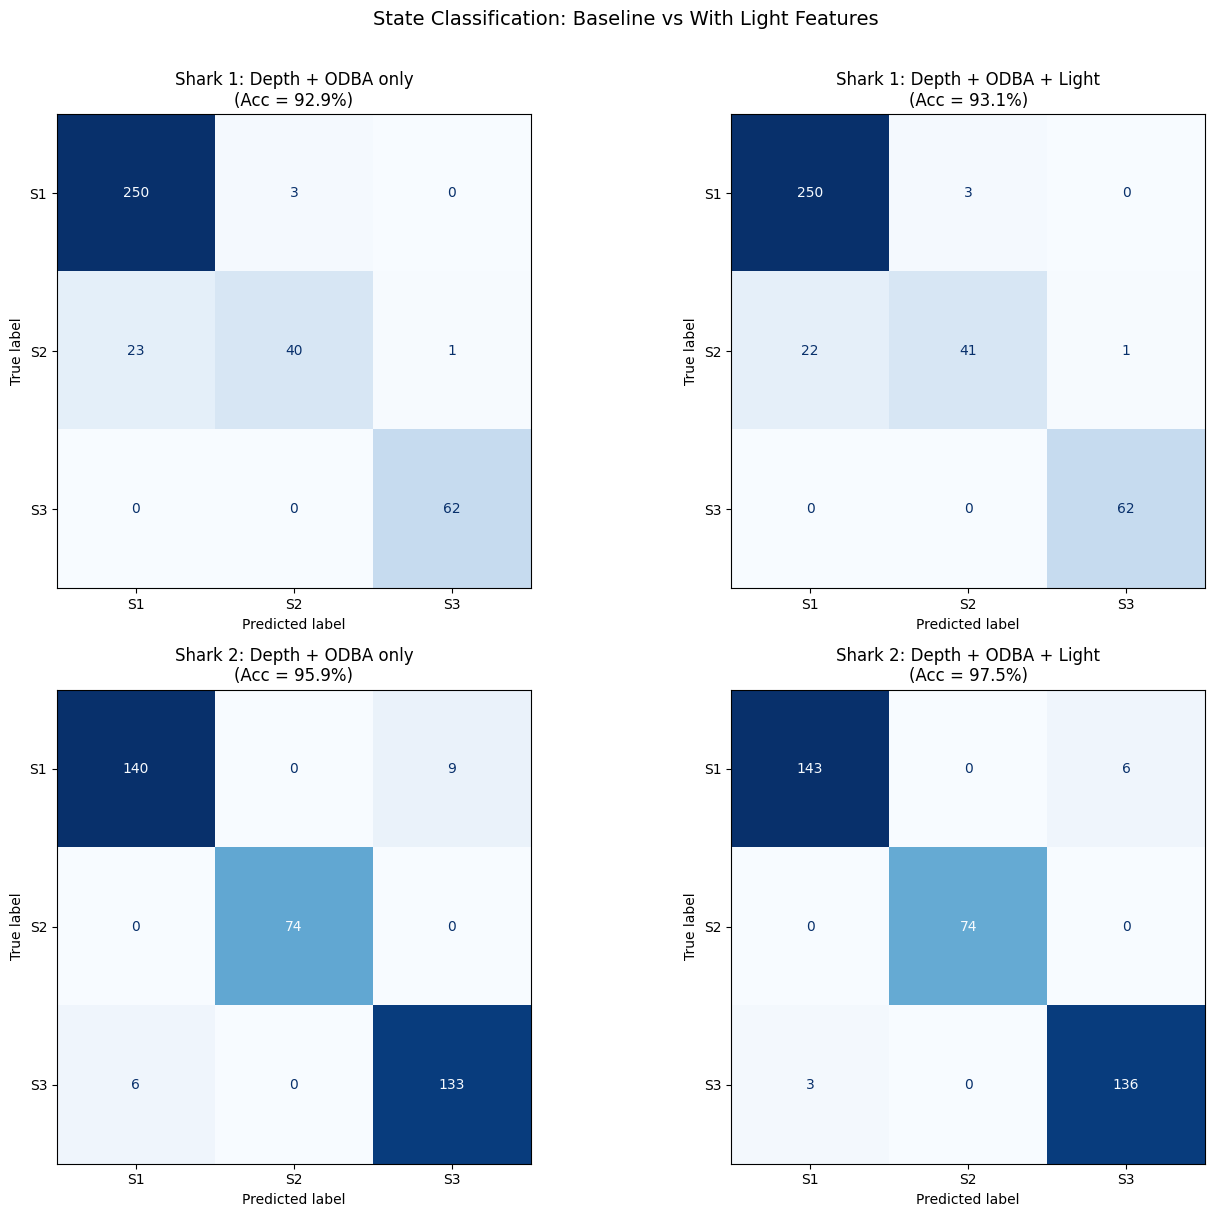


LOGISTIC REGRESSION COEFFICIENTS (full model: depth + ODBA + light)

  Shark 1 — Standardized coefficients:
    mean_depth  log_odba  mean_light_1  mean_light_2
S1       0.096    -4.649        -0.251         0.368
S2       0.773     1.098        -0.227        -0.123
S3      -0.869     3.551         0.478        -0.245

  Shark 2 — Standardized coefficients:
    mean_depth  log_odba  mean_light_1  mean_light_2
S1       2.968     0.439         0.334         0.464
S2      -0.882     2.011         0.188         0.111
S3      -2.086    -2.450        -0.522        -0.575

HMM MODEL COMPARISON: 2-VARIABLE vs 3-VARIABLE (adding light)

  Shark 1 — 3-variable HMM state summary:
 state_3v  mean_depth  sd_depth  mean_odba   mean_light   n     prop
        1   36.037569 25.827480   0.632128    28.536625 144 0.379947
        2    1.619283  0.064564   4.410421 19947.397468  62 0.163588
        3   36.824731 14.865989   0.663997 26751.841341 173 0.456464


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Shark 2 — 3-variable HMM state summary:
 state_3v  mean_depth  sd_depth  mean_odba   mean_light   n     prop
        1    0.631766  0.294202   4.536598 21839.091713  74 0.204420
        2   45.035169 13.578192   0.660580 17985.880283 160 0.441989
        3   24.092272  9.539209   0.490336     3.019349 128 0.353591

──────────────────────────────────────────────────────────────────────────────────────────
  HMM Model Comparison Table:
──────────────────────────────────────────────────────────────────────────────────────────
  Shark                Model  n_features      logLik  n_params         AIC         BIC
Shark 1         Depth + ODBA           2 -109.023893        20  258.047786  336.798510
Shark 1 Depth + ODBA + Light           3   42.192131        26  -32.384262   69.991679
Shark 2         Depth + ODBA           2  232.509281        20 -425.018561 -347.185677
Shark 2 Depth + ODBA + Light           3  436.770971        26 -821.541941 -720.359192

  Shark 1: ΔAIC = -290.4, ΔBIC =

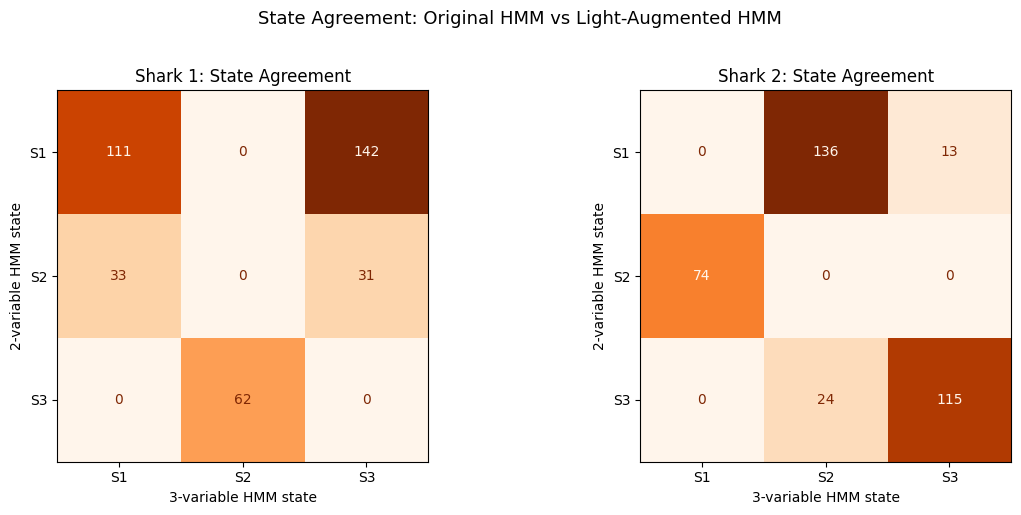


SUMMARY

Key questions answered:
1. Do states differ in light intensity?     → See Kruskal-Wallis & pairwise tests
2. Is light redundant with depth?           → See within-state correlations
3. Does light improve state classification? → See logistic regression accuracy gain
4. Does light improve the HMM itself?       → See AIC/BIC comparison (2-var vs 3-var)
5. Does adding light change state decoding? → See state agreement analysis



In [36]:
# =============================================================================
# LIGHT INTENSITY ANALYSIS — CHUNK 3/3
# Discriminative power: logistic regression, confusion matrix,
# HMM refitted with light as 3rd observation variable
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

colors_map = {1: "#e74c3c", 2: "#3498db", 3: "#2ecc71"}

# =====================================================================
# 3a. MULTINOMIAL LOGISTIC REGRESSION: can light discriminate states?
# =====================================================================
print("=" * 90)
print("LOGISTIC REGRESSION: CAN LIGHT PREDICT DECODED STATE?")
print("=" * 90)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (df, name) in enumerate([(shark1_res_3, "Shark 1"),
                                    (shark2_res_3, "Shark 2")]):
    # Model A: depth + ODBA only (baseline)
    # Model B: depth + ODBA + light1 + light2
    features_base = ["mean_depth", "log_odba"]
    features_full = ["mean_depth", "log_odba", "mean_light_1", "mean_light_2"]

    sub = df[features_full + ["state"]].dropna().copy()
    y = sub["state"].values

    results = {}
    for label, feat_cols in [("Depth + ODBA only", features_base),
                              ("Depth + ODBA + Light", features_full)]:
        X = sub[feat_cols].values
        scaler = StandardScaler()
        X_sc = scaler.fit_transform(X)

        lr = LogisticRegression(multi_class="multinomial", max_iter=2000, random_state=42)
        lr.fit(X_sc, y)
        y_pred = lr.predict(X_sc)
        acc = (y_pred == y).mean()
        results[label] = {"acc": acc, "y_pred": y_pred, "model": lr}

        print(f"\n  {name} — {label}:")
        print(f"    Accuracy = {acc:.1%}")
        report = classification_report(y, y_pred, output_dict=True, zero_division=0)
        for s in sorted(df["state"].unique()):
            r = report[str(s)]
            print(f"    State {s}: precision={r['precision']:.2f}, "
                  f"recall={r['recall']:.2f}, F1={r['f1-score']:.2f}")

    # Accuracy improvement
    base_acc = results["Depth + ODBA only"]["acc"]
    full_acc = results["Depth + ODBA + Light"]["acc"]
    print(f"\n  → Accuracy gain from adding light: {full_acc - base_acc:+.1%}")

    # Confusion matrices
    for col_offset, (label, res) in enumerate(results.items()):
        ax = axes[idx, col_offset]
        cm = confusion_matrix(y, res["y_pred"])
        disp = ConfusionMatrixDisplay(cm, display_labels=[f"S{s}" for s in sorted(df["state"].unique())])
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"{name}: {label}\n(Acc = {res['acc']:.1%})")

plt.suptitle("State Classification: Baseline vs With Light Features",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("light_analysis_classification.png", dpi=150, bbox_inches="tight")
plt.show()

# =====================================================================
# 3b. LOGISTIC REGRESSION COEFFICIENTS — how much does light contribute?
# =====================================================================
print(f"\n{'='*90}")
print("LOGISTIC REGRESSION COEFFICIENTS (full model: depth + ODBA + light)")
print(f"{'='*90}")

for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    features = ["mean_depth", "log_odba", "mean_light_1", "mean_light_2"]
    sub = df[features + ["state"]].dropna()
    X_sc = StandardScaler().fit_transform(sub[features].values)
    y = sub["state"].values

    lr = LogisticRegression(multi_class="multinomial", max_iter=2000, random_state=42)
    lr.fit(X_sc, y)

    coef_df = pd.DataFrame(lr.coef_,
                           index=[f"S{s}" for s in lr.classes_],
                           columns=features)
    print(f"\n  {name} — Standardized coefficients:")
    print(coef_df.round(3).to_string())

# =====================================================================
# 3c. REFIT HMM WITH LIGHT AS 3rd OBSERVATION VARIABLE
# =====================================================================
print(f"\n{'='*90}")
print("HMM MODEL COMPARISON: 2-VARIABLE vs 3-VARIABLE (adding light)")
print(f"{'='*90}")

def fit_best_hmm_multi(X, n_states, seeds=(11, 22, 33, 44, 55, 66, 77, 88, 99, 490)):
    best_model = None
    best_score = -np.inf
    for seed in seeds:
        model = GaussianHMM(n_components=n_states, covariance_type="diag",
                            n_iter=500, random_state=seed)
        model.fit(X)
        score = model.score(X)
        if score > best_score:
            best_score = score
            best_model = model
    return best_model, best_score

comparison_rows = []

for win_df, name in [(shark1_win, "Shark 1"), (shark2_win, "Shark 2")]:
    # Standardize light for HMM
    win = win_df.copy()
    for col in ["mean_light_1"]:
        mu = win[col].mean()
        sd = win[col].std(ddof=0)
        win[f"{col}_z"] = (win[col] - mu) / sd
        rng = np.random.default_rng(490)
        win[f"{col}_z_jit"] = win[f"{col}_z"] + rng.normal(0, 1e-6, len(win))

    # 2-variable HMM (original)
    X_2var = win[["mean_depth_z_jit", "log_odba_z_jit"]].to_numpy()
    model_2v, ll_2v = fit_best_hmm_multi(X_2var, n_states=3)
    n_obs = len(X_2var)
    n_params_2v = (2 + 3*2 + 3*2 + 3*2)  # start + trans + means + vars
    aic_2v = -2 * ll_2v + 2 * n_params_2v
    bic_2v = -2 * ll_2v + np.log(n_obs) * n_params_2v

    # 3-variable HMM (with light)
    X_3var = win[["mean_depth_z_jit", "log_odba_z_jit", "mean_light_1_z_jit"]].to_numpy()
    model_3v, ll_3v = fit_best_hmm_multi(X_3var, n_states=3)
    n_params_3v = (2 + 3*2 + 3*3 + 3*3)
    aic_3v = -2 * ll_3v + 2 * n_params_3v
    bic_3v = -2 * ll_3v + np.log(n_obs) * n_params_3v

    # Likelihood ratio test (nested models aren't directly comparable this way,
    # but AIC/BIC comparison is valid)
    comparison_rows.append({
        "Shark": name, "Model": "Depth + ODBA",
        "n_features": 2, "logLik": ll_2v,
        "n_params": n_params_2v, "AIC": aic_2v, "BIC": bic_2v
    })
    comparison_rows.append({
        "Shark": name, "Model": "Depth + ODBA + Light",
        "n_features": 3, "logLik": ll_3v,
        "n_params": n_params_3v, "AIC": aic_3v, "BIC": bic_3v
    })

    # Print 3-variable HMM state means (un-standardized interpretation)
    states_3v = model_3v.predict(X_3var) + 1
    win_3v = win.copy()
    win_3v["state_3v"] = states_3v

    print(f"\n  {name} — 3-variable HMM state summary:")
    state_tab = (
        win_3v.groupby("state_3v", as_index=False)
        .agg(mean_depth=("mean_depth", "mean"),
             sd_depth=("mean_depth", "std"),
             mean_odba=("mean_odba", "mean"),
             mean_light=("mean_light_1", "mean"),
             n=("state_3v", "size"))
    )
    state_tab["prop"] = state_tab["n"] / state_tab["n"].sum()
    print(state_tab.to_string(index=False))

comp_df = pd.DataFrame(comparison_rows)
print(f"\n{'─'*90}")
print("  HMM Model Comparison Table:")
print(f"{'─'*90}")
print(comp_df.to_string(index=False))

for shark_name in ["Shark 1", "Shark 2"]:
    sub = comp_df[comp_df["Shark"] == shark_name]
    aic_diff = sub.loc[sub["Model"] == "Depth + ODBA + Light", "AIC"].values[0] - \
               sub.loc[sub["Model"] == "Depth + ODBA", "AIC"].values[0]
    bic_diff = sub.loc[sub["Model"] == "Depth + ODBA + Light", "BIC"].values[0] - \
               sub.loc[sub["Model"] == "Depth + ODBA", "BIC"].values[0]
    print(f"\n  {shark_name}: ΔAIC = {aic_diff:+.1f}, ΔBIC = {bic_diff:+.1f}")
    if aic_diff < -10:
        print(f"    → Strong evidence that adding light IMPROVES the HMM")
    elif aic_diff < -2:
        print(f"    → Moderate evidence that adding light improves the HMM")
    elif aic_diff < 2:
        print(f"    → Negligible difference — light does not add much")
    else:
        print(f"    → Adding light makes the model WORSE (overfitting)")

# =====================================================================
# 3d. AGREEMENT: do 2-var and 3-var HMMs decode the same states?
# =====================================================================
print(f"\n{'='*90}")
print("STATE AGREEMENT: 2-VARIABLE vs 3-VARIABLE HMM")
print(f"{'='*90}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (win_df, res_df, name) in zip(axes,
    [(shark1_win, shark1_res_3, "Shark 1"),
     (shark2_win, shark2_res_3, "Shark 2")]):

    win = win_df.copy()
    for col in ["mean_light_1"]:
        mu = win[col].mean()
        sd = win[col].std(ddof=0)
        win[f"{col}_z"] = (win[col] - mu) / sd
        rng = np.random.default_rng(490)
        win[f"{col}_z_jit"] = win[f"{col}_z"] + rng.normal(0, 1e-6, len(win))

    X_3var = win[["mean_depth_z_jit", "log_odba_z_jit", "mean_light_1_z_jit"]].to_numpy()
    model_3v, _ = fit_best_hmm_multi(X_3var, n_states=3)
    states_3v = model_3v.predict(X_3var) + 1
    states_2v = res_df["state"].values

    cm = confusion_matrix(states_2v, states_3v)
    disp = ConfusionMatrixDisplay(cm,
        display_labels=[f"S{s}" for s in sorted(np.unique(states_2v))])
    disp.plot(ax=ax, cmap="Oranges", colorbar=False)
    ax.set_xlabel("3-variable HMM state")
    ax.set_ylabel("2-variable HMM state")
    ax.set_title(f"{name}: State Agreement")

    agreement = (states_2v == states_3v).mean()
    # Note: raw agreement may be misleading if state labels differ,
    # so also compute best-match agreement
    from itertools import permutations
    best_agree = 0
    for perm in permutations(sorted(np.unique(states_3v))):
        mapping = dict(zip(sorted(np.unique(states_3v)), perm))
        remapped = np.array([mapping[s] for s in states_3v])
        agree = (states_2v == remapped).mean()
        best_agree = max(best_agree, agree)

    print(f"\n  {name}: best-match agreement = {best_agree:.1%}")

plt.suptitle("State Agreement: Original HMM vs Light-Augmented HMM",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("light_analysis_hmm_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*90}")
print("SUMMARY")
print(f"{'='*90}")
print("""
Key questions answered:
1. Do states differ in light intensity?     → See Kruskal-Wallis & pairwise tests
2. Is light redundant with depth?           → See within-state correlations
3. Does light improve state classification? → See logistic regression accuracy gain
4. Does light improve the HMM itself?       → See AIC/BIC comparison (2-var vs 3-var)
5. Does adding light change state decoding? → See state agreement analysis
""")

### chunk4 HMM plots

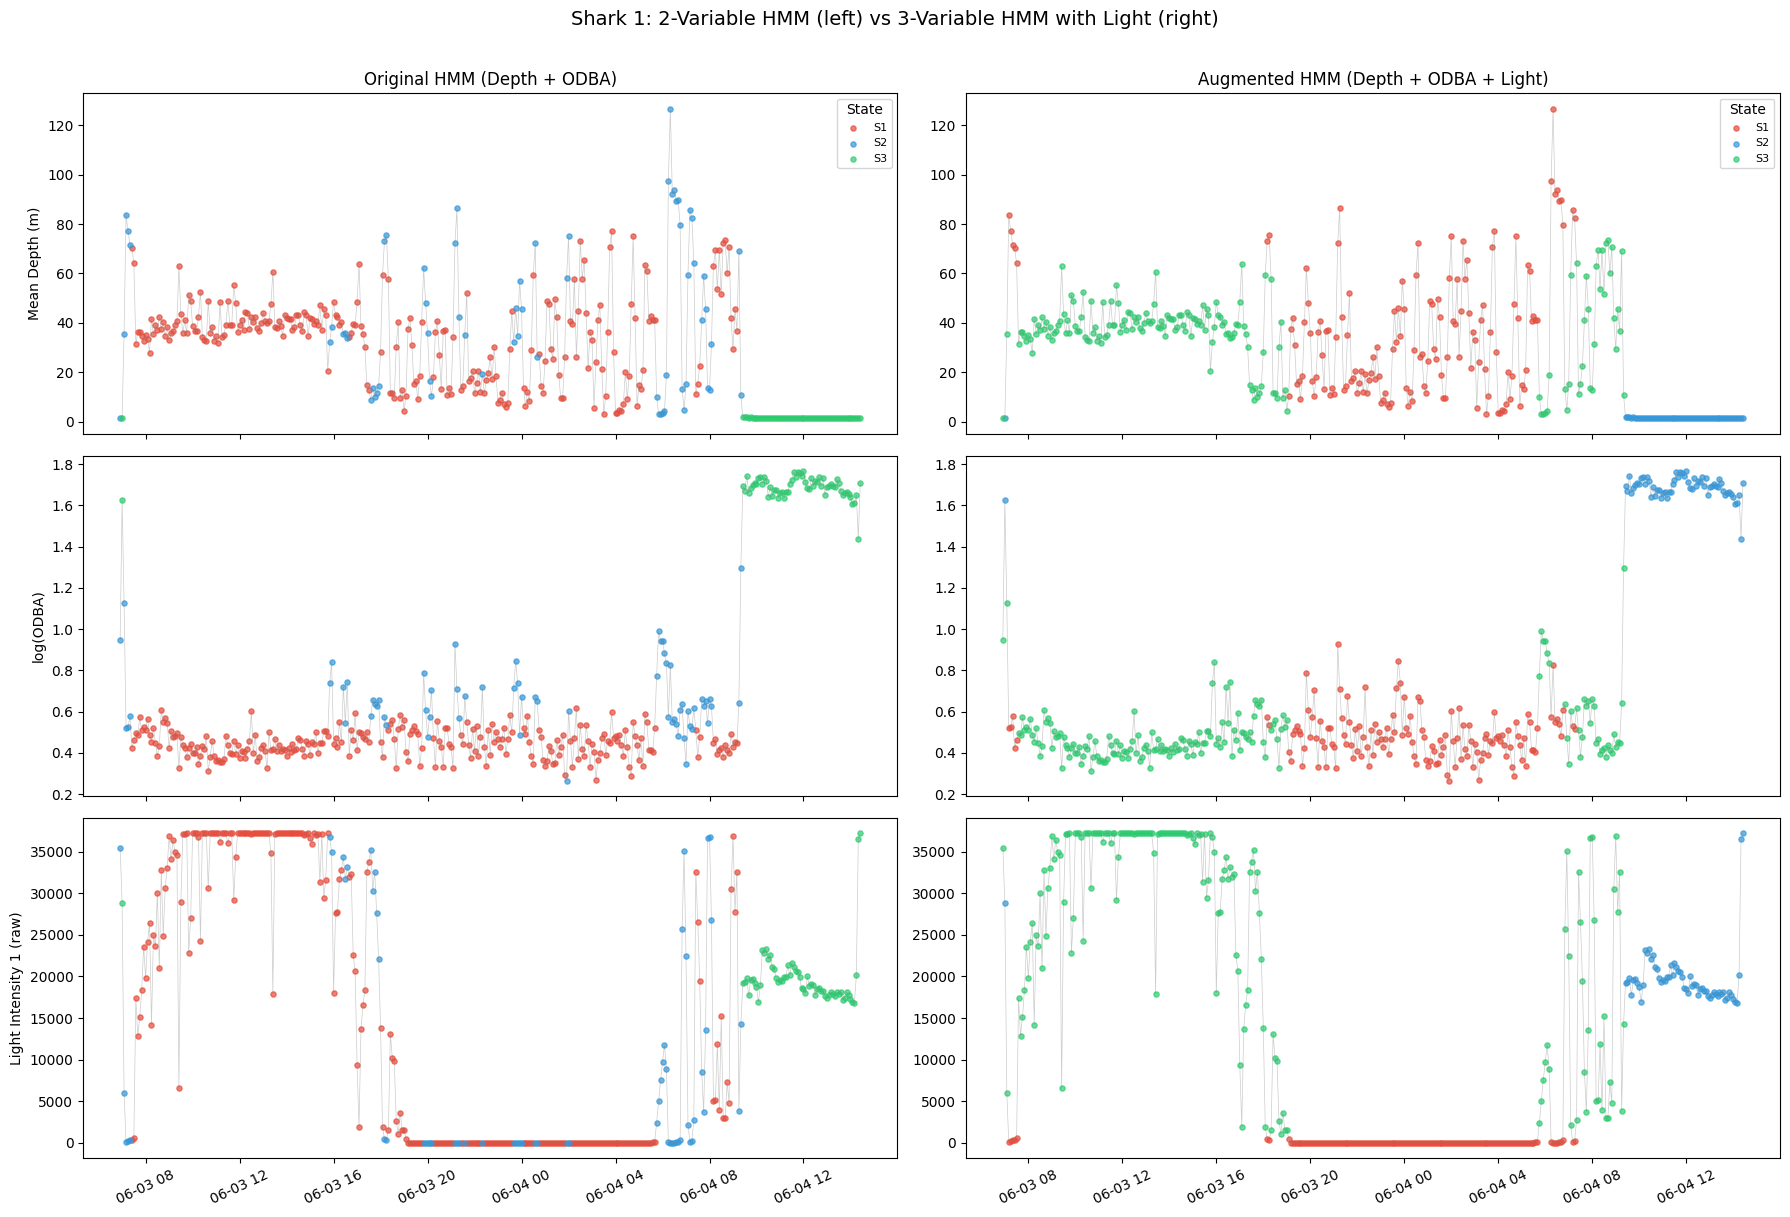

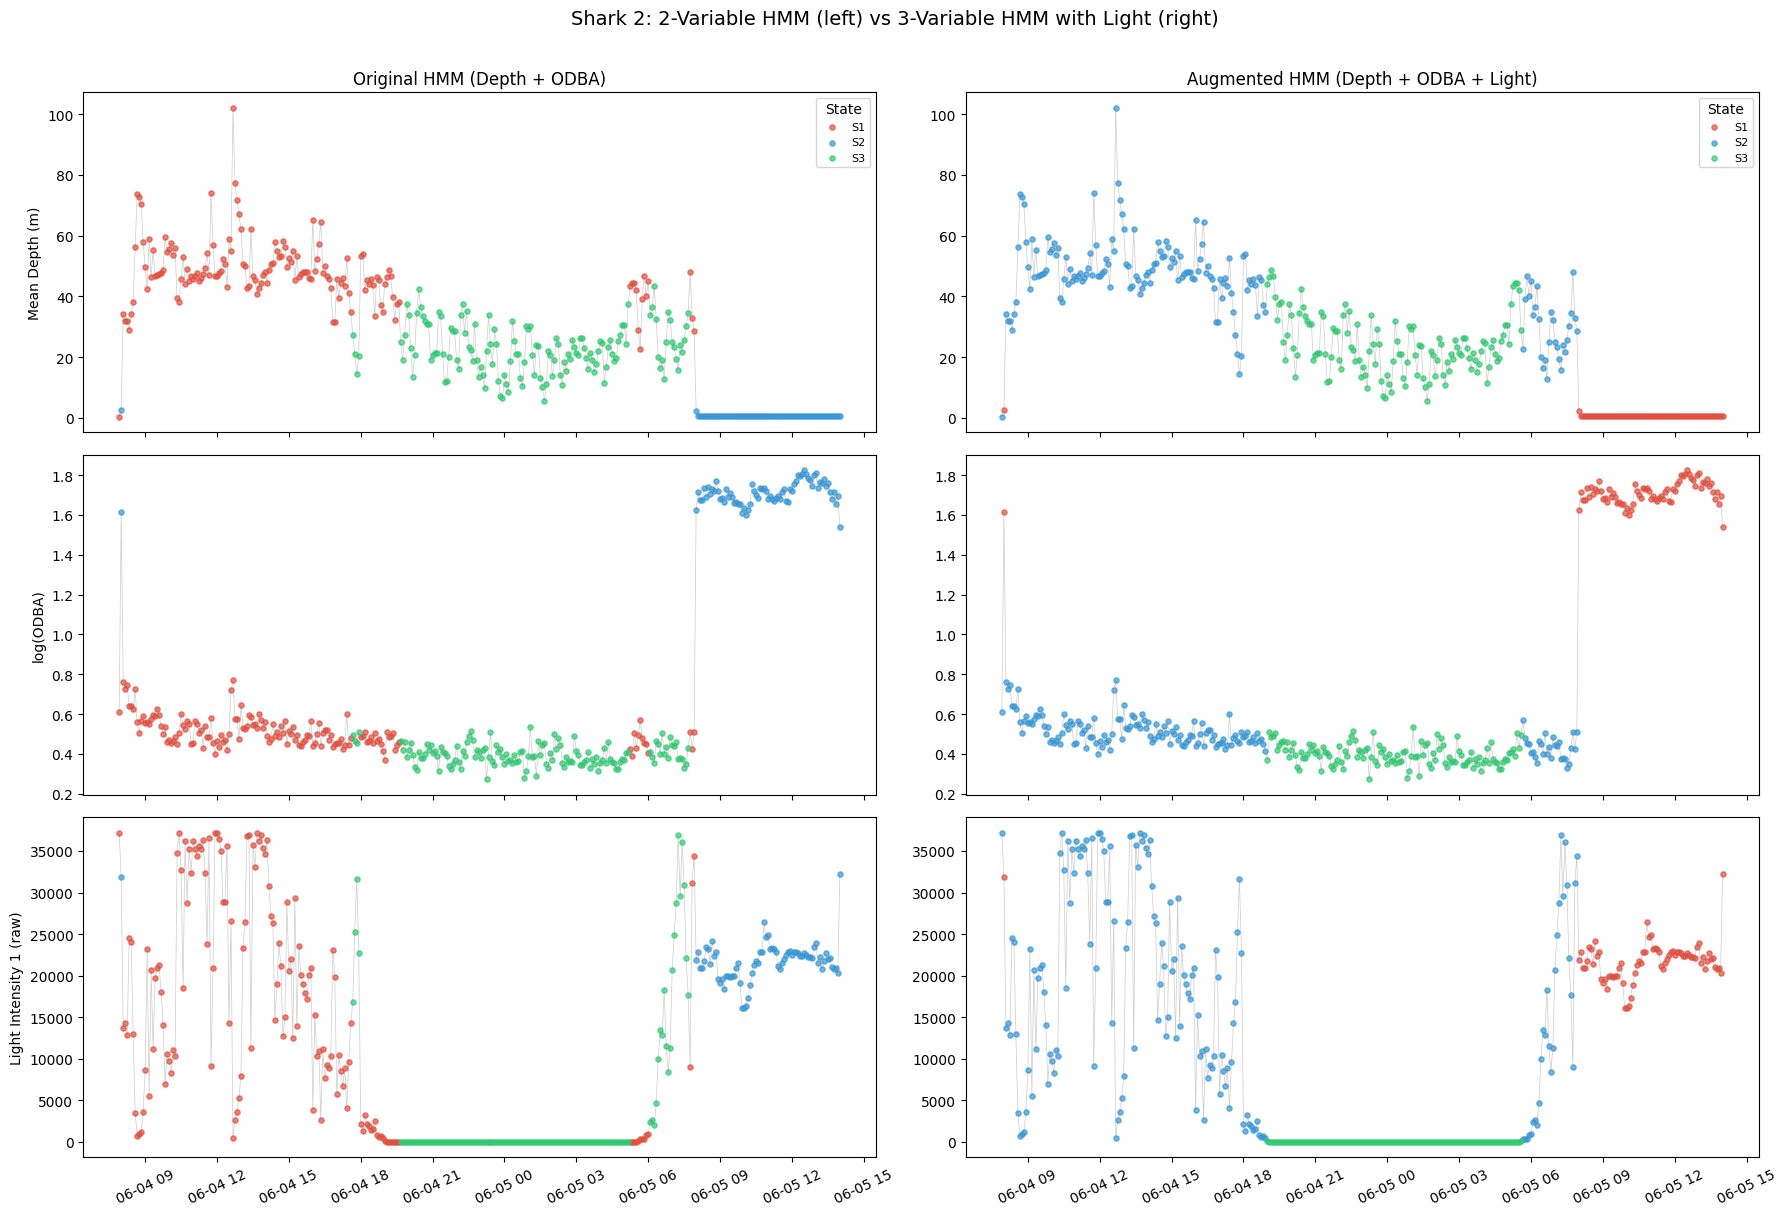

STATE SUMMARY COMPARISON: 2-VARIABLE vs 3-VARIABLE HMM

--- Shark 1 ---

  Original (Depth + ODBA):
    State 1: depth=34.4m, ODBA=0.565, light=15780, prop=66.8%
    State 2: depth=44.5m, ODBA=0.985, light=9997, prop=16.9%
    State 3: depth=1.6m, ODBA=4.410, light=19947, prop=16.4%

  Augmented (Depth + ODBA + Light):
    State 1: depth=36.0m, ODBA=0.632, light=29, prop=38.0%
    State 2: depth=1.6m, ODBA=4.410, light=19947, prop=16.4%
    State 3: depth=36.8m, ODBA=0.664, light=26752, prop=45.6%

--- Shark 2 ---

  Original (Depth + ODBA):
    State 1: depth=47.9m, ODBA=0.674, light=16353, prop=41.2%
    State 2: depth=0.6m, ODBA=4.537, light=21839, prop=20.4%
    State 3: depth=22.7m, ODBA=0.489, light=3176, prop=38.4%

  Augmented (Depth + ODBA + Light):
    State 1: depth=0.6m, ODBA=4.537, light=21839, prop=20.4%
    State 2: depth=45.0m, ODBA=0.661, light=17986, prop=44.2%
    State 3: depth=24.1m, ODBA=0.490, light=3, prop=35.4%


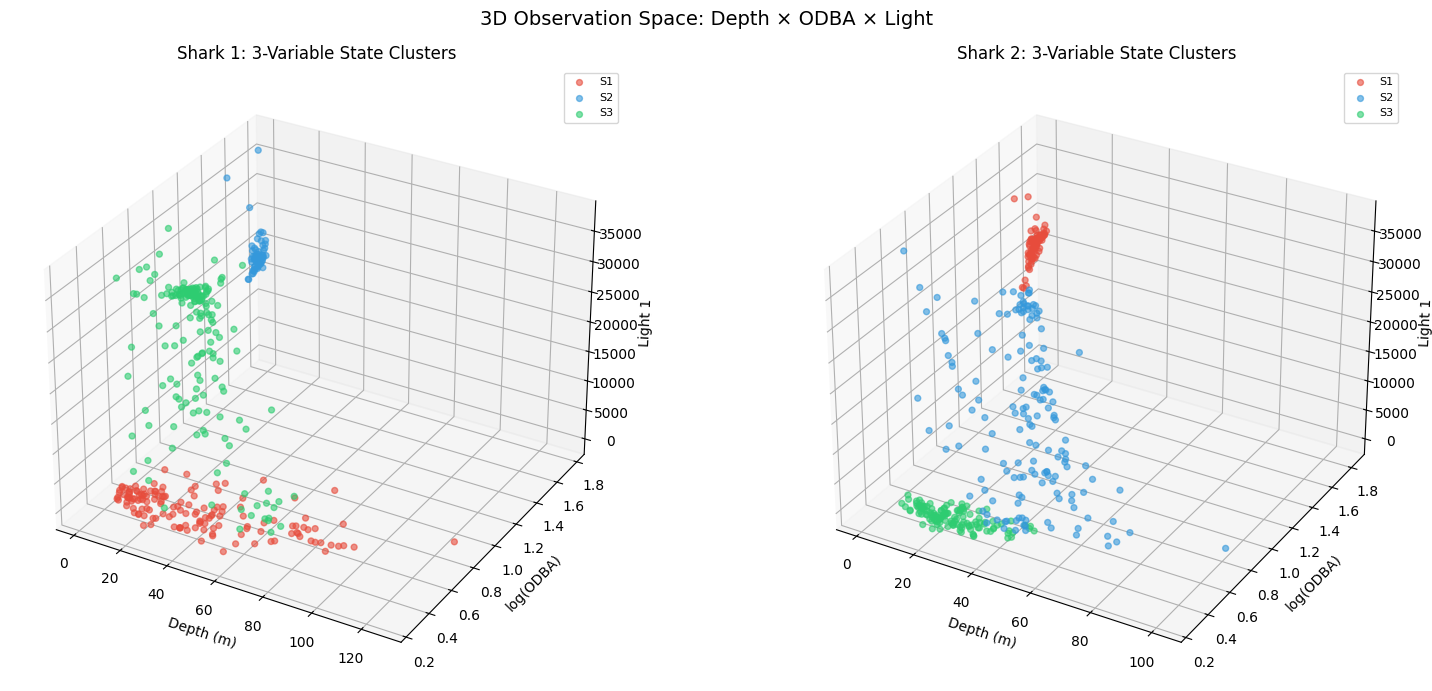

In [37]:
# =============================================================================
# 3-VARIABLE HMM: DECODED STATE SEQUENCE PLOTS
# Compare original (depth+ODBA) vs augmented (depth+ODBA+light) state decoding
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from hmmlearn.hmm import GaussianHMM

colors_map = {1: "#e74c3c", 2: "#3498db", 3: "#2ecc71"}

# ---- Refit 3-variable HMM and store results ----
def fit_best_hmm_multi(X, n_states, seeds=(11, 22, 33, 44, 55, 66, 77, 88, 99, 490)):
    best_model = None
    best_score = -np.inf
    for seed in seeds:
        model = GaussianHMM(n_components=n_states, covariance_type="diag",
                            n_iter=500, random_state=seed)
        model.fit(X)
        score = model.score(X)
        if score > best_score:
            best_score = score
            best_model = model
    return best_model, best_score

shark1_res_3v = shark1_win.copy()
shark2_res_3v = shark2_win.copy()

for win_df, res_df, name in [(shark1_win, shark1_res_3v, "Shark 1"),
                              (shark2_win, shark2_res_3v, "Shark 2")]:
    win = win_df.copy()
    mu = win["mean_light_1"].mean()
    sd = win["mean_light_1"].std(ddof=0)
    win["mean_light_1_z"] = (win["mean_light_1"] - mu) / sd
    rng = np.random.default_rng(490)
    win["mean_light_1_z_jit"] = win["mean_light_1_z"] + rng.normal(0, 1e-6, len(win))

    X_3var = win[["mean_depth_z_jit", "log_odba_z_jit", "mean_light_1_z_jit"]].to_numpy()
    model_3v, _ = fit_best_hmm_multi(X_3var, n_states=3)
    res_df["state_3v"] = model_3v.predict(X_3var) + 1

# ---- Side-by-side comparison plots: 2-var vs 3-var ----
plot_configs = [
    ("mean_depth", "Mean Depth (m)"),
    ("log_odba",   "log(ODBA)"),
    ("mean_light_1", "Light Intensity 1 (raw)"),
]

for df_2v, df_3v, name in [(shark1_res_3, shark1_res_3v, "Shark 1"),
                             (shark2_res_3, shark2_res_3v, "Shark 2")]:

    fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex=True)
    fig.suptitle(f"{name}: 2-Variable HMM (left) vs 3-Variable HMM with Light (right)",
                 fontsize=14, y=1.01)

    for row_idx, (var, ylabel) in enumerate(plot_configs):
        # Left: original 2-variable states
        ax_l = axes[row_idx, 0]
        ax_l.plot(df_2v["time_window"], df_2v[var], color="gray", linewidth=0.5, alpha=0.4)
        for s in sorted(df_2v["state"].unique()):
            mask = df_2v["state"] == s
            ax_l.scatter(df_2v.loc[mask, "time_window"], df_2v.loc[mask, var],
                         s=14, alpha=0.7, color=colors_map[s], label=f"S{s}")
        ax_l.set_ylabel(ylabel)
        if row_idx == 0:
            ax_l.set_title("Original HMM (Depth + ODBA)")
            ax_l.legend(fontsize=8, title="State")
        if row_idx == 2:
            ax_l.tick_params(axis="x", rotation=25)

        # Right: 3-variable states
        ax_r = axes[row_idx, 1]
        ax_r.plot(df_3v["time_window"], df_3v[var], color="gray", linewidth=0.5, alpha=0.4)
        for s in sorted(df_3v["state_3v"].unique()):
            mask = df_3v["state_3v"] == s
            ax_r.scatter(df_3v.loc[mask, "time_window"], df_3v.loc[mask, var],
                         s=14, alpha=0.7, color=colors_map[s], label=f"S{s}")
        if row_idx == 0:
            ax_r.set_title("Augmented HMM (Depth + ODBA + Light)")
            ax_r.legend(fontsize=8, title="State")
        if row_idx == 2:
            ax_r.tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.savefig(f"light_analysis_decoded_{name.replace(' ','')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# ---- State summary comparison table ----
print("=" * 90)
print("STATE SUMMARY COMPARISON: 2-VARIABLE vs 3-VARIABLE HMM")
print("=" * 90)

for df_2v, df_3v, name in [(shark1_res_3, shark1_res_3v, "Shark 1"),
                             (shark2_res_3, shark2_res_3v, "Shark 2")]:
    print(f"\n--- {name} ---")

    print("\n  Original (Depth + ODBA):")
    tab_2v = hmm_summary_table(df_2v)
    for _, r in tab_2v.iterrows():
        print(f"    State {int(r['state'])}: depth={r['mean_depth']:.1f}m, "
              f"ODBA={r['mean_odba']:.3f}, light={r['mean_light_1']:.0f}, "
              f"prop={r['prop']:.1%}")

    print("\n  Augmented (Depth + ODBA + Light):")
    tab_3v = (
        df_3v.groupby("state_3v", as_index=False)
        .agg(mean_depth=("mean_depth", "mean"),
             sd_depth=("mean_depth", "std"),
             mean_odba=("mean_odba", "mean"),
             mean_light_1=("mean_light_1", "mean"),
             mean_light_2=("mean_light_2", "mean"),
             mean_temp=("mean_temp", "mean"),
             n=("state_3v", "size"))
    )
    tab_3v["prop"] = tab_3v["n"] / tab_3v["n"].sum()
    for _, r in tab_3v.iterrows():
        print(f"    State {int(r['state_3v'])}: depth={r['mean_depth']:.1f}m, "
              f"ODBA={r['mean_odba']:.3f}, light={r['mean_light_1']:.0f}, "
              f"prop={r['prop']:.1%}")

# ---- Depth-ODBA-Light 3D scatter colored by state ----
from mpl_toolkits.mplot3d import Axes3D

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          subplot_kw={"projection": "3d"})

for ax, df_3v, name in zip(axes,
    [shark1_res_3v, shark2_res_3v], ["Shark 1", "Shark 2"]):
    for s in sorted(df_3v["state_3v"].unique()):
        mask = df_3v["state_3v"] == s
        ax.scatter(df_3v.loc[mask, "mean_depth"],
                   df_3v.loc[mask, "log_odba"],
                   df_3v.loc[mask, "mean_light_1"],
                   s=18, alpha=0.6, color=colors_map[s], label=f"S{s}")
    ax.set_xlabel("Depth (m)")
    ax.set_ylabel("log(ODBA)")
    ax.set_zlabel("Light 1")
    ax.set_title(f"{name}: 3-Variable State Clusters")
    ax.legend(fontsize=8)

plt.suptitle("3D Observation Space: Depth × ODBA × Light", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig("light_analysis_3d_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

### HMM with light

In [38]:
# =============================================================================
# REFIT HMM WITH LIGHT AS 3rd VARIABLE
# This overwrites shark1_res_3 and shark2_res_3 so all downstream code
# (diel, compare, etc.) automatically uses the 3-variable model
# =============================================================================

import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

# ---- Standardize light and fit 3-variable HMM ----
for win_df, name in [(shark1_win, "Shark1"), (shark2_win, "Shark2")]:
    mu = win_df["mean_light_1"].mean()
    sd = win_df["mean_light_1"].std(ddof=0)
    win_df["mean_light_1_z"] = (win_df["mean_light_1"] - mu) / sd
    rng = np.random.default_rng(490)
    win_df["mean_light_1_z_jit"] = win_df["mean_light_1_z"] + rng.normal(0, 1e-6, len(win_df))

# Fit 3-variable, 3-state HMM
X1_3v = shark1_win[["mean_depth_z_jit", "log_odba_z_jit", "mean_light_1_z_jit"]].to_numpy()
X2_3v = shark2_win[["mean_depth_z_jit", "log_odba_z_jit", "mean_light_1_z_jit"]].to_numpy()

model_sh1_3, ll_sh1_3 = fit_best_hmm(X1_3v, n_states=3)
model_sh2_3, ll_sh2_3 = fit_best_hmm(X2_3v, n_states=3)

# Overwrite the result dataframes
shark1_res_3 = shark1_win.copy()
shark1_res_3["state"] = model_sh1_3.predict(X1_3v) + 1

shark2_res_3 = shark2_win.copy()
shark2_res_3["state"] = model_sh2_3.predict(X2_3v) + 1

# Recompute AIC/BIC for 3-variable model
n_features_3v = 3
aic_sh1_3, bic_sh1_3 = hmm_aic_bic(ll_sh1_3, n_states=3, n_features=n_features_3v, n_obs=len(X1_3v))
aic_sh2_3, bic_sh2_3 = hmm_aic_bic(ll_sh2_3, n_states=3, n_features=n_features_3v, n_obs=len(X2_3v))

# ---- Print new state summaries ----
def hmm_summary_table(df_results):
    tab = (
        df_results.groupby("state", as_index=False)
        .agg(
            mean_depth=("mean_depth", "mean"),
            sd_depth=("mean_depth", "std"),
            mean_odba=("mean_odba", "mean"),
            sd_odba=("mean_odba", "std"),
            mean_temp=("mean_temp", "mean"),
            mean_light_1=("mean_light_1", "mean"),
            mean_light_2=("mean_light_2", "mean"),
            n=("state", "size")
        )
    )
    tab["prop"] = tab["n"] / tab["n"].sum()
    return tab

print("=" * 80)
print("3-VARIABLE HMM (Depth + ODBA + Light) — NEW STATE SUMMARIES")
print("=" * 80)

for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    print(f"\n--- {name} ---")
    tab = hmm_summary_table(df)
    print(tab[["state", "mean_depth", "sd_depth", "mean_odba", "sd_odba",
               "mean_light_1", "n", "prop"]].to_string(index=False))

print(f"\nShark 1 AIC: {aic_sh1_3:.1f}, BIC: {bic_sh1_3:.1f}")
print(f"Shark 2 AIC: {aic_sh2_3:.1f}, BIC: {bic_sh2_3:.1f}")

# ---- Assign biological labels ----
# IMPORTANT: state numbers may differ from 2-var model!
# Check the summary above and adjust if needed.
# Auto-labeling based on depth + ODBA:
def assign_bio_label(row):
    if row["mean_depth"] < 5 and row["mean_odba"] > 2:
        return "Surface Active"
    elif row["mean_depth"] > 40:
        return "Deep Diving / Foraging"
    else:
        return "Cruising / Routine Swimming"

summary_sh1 = hmm_summary_table(shark1_res_3).copy()
summary_sh1["shark"] = "Shark 1"
summary_sh2 = hmm_summary_table(shark2_res_3).copy()
summary_sh2["shark"] = "Shark 2"
summary_3s = pd.concat([summary_sh1, summary_sh2], ignore_index=True)
summary_3s["bio_label"] = summary_3s.apply(assign_bio_label, axis=1)

# Print the mapping
print("\n" + "=" * 80)
print("STATE → BEHAVIOR MAPPING (3-variable HMM)")
print("=" * 80)
for shark_name in ["Shark 1", "Shark 2"]:
    sub = summary_3s[summary_3s["shark"] == shark_name]
    print(f"\n  {shark_name}:")
    for _, r in sub.iterrows():
        print(f"    State {int(r['state'])} → {r['bio_label']} "
              f"(depth={r['mean_depth']:.1f}m, ODBA={r['mean_odba']:.3f}, "
              f"light={r['mean_light_1']:.0f})")

print("\n✓ shark1_res_3 and shark2_res_3 now use 3-variable HMM states")
print("✓ Re-run diel and compare chunks below with these updated states")

3-VARIABLE HMM (Depth + ODBA + Light) — NEW STATE SUMMARIES

--- Shark 1 ---
 state  mean_depth  sd_depth  mean_odba  sd_odba  mean_light_1   n     prop
     1   36.037569 25.827480   0.632128 0.199751     28.536625 144 0.379947
     2    1.619283  0.064564   4.410421 0.260601  19947.397468  62 0.163588
     3   36.824731 14.865989   0.663997 0.296427  26751.841341 173 0.456464

--- Shark 2 ---
 state  mean_depth  sd_depth  mean_odba  sd_odba  mean_light_1   n     prop
     1    0.631766  0.294202   4.536598 0.303833  21839.091713  74 0.204420
     2   45.035169 13.578192   0.660580 0.134519  17985.880283 160 0.441989
     3   24.092272  9.539209   0.490336 0.080938      3.019349 128 0.353591

Shark 1 AIC: -32.4, BIC: 70.0
Shark 2 AIC: -821.5, BIC: -720.4

STATE → BEHAVIOR MAPPING (3-variable HMM)

  Shark 1:
    State 1 → Cruising / Routine Swimming (depth=36.0m, ODBA=0.632, light=29)
    State 2 → Surface Active (depth=1.6m, ODBA=4.410, light=19947)
    State 3 → Cruising / Routine S

## 6. Biological Interpretation of 3-State Models

3-STATE HMM: BIOLOGICAL INTERPRETATION

--- Shark 1 ---
  State 1: Cruising / Routine Swimming
    Mean depth = 36.0 m (SD = 25.8)
    Mean ODBA  = 0.632 (SD = 0.200)
    Mean temp  = 22.7 °C
    Mean light = 29 (raw)
    Proportion = 38.0%
  State 2: Surface Active
    Mean depth = 1.6 m (SD = 0.1)
    Mean ODBA  = 4.410 (SD = 0.261)
    Mean temp  = 24.7 °C
    Mean light = 19947 (raw)
    Proportion = 16.4%
  State 3: Cruising / Routine Swimming
    Mean depth = 36.8 m (SD = 14.9)
    Mean ODBA  = 0.664 (SD = 0.296)
    Mean temp  = 23.4 °C
    Mean light = 26752 (raw)
    Proportion = 45.6%

--- Shark 2 ---
  State 1: Surface Active
    Mean depth = 0.6 m (SD = 0.3)
    Mean ODBA  = 4.537 (SD = 0.304)
    Mean temp  = 25.0 °C
    Mean light = 21839 (raw)
    Proportion = 20.4%
  State 2: Deep Diving / Foraging
    Mean depth = 45.0 m (SD = 13.6)
    Mean ODBA  = 0.661 (SD = 0.135)
    Mean temp  = 23.1 °C
    Mean light = 17986 (raw)
    Proportion = 44.2%
  State 3: Cruising / Rou

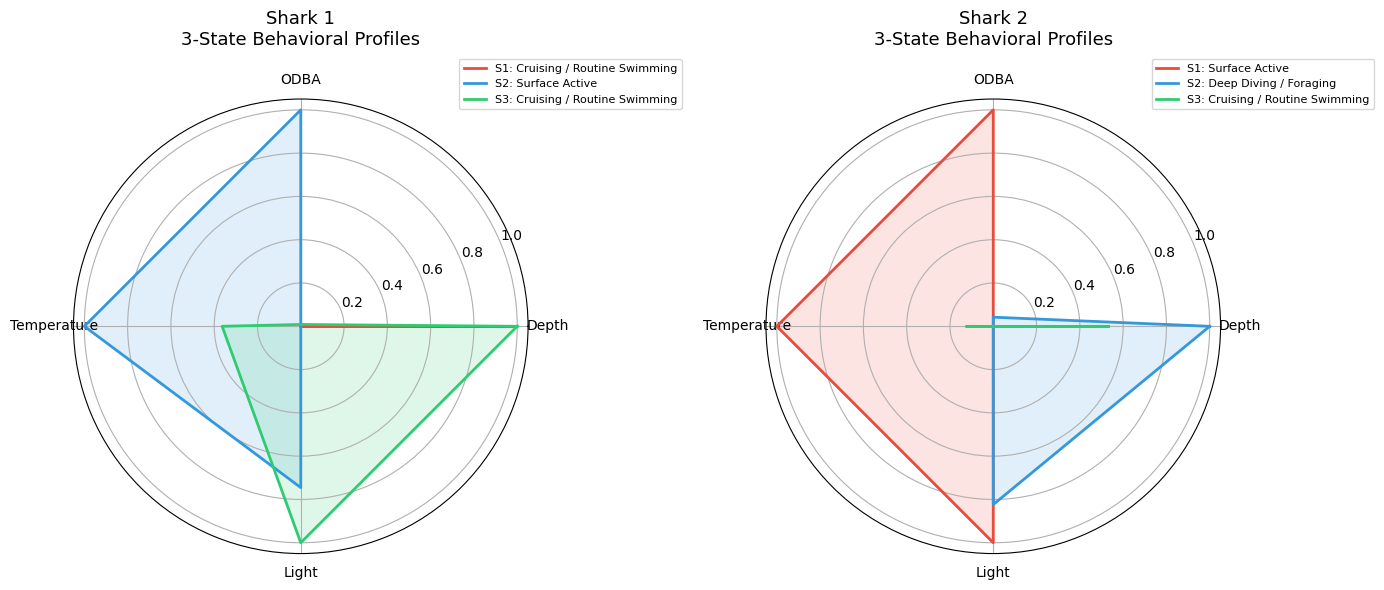


Saved: next_step1_bio_interpretation.png


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ---- 1a. Build a combined state-summary table (3-state only) ----
summary_sh1 = hmm_summary_table(shark1_res_3).copy()
summary_sh1["shark"] = "Shark 1"
summary_sh2 = hmm_summary_table(shark2_res_3).copy()
summary_sh2["shark"] = "Shark 2"
summary_3s = pd.concat([summary_sh1, summary_sh2], ignore_index=True)

# ---- 1b. Assign biological labels ----
# Heuristic: shallow + high ODBA → "Surface Active"
#            moderate depth + low ODBA → "Cruising / Routine Swimming"
#            deep + variable depth + moderate ODBA → "Deep Diving / Foraging"

def assign_bio_label(row):
    if row["mean_depth"] < 5 and row["mean_odba"] > 2:
        return "Surface Active"
    elif row["mean_depth"] > 40:
        return "Deep Diving / Foraging"
    else:
        return "Cruising / Routine Swimming"

summary_3s["bio_label"] = summary_3s.apply(assign_bio_label, axis=1)

print("=" * 80)
print("3-STATE HMM: BIOLOGICAL INTERPRETATION")
print("=" * 80)
for shark_name in ["Shark 1", "Shark 2"]:
    sub = summary_3s[summary_3s["shark"] == shark_name]
    print(f"\n--- {shark_name} ---")
    for _, r in sub.iterrows():
        print(f"  State {int(r['state'])}: {r['bio_label']}")
        print(f"    Mean depth = {r['mean_depth']:.1f} m (SD = {r['sd_depth']:.1f})")
        print(f"    Mean ODBA  = {r['mean_odba']:.3f} (SD = {r['sd_odba']:.3f})")
        print(f"    Mean temp  = {r['mean_temp']:.1f} °C")
        print(f"    Mean light = {r['mean_light_1']:.0f} (raw)")
        print(f"    Proportion = {r['prop']:.1%}")

# ---- 1c. Radar / polar chart comparing state profiles ----
def normalize_col(s):
    rng = s.max() - s.min()
    if rng == 0:
        return s * 0
    return (s - s.min()) / rng

radar_vars = ["mean_depth", "mean_odba", "mean_temp", "mean_light_1"]
radar_labels = ["Depth", "ODBA", "Temperature", "Light"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"polar": True})

for ax, shark_name in zip(axes, ["Shark 1", "Shark 2"]):
    sub = summary_3s[summary_3s["shark"] == shark_name].copy()
    for col in radar_vars:
        sub[col + "_n"] = normalize_col(sub[col].values)

    angles = np.linspace(0, 2 * np.pi, len(radar_vars), endpoint=False).tolist()
    angles += angles[:1]

    colors = ["#e74c3c", "#3498db", "#2ecc71"]
    for idx, (_, r) in enumerate(sub.iterrows()):
        vals = [r[v + "_n"] for v in radar_vars] + [r[radar_vars[0] + "_n"]]
        ax.plot(angles, vals, color=colors[idx], linewidth=2,
                label=f"S{int(r['state'])}: {r['bio_label']}")
        ax.fill(angles, vals, color=colors[idx], alpha=0.15)

    ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels)
    ax.set_title(f"{shark_name}\n3-State Behavioral Profiles", pad=20, fontsize=13)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)

plt.tight_layout()
plt.savefig("next_step1_bio_interpretation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: next_step1_bio_interpretation.png")


## 7. Diel / Time-of-Day Behavioral Patterns

### Chunk 1: State proportions by hour + day vs night comparison

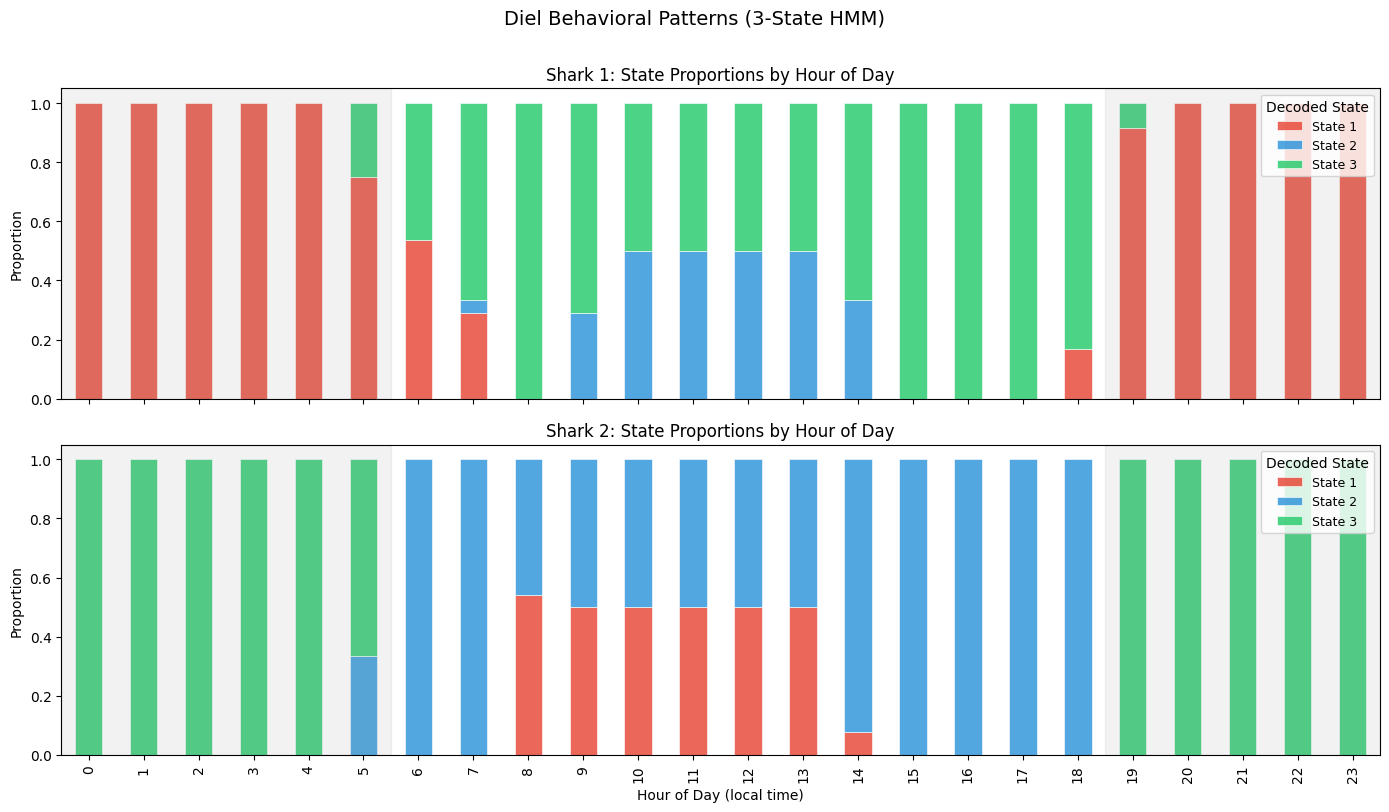

DAY vs NIGHT: STATE PROPORTIONS

--- Shark 1 ---
  Day (06–18) (n=247):
    State 1: 6.5%
    State 2: 25.1%
    State 3: 68.4%
  Night (18–06) (n=132):
    State 1: 97.0%
    State 2: 0.0%
    State 3: 3.0%

--- Shark 2 ---
  Day (06–18) (n=230):
    State 1: 32.2%
    State 2: 67.8%
    State 3: 0.0%
  Night (18–06) (n=132):
    State 1: 0.0%
    State 2: 3.0%
    State 3: 97.0%


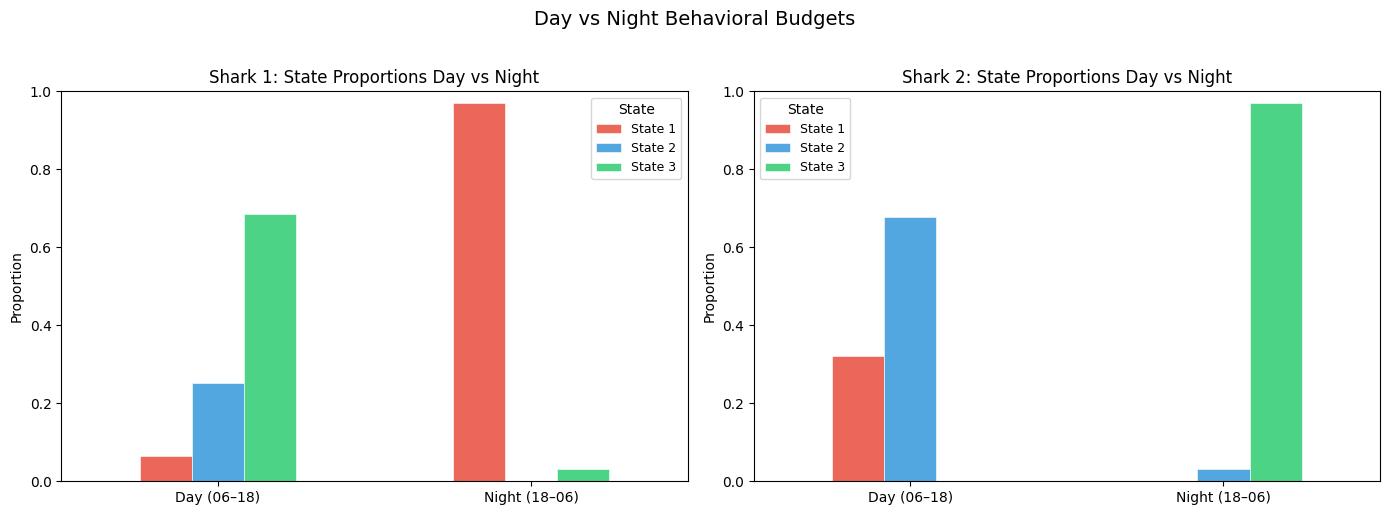


CHI-SQUARED TEST: State × Day/Night independence

  Shark 1:
    χ² = 299.13, df = 2, p = 1.11e-65
    Cramér's V = 0.888
    → State distribution SIGNIFICANTLY differs between day and night

    Observed counts:
    state            1   2    3
period                     
Day (06–18)     16  62  169
Night (18–06)  128   0    4

    Expected counts (under independence):
    state             1     2      3
period                          
Day (06–18)    93.8  40.4  112.7
Night (18–06)  50.2  21.6   60.3

  Shark 2:
    χ² = 345.17, df = 2, p = 1.12e-75
    Cramér's V = 0.976
    → State distribution SIGNIFICANTLY differs between day and night

    Observed counts:
    state           1    2    3
period                     
Day (06–18)    74  156    0
Night (18–06)   0    4  128

    Expected counts (under independence):
    state             1      2     3
period                          
Day (06–18)    47.0  101.7  81.3
Night (18–06)  27.0   58.3  46.7


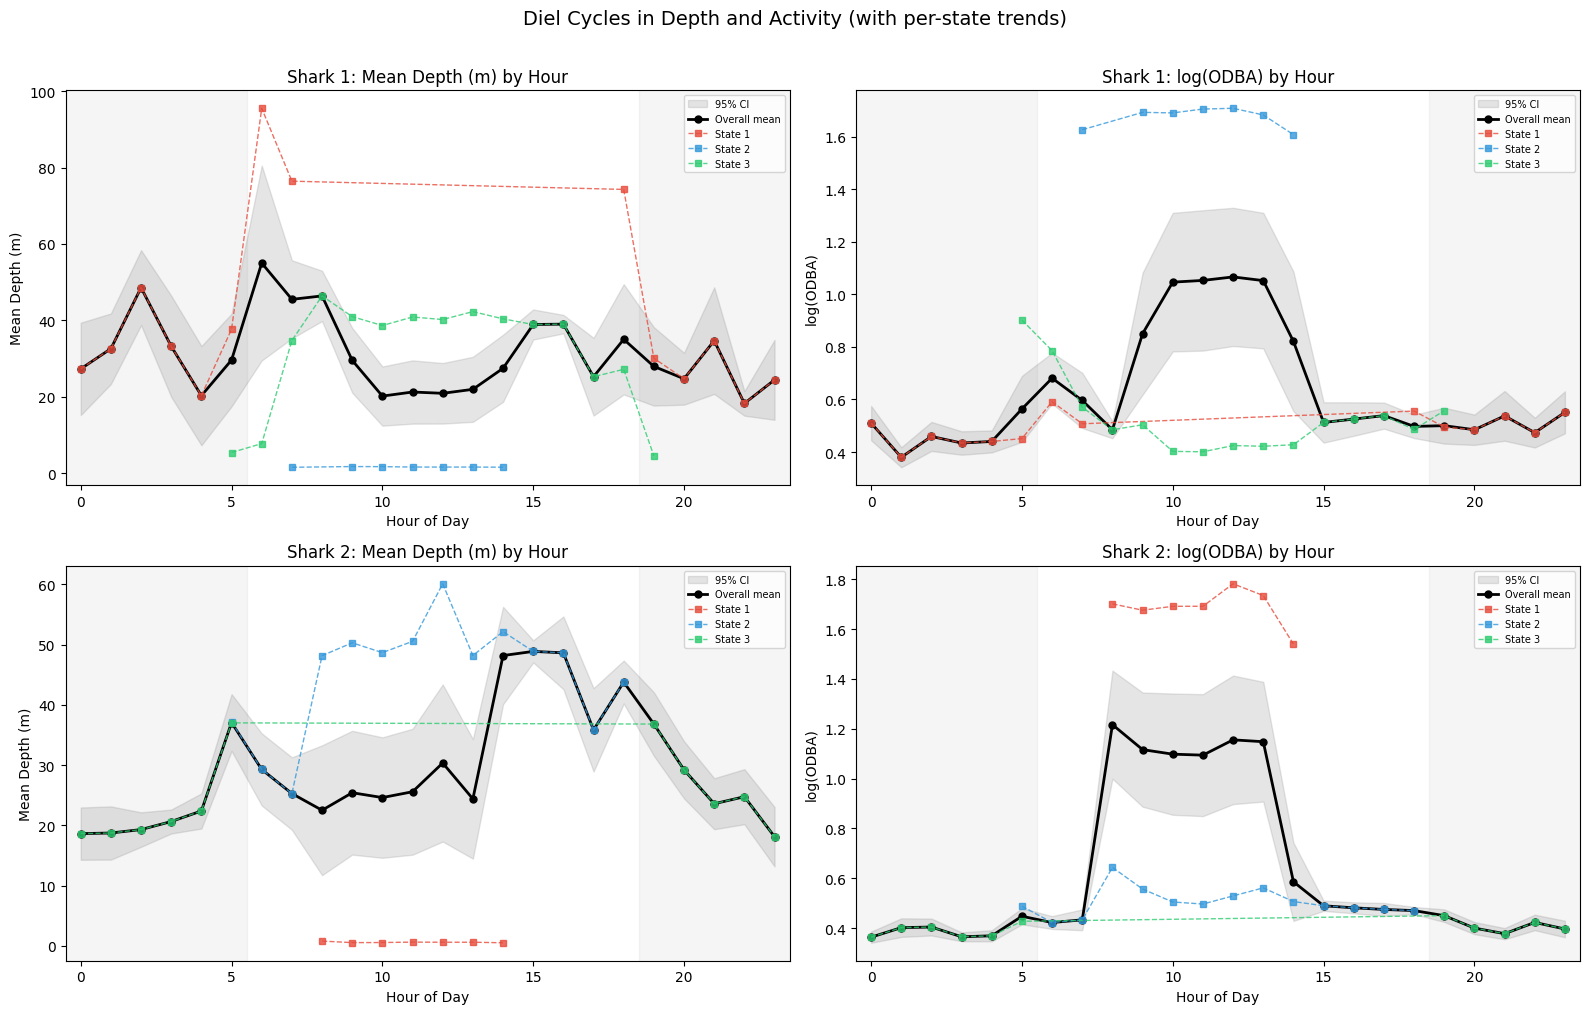


DAY vs NIGHT: VARIABLE MEANS + WILCOXON RANK-SUM TESTS

--- Shark 1 ---
  Variable         Day mean   Night mean     U-stat    p-value   Sig
  Depth (m)           31.59        29.23      16538     0.8167    ns
  ODBA                 1.60         0.64      20804     0.0000   ***
  Temp (°C)           23.47        23.09      20069     0.0002   ***
  Light 1          23690.80       130.98      32462     0.0000   ***
  Light 2           7691.10        11.58      32402     0.0000   ***

--- Shark 2 ---
  Variable         Day mean   Night mean     U-stat    p-value   Sig
  Depth (m)           30.89        24.49      18371     0.0009   ***
  ODBA                 1.91         0.49      27728     0.0000   ***
  Temp (°C)           23.74        23.36      19903     0.0000   ***
  Light 1          19530.00        17.58      30354     0.0000   ***
  Light 2           3187.56         0.52      30353     0.0000   ***


In [40]:
# =============================================================================
# DIEL PATTERNS — CHUNK 1/2
# State proportions by hour, day vs night comparison, depth & ODBA diel cycles
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

colors_map = {1: "#e74c3c", 2: "#3498db", 3: "#2ecc71"}

# ---- Extract time features ----
for df in [shark1_res_3, shark2_res_3]:
    df["hour"] = df["time_window"].dt.hour
    df["is_day"] = df["hour"].between(6, 18)
    df["period"] = df["is_day"].map({True: "Day (06–18)", False: "Night (18–06)"})

# ---- 1a. State frequency by hour (stacked bar) ----
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, df, name in zip(axes, [shark1_res_3, shark2_res_3], ["Shark 1", "Shark 2"]):
    ct = pd.crosstab(df["hour"], df["state"], normalize="index")
    ct.columns = [f"State {int(c)}" for c in ct.columns]
    ct.plot.bar(stacked=True, ax=ax,
                color=["#e74c3c", "#3498db", "#2ecc71"][:len(ct.columns)],
                alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_ylabel("Proportion")
    ax.set_title(f"{name}: State Proportions by Hour of Day")
    ax.legend(title="Decoded State", fontsize=9)
    ax.axvspan(-0.5, 5.5, color="gray", alpha=0.1)
    ax.axvspan(18.5, 23.5, color="gray", alpha=0.1)

axes[-1].set_xlabel("Hour of Day (local time)")
plt.suptitle("Diel Behavioral Patterns (3-State HMM)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("diel_state_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 1b. Day vs Night: state proportion comparison ----
print("=" * 90)
print("DAY vs NIGHT: STATE PROPORTIONS")
print("=" * 90)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in zip(axes, [shark1_res_3, shark2_res_3], ["Shark 1", "Shark 2"]):
    ct = pd.crosstab(df["period"], df["state"], normalize="index")
    state_ids = sorted(df["state"].unique())
    ct.columns = [f"State {int(c)}" for c in ct.columns]

    ct.plot.bar(ax=ax, color=["#e74c3c", "#3498db", "#2ecc71"][:len(ct.columns)],
                alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{name}: State Proportions Day vs Night")
    ax.set_ylabel("Proportion")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="State", fontsize=9)
    ax.set_ylim(0, 1)

    # Print stats
    print(f"\n--- {name} ---")
    for period in ["Day (06–18)", "Night (18–06)"]:
        sub = df[df["period"] == period]
        props = sub["state"].value_counts(normalize=True).sort_index()
        print(f"  {period} (n={len(sub)}):")
        for s in state_ids:
            print(f"    State {s}: {props.get(s, 0):.1%}")

plt.suptitle("Day vs Night Behavioral Budgets", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("diel_day_vs_night_props.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 1c. Chi-squared test: is state distribution independent of day/night? ----
print(f"\n{'='*90}")
print("CHI-SQUARED TEST: State × Day/Night independence")
print(f"{'='*90}")

for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    ct = pd.crosstab(df["period"], df["state"])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    print(f"\n  {name}:")
    print(f"    χ² = {chi2:.2f}, df = {dof}, p = {p:.2e}")
    print(f"    Cramér's V = {cramers_v:.3f}")
    if p < 0.001:
        print(f"    → State distribution SIGNIFICANTLY differs between day and night")
    elif p < 0.05:
        print(f"    → Moderate evidence of day/night difference")
    else:
        print(f"    → No significant day/night difference detected")

    # Observed vs expected table
    print(f"\n    Observed counts:")
    print(f"    {ct.to_string()}")
    print(f"\n    Expected counts (under independence):")
    exp_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1)
    print(f"    {exp_df.to_string()}")

# ---- 1d. Depth and ODBA diel profiles with CI ----
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, (var, ylabel) in enumerate([("mean_depth", "Mean Depth (m)"),
                                          ("log_odba", "log(ODBA)")]):
    for row_idx, (df, name) in enumerate([(shark1_res_3, "Shark 1"),
                                           (shark2_res_3, "Shark 2")]):
        ax = axes[row_idx, col_idx]

        # Overall hourly mean ± SE
        hourly = df.groupby("hour")[var].agg(["mean", "std", "count"]).reset_index()
        hourly["se"] = hourly["std"] / np.sqrt(hourly["count"])

        ax.fill_between(hourly["hour"],
                         hourly["mean"] - 1.96 * hourly["se"],
                         hourly["mean"] + 1.96 * hourly["se"],
                         color="gray", alpha=0.2, label="95% CI")
        ax.plot(hourly["hour"], hourly["mean"], "o-", color="black",
                markersize=5, linewidth=2, label="Overall mean")

        # Per-state hourly means
        for s in sorted(df["state"].unique()):
            sub = df[df["state"] == s]
            h = sub.groupby("hour")[var].mean().reset_index()
            ax.plot(h["hour"], h[var], "s--", color=colors_map[s],
                    markersize=4, linewidth=1, alpha=0.8, label=f"State {s}")

        ax.axvspan(-0.5, 5.5, color="gray", alpha=0.08)
        ax.axvspan(18.5, 23.5, color="gray", alpha=0.08)
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name}: {ylabel} by Hour")
        ax.set_xlim(-0.5, 23.5)
        ax.legend(fontsize=7)

plt.suptitle("Diel Cycles in Depth and Activity (with per-state trends)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("diel_depth_odba_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 1e. Day vs night: depth/ODBA/temp/light means with Wilcoxon tests ----
print(f"\n{'='*90}")
print("DAY vs NIGHT: VARIABLE MEANS + WILCOXON RANK-SUM TESTS")
print(f"{'='*90}")

test_vars = [("mean_depth", "Depth (m)"), ("mean_odba", "ODBA"),
             ("mean_temp", "Temp (°C)"), ("mean_light_1", "Light 1"),
             ("mean_light_2", "Light 2")]

for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    print(f"\n--- {name} ---")
    print(f"  {'Variable':<14} {'Day mean':>10} {'Night mean':>12} "
          f"{'U-stat':>10} {'p-value':>10} {'Sig':>5}")
    for var, label in test_vars:
        day_vals = df.loc[df["is_day"], var].dropna()
        night_vals = df.loc[~df["is_day"], var].dropna()
        if len(day_vals) > 0 and len(night_vals) > 0:
            u, p = stats.mannwhitneyu(day_vals, night_vals, alternative="two-sided")
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"  {label:<14} {day_vals.mean():>10.2f} {night_vals.mean():>12.2f} "
                  f"{u:>10.0f} {p:>10.4f} {sig:>5}")

### chunk 2: Temporal heatmaps, state bout analysis, and transition dynamics

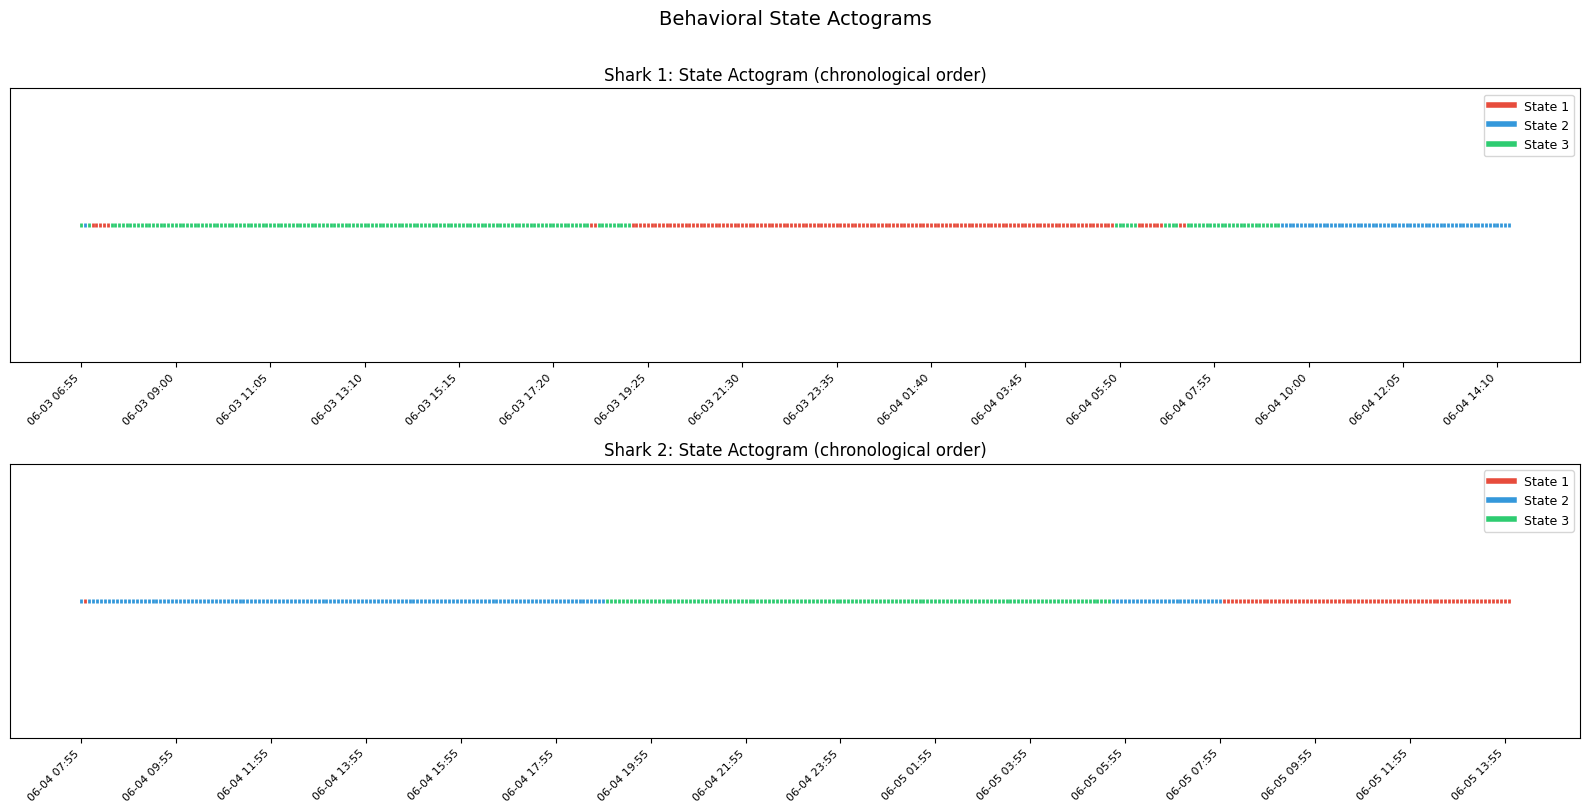

BOUT DURATION ANALYSIS (each window = 5 min)

--- Shark 1 ---
  State     n_bouts   Mean (min)   Median (min)  Max (min)  Total (min)
  S1              5        144.0           25.0        640          720
  S2              2        155.0          155.0        305          310
  S3              7        123.6           30.0        635          865

--- Shark 2 ---
  State     n_bouts   Mean (min)   Median (min)  Max (min)  Total (min)
  S1              2        185.0          185.0        365          370
  S2              3        266.7          140.0        655          800
  S3              1        640.0          640.0        640          640


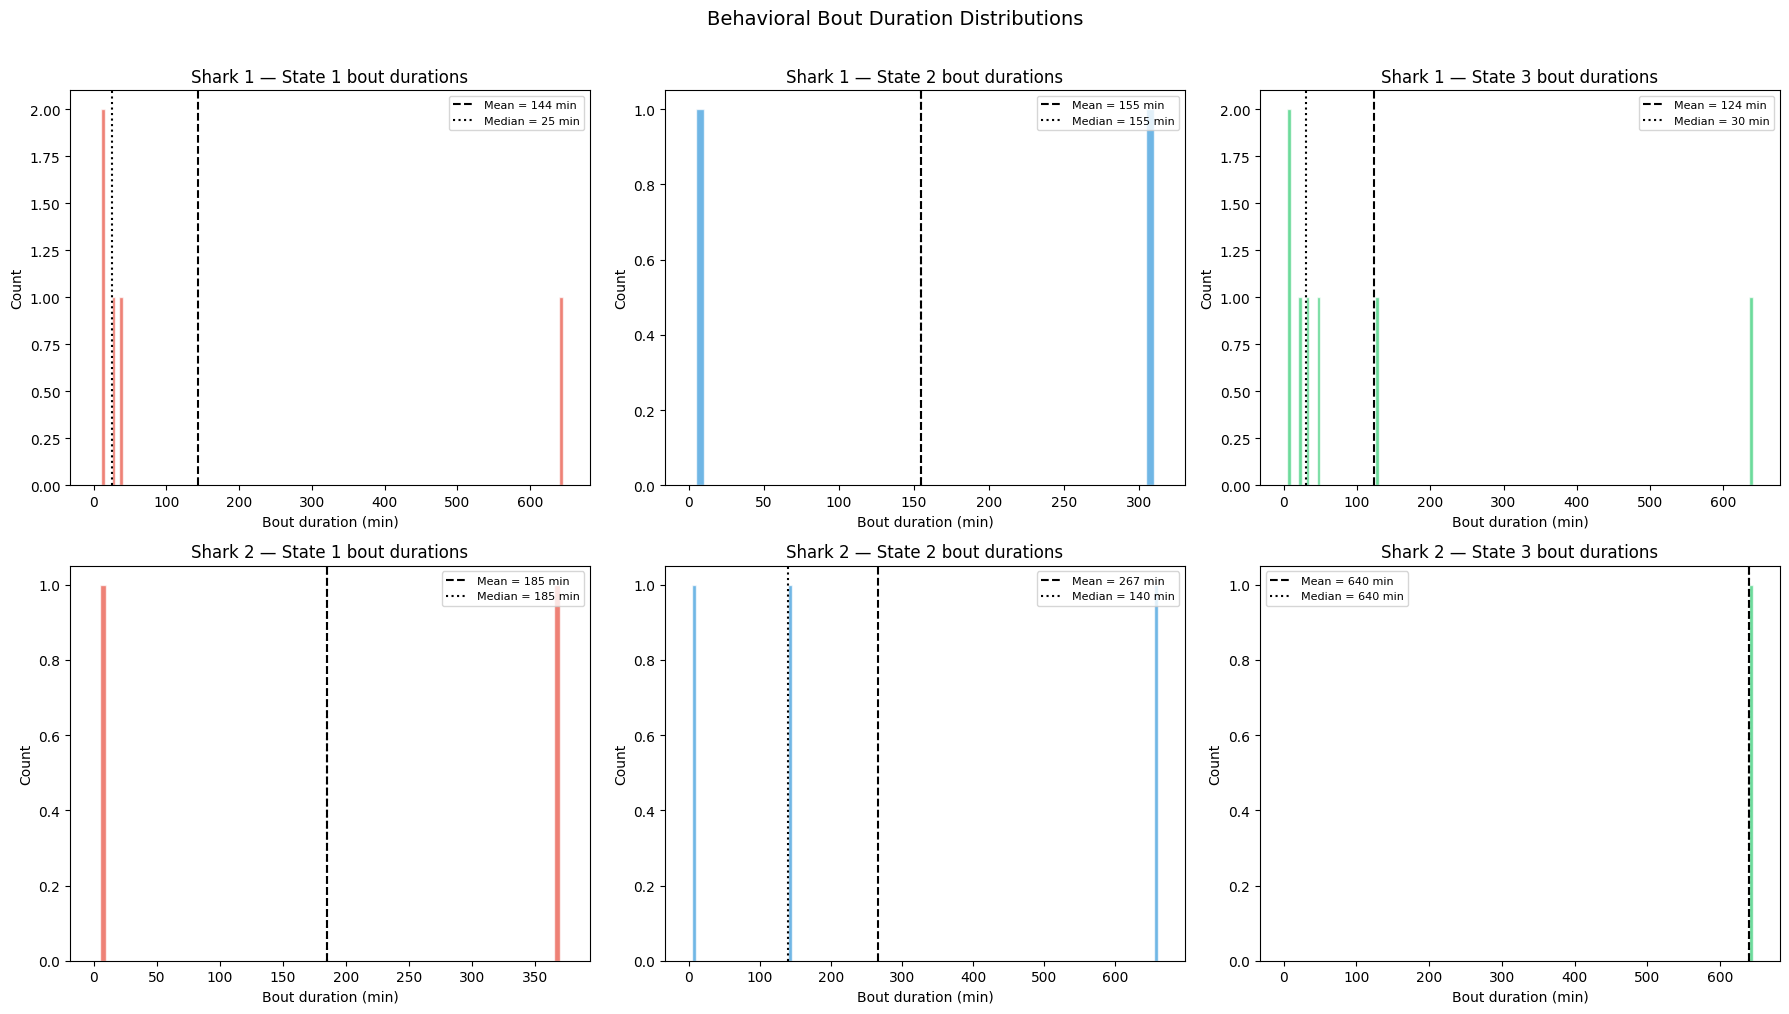


BOUT DURATION: DAY vs NIGHT

--- Shark 1 ---
  State 1:
    Day:   n=  4, mean=  20.0 min, median=  17.5 min
    Night: n=  1, mean= 640.0 min, median= 640.0 min
  State 2:
    Day:   n=  2, mean= 155.0 min, median= 155.0 min
    Night: n=  0, mean=   nan min, median=   nan min
  State 3:
    Day:   n=  6, mean= 139.2 min, median=  32.5 min
    Night: n=  1, mean=  30.0 min, median=  30.0 min

--- Shark 2 ---
  State 1:
    Day:   n=  2, mean= 185.0 min, median= 185.0 min
    Night: n=  0, mean=   nan min, median=   nan min
  State 2:
    Day:   n=  2, mean= 330.0 min, median= 330.0 min
    Night: n=  1, mean= 140.0 min, median= 140.0 min
  State 3:
    Day:   n=  0, mean=   nan min, median=   nan min
    Night: n=  1, mean= 640.0 min, median= 640.0 min


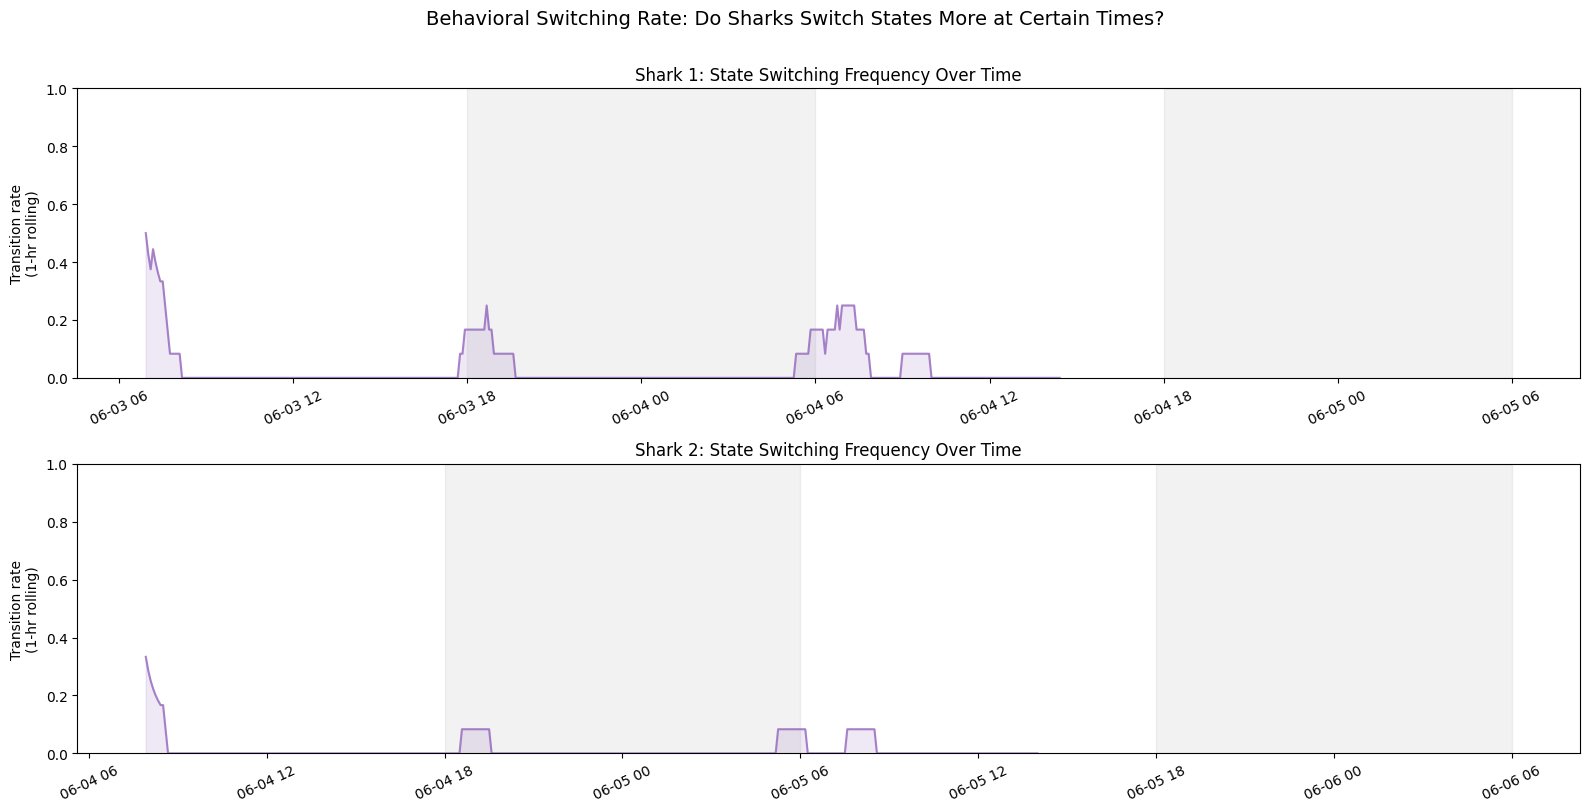

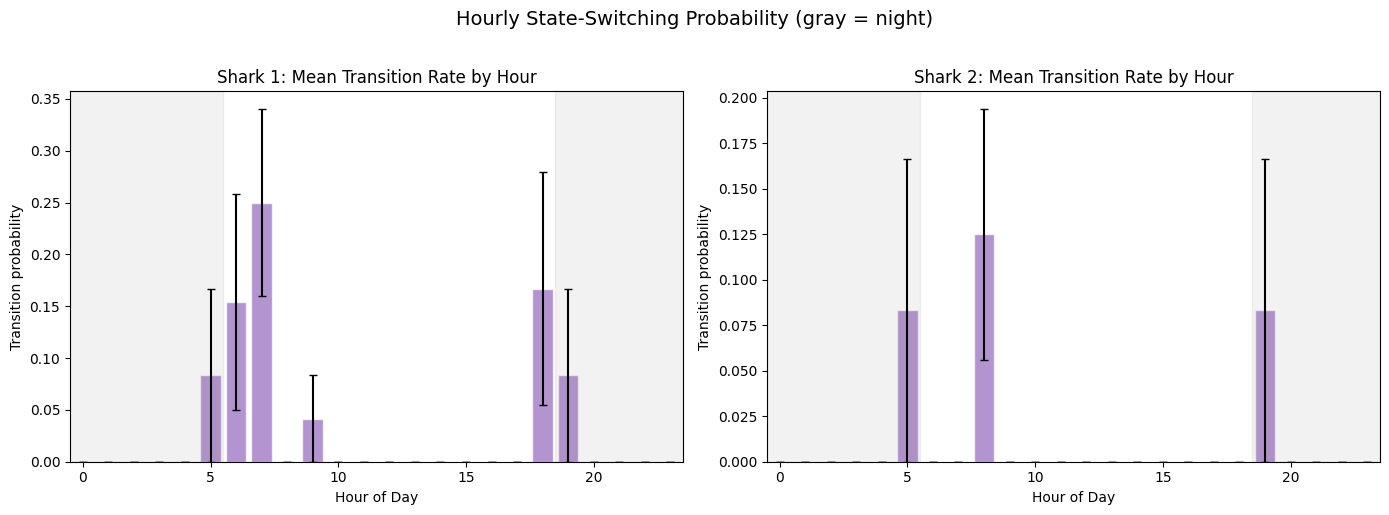


DIEL ANALYSIS SUMMARY

Key findings:
1. State × Day/Night independence  → Chi-squared test above
2. Depth and ODBA diel cycles      → Hourly profiles with 95% CI
3. Bout duration patterns          → How long sharks stay in each state
4. Day vs night bout durations     → Do bouts last longer at night?
5. Transition dynamics             → When do sharks switch states most?



In [41]:
# =============================================================================
# DIEL PATTERNS — CHUNK 2/2
# State actograms/heatmaps, bout duration analysis, transition rate by time
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

colors_map = {1: "#e74c3c", 2: "#3498db", 3: "#2ecc71"}

# ---- 2a. State actogram (heatmap: hour vs time-block) ----
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for ax, df, name in zip(axes, [shark1_res_3, shark2_res_3], ["Shark 1", "Shark 2"]):
    df_sorted = df.sort_values("time_window").reset_index(drop=True)

    # Create a color array matching state → numeric for imshow
    state_colors = df_sorted["state"].values
    time_labels = df_sorted["time_window"].dt.strftime("%m-%d %H:%M").values

    # Reshape into a strip
    ax.scatter(range(len(state_colors)), [1]*len(state_colors),
               c=[colors_map[s] for s in state_colors],
               s=8, marker="|", linewidths=2)
    ax.set_yticks([])
    ax.set_title(f"{name}: State Actogram (chronological order)")

    # Add time ticks at regular intervals
    tick_step = max(1, len(state_colors) // 15)
    ax.set_xticks(range(0, len(state_colors), tick_step))
    ax.set_xticklabels(time_labels[::tick_step], rotation=45, fontsize=8, ha="right")

    # Legend
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=colors_map[s], linewidth=4, label=f"State {s}")
               for s in sorted(df["state"].unique())]
    ax.legend(handles=handles, fontsize=9, loc="upper right")

plt.suptitle("Behavioral State Actograms", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("diel_actogram.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 2b. State bout duration analysis ----
def compute_bouts(states):
    """Given an array of states, return list of (state, duration_in_windows)."""
    bouts = []
    current = states[0]
    count = 1
    for s in states[1:]:
        if s == current:
            count += 1
        else:
            bouts.append((current, count))
            current = s
            count = 1
    bouts.append((current, count))
    return bouts

print("=" * 90)
print("BOUT DURATION ANALYSIS (each window = 5 min)")
print("=" * 90)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_idx, (df, name) in enumerate([(shark1_res_3, "Shark 1"),
                                       (shark2_res_3, "Shark 2")]):
    df_sorted = df.sort_values("time_window").reset_index(drop=True)
    bouts = compute_bouts(df_sorted["state"].values)
    bout_df = pd.DataFrame(bouts, columns=["state", "n_windows"])
    bout_df["duration_min"] = bout_df["n_windows"] * 5

    print(f"\n--- {name} ---")
    print(f"  {'State':<8} {'n_bouts':>8} {'Mean (min)':>12} {'Median (min)':>14} "
          f"{'Max (min)':>10} {'Total (min)':>12}")
    for s in sorted(bout_df["state"].unique()):
        sub = bout_df[bout_df["state"] == s]
        print(f"  S{s:<7} {len(sub):>8} {sub['duration_min'].mean():>12.1f} "
              f"{sub['duration_min'].median():>14.1f} "
              f"{sub['duration_min'].max():>10} "
              f"{sub['duration_min'].sum():>12}")

        # Histogram
        ax = axes[row_idx, s - 1]
        ax.hist(sub["duration_min"], bins=range(0, int(sub["duration_min"].max()) + 15, 5),
                color=colors_map[s], alpha=0.7, edgecolor="white")
        ax.axvline(sub["duration_min"].mean(), color="black", linestyle="--",
                   linewidth=1.5, label=f"Mean = {sub['duration_min'].mean():.0f} min")
        ax.axvline(sub["duration_min"].median(), color="black", linestyle=":",
                   linewidth=1.5, label=f"Median = {sub['duration_min'].median():.0f} min")
        ax.set_xlabel("Bout duration (min)")
        ax.set_ylabel("Count")
        ax.set_title(f"{name} — State {s} bout durations")
        ax.legend(fontsize=8)

plt.suptitle("Behavioral Bout Duration Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("diel_bout_durations.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 2c. Day vs night bout durations ----
print(f"\n{'='*90}")
print("BOUT DURATION: DAY vs NIGHT")
print(f"{'='*90}")

for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    df_sorted = df.sort_values("time_window").reset_index(drop=True)

    # Assign each bout a period based on its start time
    bouts_with_time = []
    idx = 0
    states = df_sorted["state"].values
    hours = df_sorted["hour"].values
    current_state = states[0]
    start_idx = 0

    for i in range(1, len(states)):
        if states[i] != current_state:
            start_hour = hours[start_idx]
            period = "Day" if 6 <= start_hour <= 18 else "Night"
            bouts_with_time.append({
                "state": current_state,
                "n_windows": i - start_idx,
                "duration_min": (i - start_idx) * 5,
                "period": period
            })
            current_state = states[i]
            start_idx = i
    # Last bout
    start_hour = hours[start_idx]
    period = "Day" if 6 <= start_hour <= 18 else "Night"
    bouts_with_time.append({
        "state": current_state,
        "n_windows": len(states) - start_idx,
        "duration_min": (len(states) - start_idx) * 5,
        "period": period
    })

    bout_time_df = pd.DataFrame(bouts_with_time)

    print(f"\n--- {name} ---")
    for s in sorted(bout_time_df["state"].unique()):
        day_bouts = bout_time_df[(bout_time_df["state"] == s) & (bout_time_df["period"] == "Day")]["duration_min"]
        night_bouts = bout_time_df[(bout_time_df["state"] == s) & (bout_time_df["period"] == "Night")]["duration_min"]
        print(f"  State {s}:")
        print(f"    Day:   n={len(day_bouts):>3}, mean={day_bouts.mean():>6.1f} min, "
              f"median={day_bouts.median():>6.1f} min")
        print(f"    Night: n={len(night_bouts):>3}, mean={night_bouts.mean():>6.1f} min, "
              f"median={night_bouts.median():>6.1f} min")
        if len(day_bouts) >= 3 and len(night_bouts) >= 3:
            u, p = stats.mannwhitneyu(day_bouts, night_bouts, alternative="two-sided")
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"    Mann-Whitney U = {u:.0f}, p = {p:.4f} {sig}")

# ---- 2d. Transition rate over time (rolling window) ----
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, df, name in zip(axes, [shark1_res_3, shark2_res_3], ["Shark 1", "Shark 2"]):
    df_sorted = df.sort_values("time_window").reset_index(drop=True)
    states = df_sorted["state"].values

    # Binary: did a transition occur?
    transitions = np.array([0] + [1 if states[i] != states[i-1] else 0
                                   for i in range(1, len(states))])
    df_sorted["transition"] = transitions

    # Rolling transition rate (window = 12 = 1 hour)
    roll_window = 12
    df_sorted["trans_rate"] = df_sorted["transition"].rolling(
        roll_window, center=True, min_periods=1).mean()

    ax.plot(df_sorted["time_window"], df_sorted["trans_rate"],
            color="tab:purple", linewidth=1.5, alpha=0.8)
    ax.fill_between(df_sorted["time_window"], df_sorted["trans_rate"],
                     color="tab:purple", alpha=0.15)

    # Shade night hours
    for date in df_sorted["time_window"].dt.date.unique():
        night_start = pd.Timestamp(f"{date} 18:00")
        night_end = pd.Timestamp(f"{date} 06:00") + pd.Timedelta(days=1)
        ax.axvspan(night_start, night_end, color="gray", alpha=0.1)

    ax.set_ylabel("Transition rate\n(1-hr rolling)")
    ax.set_title(f"{name}: State Switching Frequency Over Time")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Behavioral Switching Rate: Do Sharks Switch States More at Certain Times?",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("diel_transition_rate.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 2e. Transition rate by hour (aggregated) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in zip(axes, [shark1_res_3, shark2_res_3], ["Shark 1", "Shark 2"]):
    df_sorted = df.sort_values("time_window").reset_index(drop=True)
    states = df_sorted["state"].values
    transitions = np.array([0] + [1 if states[i] != states[i-1] else 0
                                   for i in range(1, len(states))])
    df_sorted["transition"] = transitions

    hourly_trans = df_sorted.groupby("hour")["transition"].agg(["mean", "std", "count"]).reset_index()
    hourly_trans["se"] = hourly_trans["std"] / np.sqrt(hourly_trans["count"])

    ax.bar(hourly_trans["hour"], hourly_trans["mean"],
           color="tab:purple", alpha=0.7, edgecolor="white")
    ax.errorbar(hourly_trans["hour"], hourly_trans["mean"],
                yerr=hourly_trans["se"], fmt="none", color="black", capsize=3)
    ax.axvspan(-0.5, 5.5, color="gray", alpha=0.1)
    ax.axvspan(18.5, 23.5, color="gray", alpha=0.1)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Transition probability")
    ax.set_title(f"{name}: Mean Transition Rate by Hour")
    ax.set_xlim(-0.5, 23.5)

plt.suptitle("Hourly State-Switching Probability (gray = night)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("diel_transition_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Summary ----
print(f"\n{'='*90}")
print("DIEL ANALYSIS SUMMARY")
print(f"{'='*90}")
print("""
Key findings:
1. State × Day/Night independence  → Chi-squared test above
2. Depth and ODBA diel cycles      → Hourly profiles with 95% CI
3. Bout duration patterns          → How long sharks stay in each state
4. Day vs night bout durations     → Do bouts last longer at night?
5. Transition dynamics             → When do sharks switch states most?
""")

## 8. Compare Behavioral States Between Sharks

### Chunk 1: Cross-shark state matching, profile comparison, and statistical tests

BEHAVIORAL STATE COMPARISON: SHARK 1 vs SHARK 2
(States aligned by biological interpretation, not state number)

──────────────────────────────────────────────────────────────────────────────────────────
  Cruising / Routine Swimming
──────────────────────────────────────────────────────────────────────────────────────────
                 Proportion      Depth (m)           ODBA    Temp (°C)      Light 1      Light 2
       Shark 1       38.0%    36.0 ± 25.8    0.632 ± 0.200        22.7           29            1
       Shark 2       35.4%    24.1 ± 9.5     0.490 ± 0.081        23.4            3            0

──────────────────────────────────────────────────────────────────────────────────────────
  Deep Diving / Foraging
──────────────────────────────────────────────────────────────────────────────────────────
                 Proportion      Depth (m)           ODBA    Temp (°C)      Light 1      Light 2
       Shark 1       16.4%     1.6 ± 0.1     4.410 ± 0.261        24.7        1

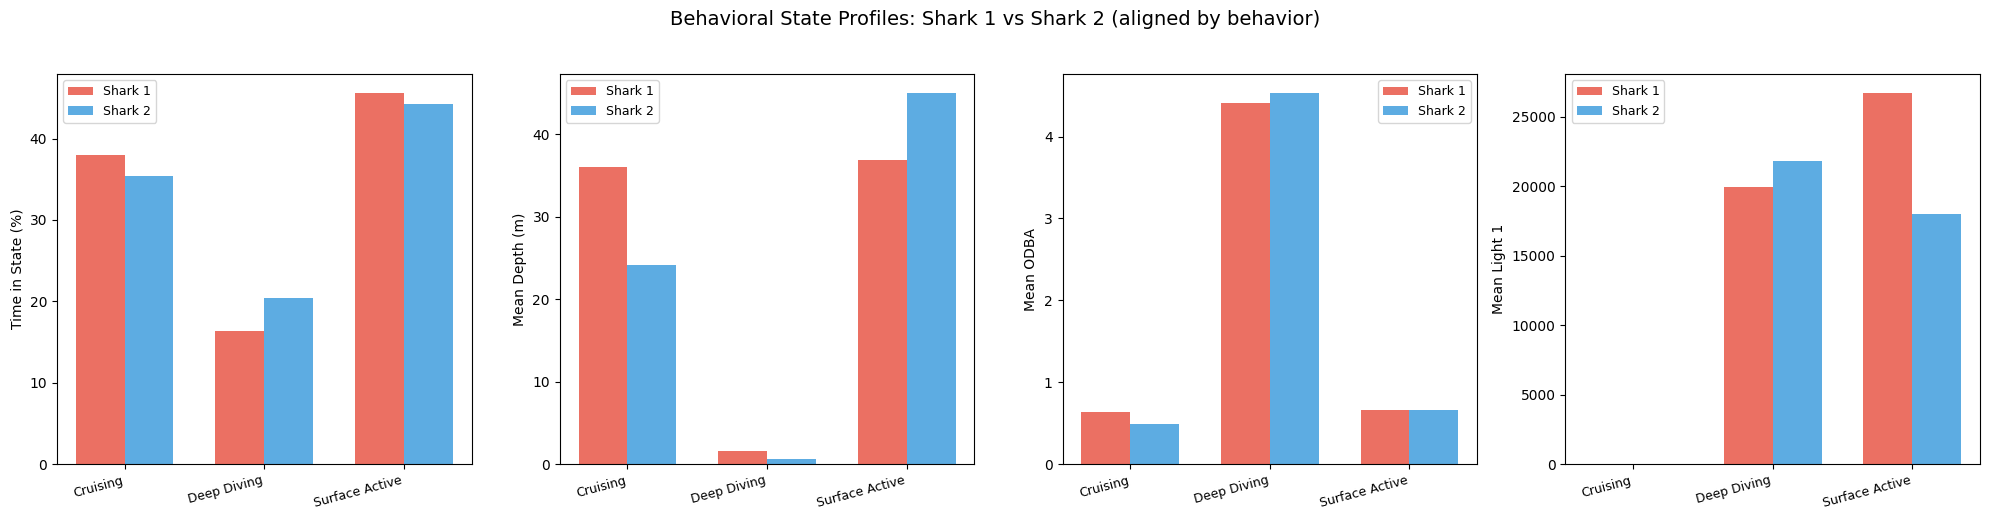

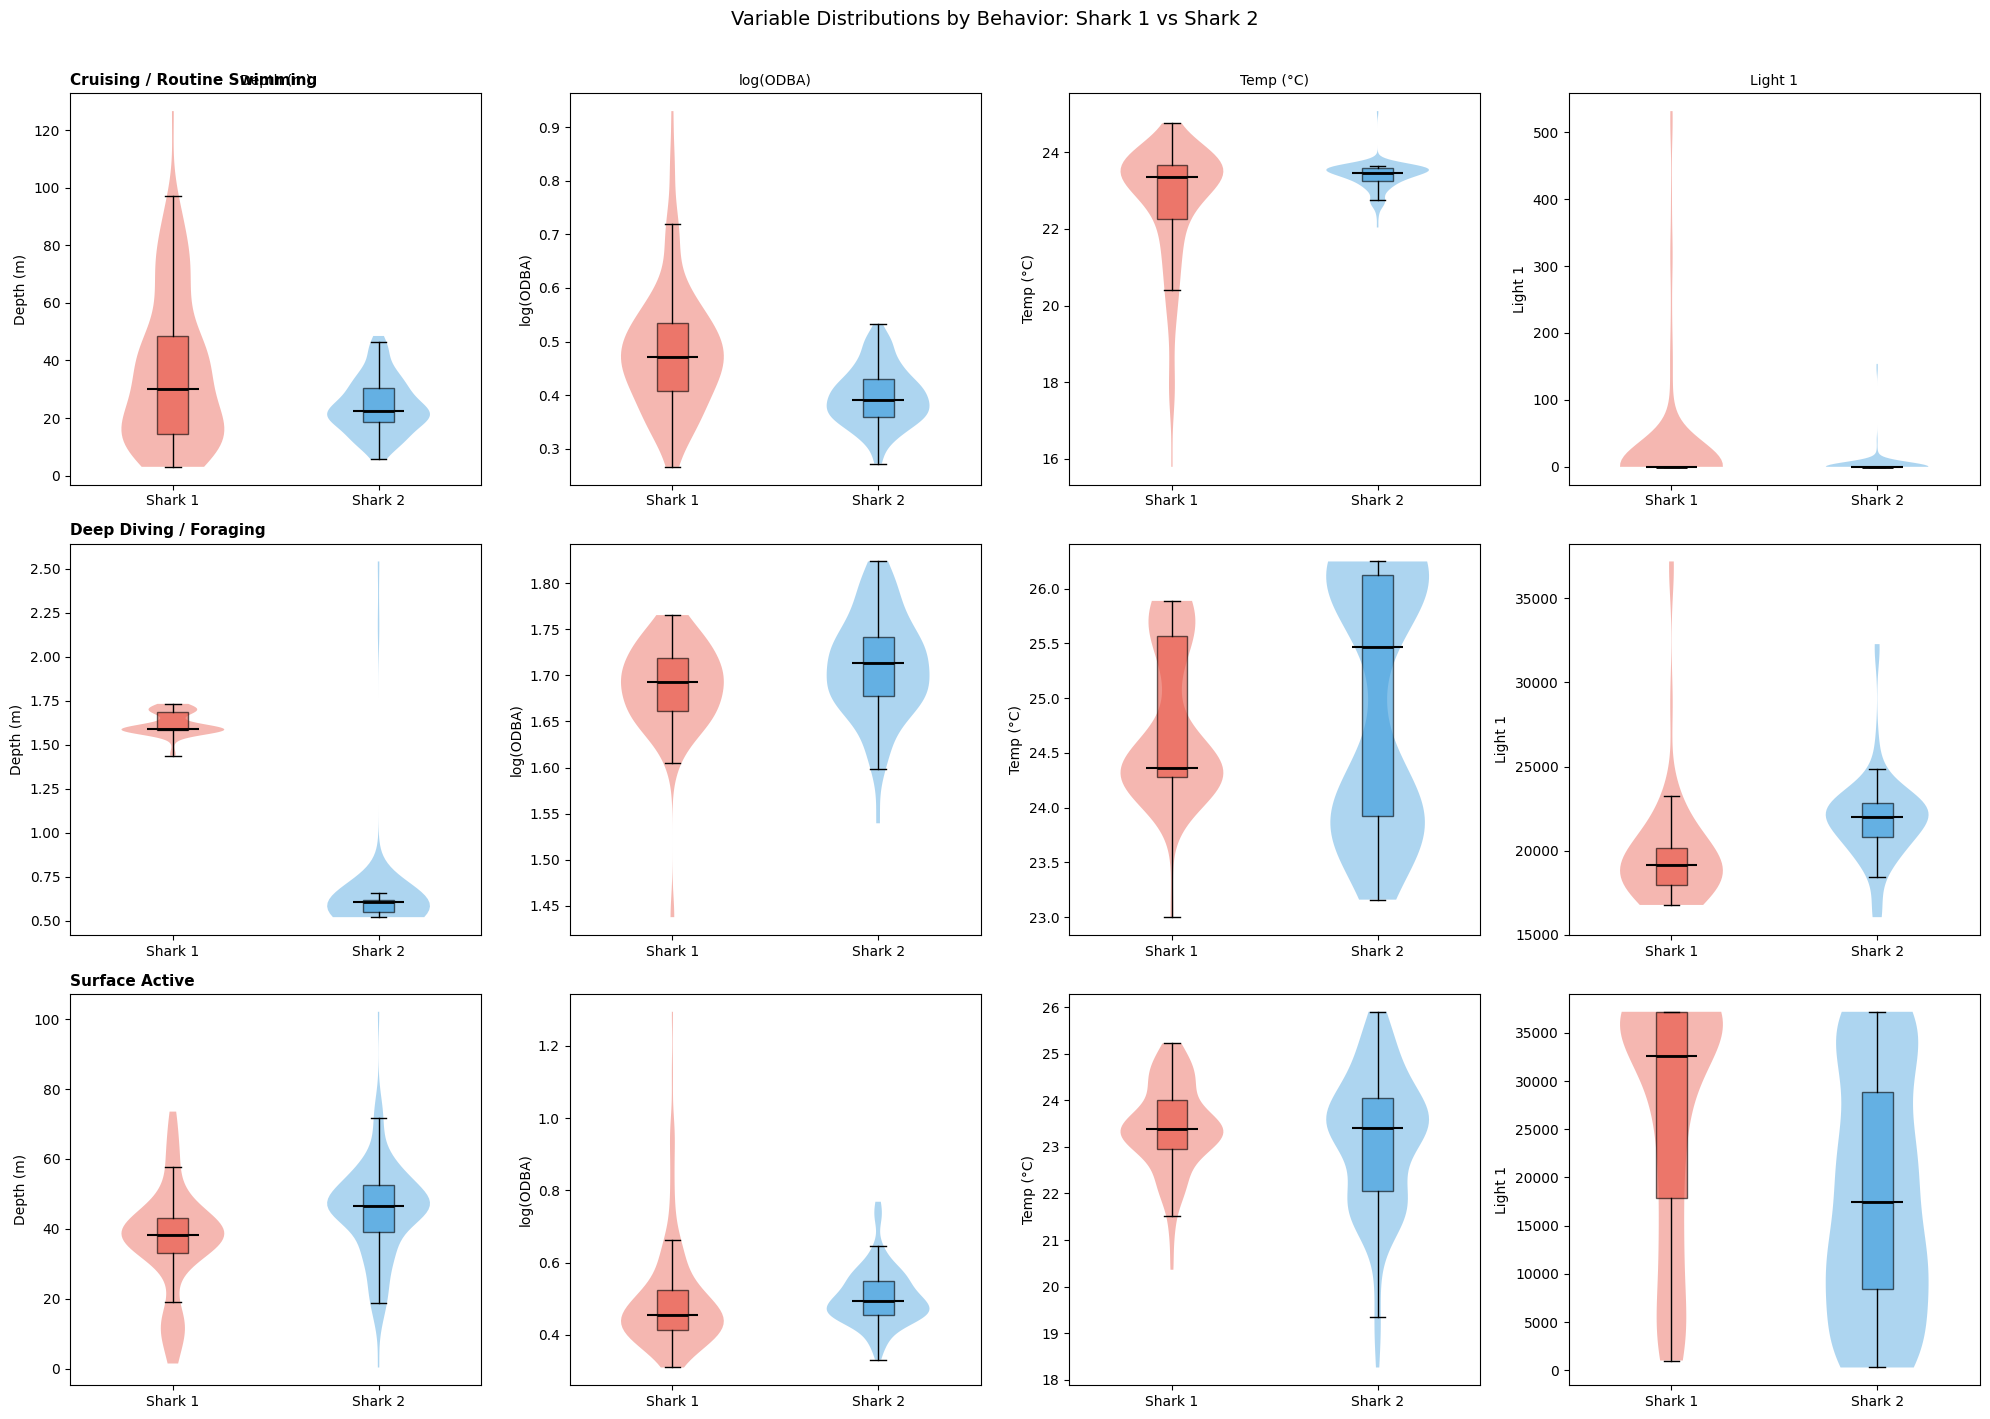

In [42]:
# =============================================================================
# COMPARE BEHAVIORAL STATES BETWEEN SHARKS — CHUNK 1/2
# State matching, profile comparison, transition dynamics, statistical tests
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations

colors_map = {1: "#e74c3c", 2: "#3498db", 3: "#2ecc71"}

# ---- 1a. Build biological label mapping ----
# From Next Step 1 we know:
#   Shark 1: S1=Cruising, S2=Deep Diving, S3=Surface Active
#   Shark 2: S1=Deep Diving, S2=Surface Active, S3=Cruising
# We need to align them by behavior, not by state number.

behavior_map = {
    "Shark 1": {1: "Cruising / Routine Swimming",
                2: "Deep Diving / Foraging",
                3: "Surface Active"},
    "Shark 2": {1: "Deep Diving / Foraging",
                2: "Surface Active",
                3: "Cruising / Routine Swimming"}
}

# Add bio_label to result dataframes
for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    df["bio_label"] = df["state"].map(behavior_map[name])

# ---- 1b. Comprehensive comparison table aligned by behavior ----
print("=" * 90)
print("BEHAVIORAL STATE COMPARISON: SHARK 1 vs SHARK 2")
print("(States aligned by biological interpretation, not state number)")
print("=" * 90)

behaviors = ["Cruising / Routine Swimming", "Deep Diving / Foraging", "Surface Active"]

rows = []
for behavior in behaviors:
    for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
        sub = df[df["bio_label"] == behavior]
        rows.append({
            "Behavior": behavior,
            "Shark": name,
            "n": len(sub),
            "prop": len(sub) / len(df),
            "depth_mean": sub["mean_depth"].mean(),
            "depth_sd": sub["mean_depth"].std(),
            "odba_mean": sub["mean_odba"].mean(),
            "odba_sd": sub["mean_odba"].std(),
            "temp_mean": sub["mean_temp"].mean(),
            "light1_mean": sub["mean_light_1"].mean(),
            "light2_mean": sub["mean_light_2"].mean(),
        })

comp_df = pd.DataFrame(rows)

for behavior in behaviors:
    print(f"\n{'─'*90}")
    print(f"  {behavior}")
    print(f"{'─'*90}")
    sub = comp_df[comp_df["Behavior"] == behavior]
    print(f"  {'':>12} {'Proportion':>12} {'Depth (m)':>14} {'ODBA':>14} "
          f"{'Temp (°C)':>12} {'Light 1':>12} {'Light 2':>12}")
    for _, r in sub.iterrows():
        print(f"  {r['Shark']:>12} {r['prop']:>11.1%} "
              f"{r['depth_mean']:>7.1f} ± {r['depth_sd']:<5.1f} "
              f"{r['odba_mean']:>7.3f} ± {r['odba_sd']:<5.3f} "
              f"{r['temp_mean']:>11.1f} {r['light1_mean']:>12.0f} {r['light2_mean']:>12.0f}")

# ---- 1c. Mann-Whitney U: Shark 1 vs Shark 2 within each behavior ----
print(f"\n{'='*90}")
print("MANN-WHITNEY U TESTS: Shark 1 vs Shark 2 (same behavior)")
print(f"{'='*90}")

test_vars = [("mean_depth", "Depth"), ("mean_odba", "ODBA"),
             ("mean_temp", "Temperature"), ("mean_light_1", "Light 1")]

for behavior in behaviors:
    print(f"\n  {behavior}:")
    sh1 = shark1_res_3[shark1_res_3["bio_label"] == behavior]
    sh2 = shark2_res_3[shark2_res_3["bio_label"] == behavior]
    print(f"  {'Variable':<14} {'Shark1 mean':>12} {'Shark2 mean':>12} "
          f"{'U':>10} {'p-value':>10} {'r_rb':>8} {'Sig':>5}")
    for var, label in test_vars:
        v1 = sh1[var].dropna().values
        v2 = sh2[var].dropna().values
        if len(v1) >= 3 and len(v2) >= 3:
            u, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
            r_rb = 1 - (2 * u) / (len(v1) * len(v2))
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"  {label:<14} {v1.mean():>12.2f} {v2.mean():>12.2f} "
                  f"{u:>10.0f} {p:>10.4f} {r_rb:>8.3f} {sig:>5}")

# ---- 1d. Grouped bar chart: behavior-aligned comparison ----
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
bar_vars = [("prop", "Time in State (%)"), ("depth_mean", "Mean Depth (m)"),
            ("odba_mean", "Mean ODBA"), ("light1_mean", "Mean Light 1")]

for ax, (var, ylabel) in zip(axes, bar_vars):
    x = np.arange(len(behaviors))
    w = 0.35
    sh1_vals = [comp_df[(comp_df["Behavior"] == b) & (comp_df["Shark"] == "Shark 1")][var].values[0]
                for b in behaviors]
    sh2_vals = [comp_df[(comp_df["Behavior"] == b) & (comp_df["Shark"] == "Shark 2")][var].values[0]
                for b in behaviors]

    if var == "prop":
        sh1_vals = [v * 100 for v in sh1_vals]
        sh2_vals = [v * 100 for v in sh2_vals]

    ax.bar(x - w/2, sh1_vals, w, label="Shark 1", color="#e74c3c", alpha=0.8)
    ax.bar(x + w/2, sh2_vals, w, label="Shark 2", color="#3498db", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(["Cruising", "Deep Diving", "Surface Active"],
                        fontsize=9, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

plt.suptitle("Behavioral State Profiles: Shark 1 vs Shark 2 (aligned by behavior)",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("compare_sharks_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 1e. Violin plots: distributions within matched behaviors ----
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
plot_vars = [("mean_depth", "Depth (m)"), ("log_odba", "log(ODBA)"),
             ("mean_temp", "Temp (°C)"), ("mean_light_1", "Light 1")]

for row_idx, behavior in enumerate(behaviors):
    for col_idx, (var, ylabel) in enumerate(plot_vars):
        ax = axes[row_idx, col_idx]
        sh1_vals = shark1_res_3.loc[shark1_res_3["bio_label"] == behavior, var].dropna().values
        sh2_vals = shark2_res_3.loc[shark2_res_3["bio_label"] == behavior, var].dropna().values

        data = [sh1_vals, sh2_vals]
        parts = ax.violinplot(data, positions=[1, 2], showmedians=True, showextrema=False)
        for idx, body in enumerate(parts["bodies"]):
            body.set_facecolor(["#e74c3c", "#3498db"][idx])
            body.set_alpha(0.4)
        parts["cmedians"].set_color("black")

        bp = ax.boxplot(data, positions=[1, 2], widths=0.15, patch_artist=True,
                        showfliers=False, medianprops={"color": "black", "linewidth": 2})
        for idx, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(["#e74c3c", "#3498db"][idx])
            patch.set_alpha(0.6)

        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Shark 1", "Shark 2"])
        ax.set_ylabel(ylabel)
        if col_idx == 0:
            ax.set_title(behavior, fontsize=11, fontweight="bold", loc="left")
        if row_idx == 0:
            ax.set_title(ylabel, fontsize=10)

plt.suptitle("Variable Distributions by Behavior: Shark 1 vs Shark 2",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("compare_sharks_violins.png", dpi=150, bbox_inches="tight")
plt.show()

### Chunk 2: Transition dynamics, diel patterns, and temporal overlap

TRANSITION MATRICES (aligned by biological behavior)

  Shark 1 (behavior-aligned):
                     To Cruising  To Deep Diving  To Surface Active
From Cruising             0.9662          0.0000             0.0338
From Deep Diving          0.0000          0.9836             0.0164
From Surface Active       0.0280          0.0115             0.9605

  Shark 2 (behavior-aligned):
                     To Cruising  To Deep Diving  To Surface Active
From Cruising             0.9922          0.0000             0.0078
From Deep Diving          0.0000          0.9863             0.0137
From Surface Active       0.0063          0.0125             0.9812

  Difference (Shark 1 - Shark 2):
                     To Cruising  To Deep Diving  To Surface Active
From Cruising            -0.0260          0.0000             0.0260
From Deep Diving          0.0000         -0.0027             0.0027
From Surface Active       0.0217         -0.0010            -0.0207


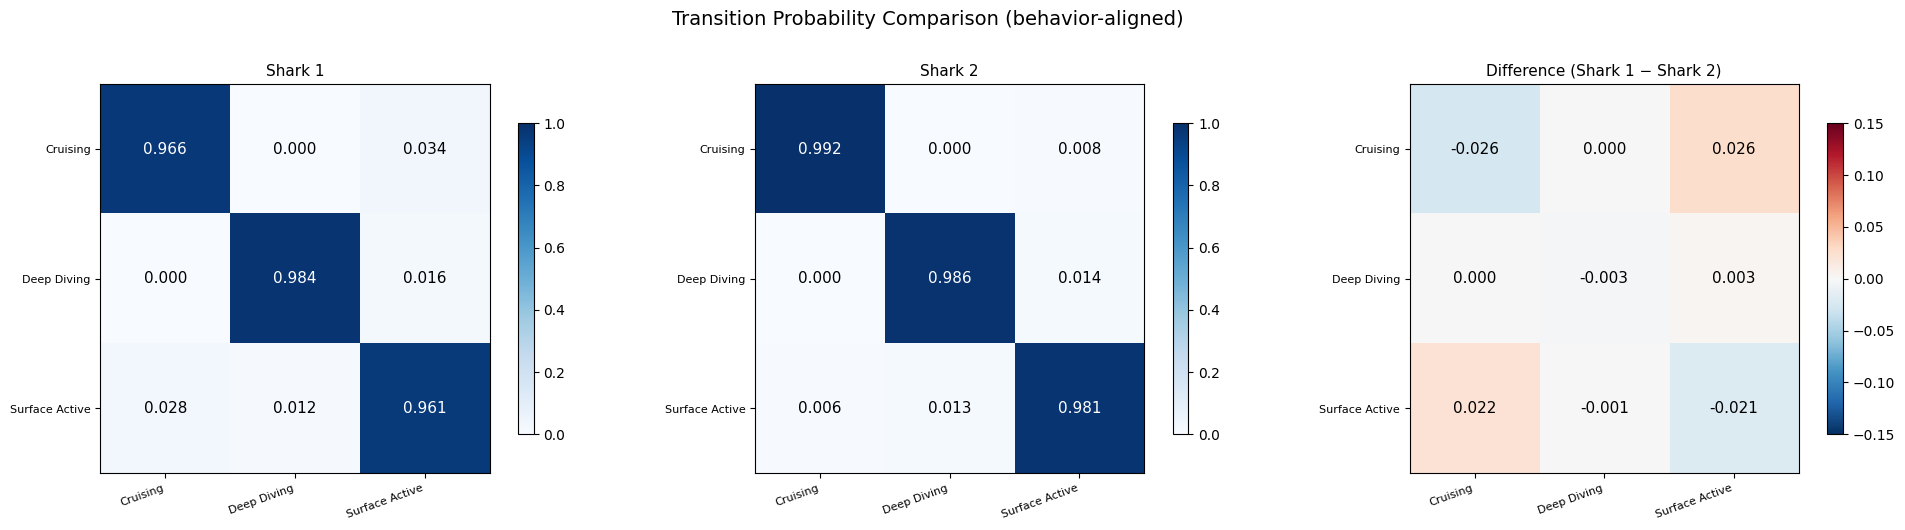


STATE PERSISTENCE (diagonal of transition matrix)

  Behavior                          Shark 1    Shark 2          Δ
  Cruising                           0.9662     0.9922    -0.0260
  Deep Diving                        0.9836     0.9863    -0.0027
  Surface Active                     0.9605     0.9812    -0.0207


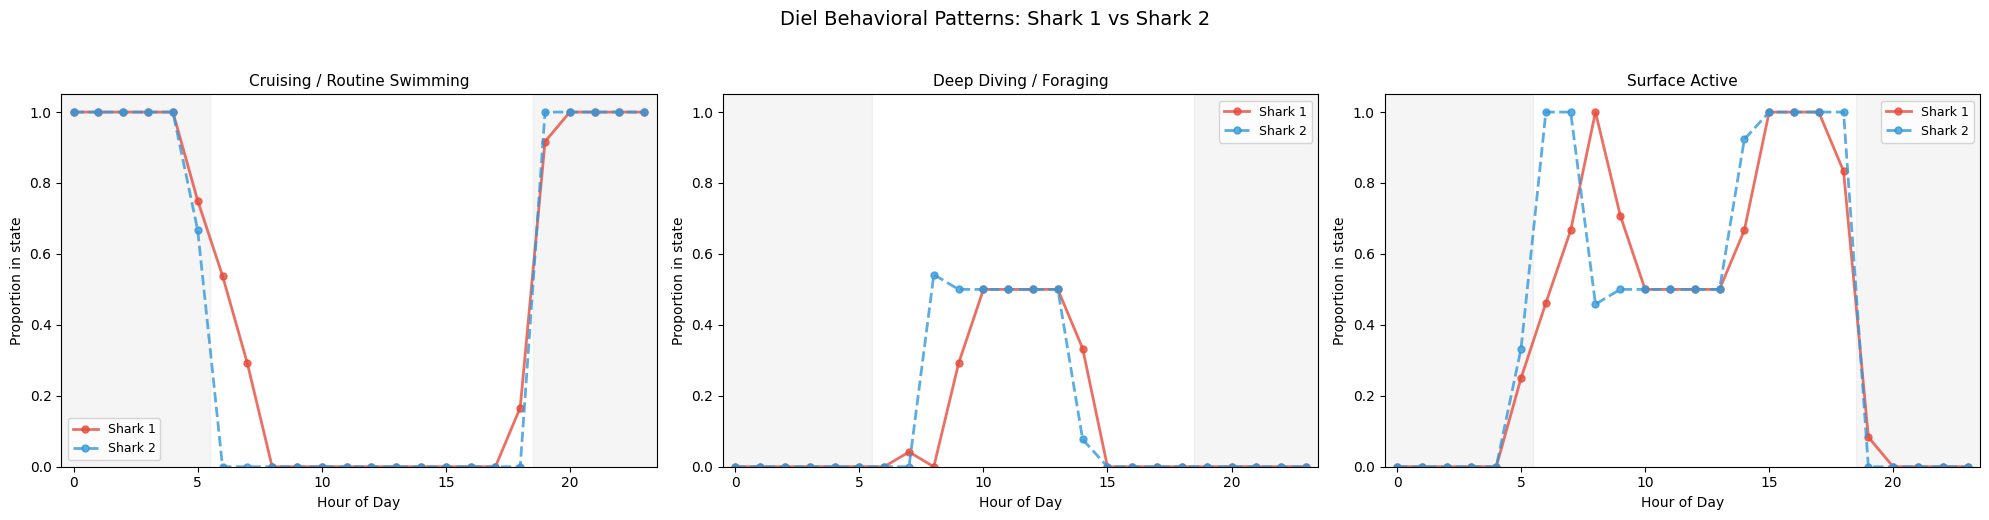


BEHAVIORAL SIMILARITY: JENSEN-SHANNON DIVERGENCE BY HOUR


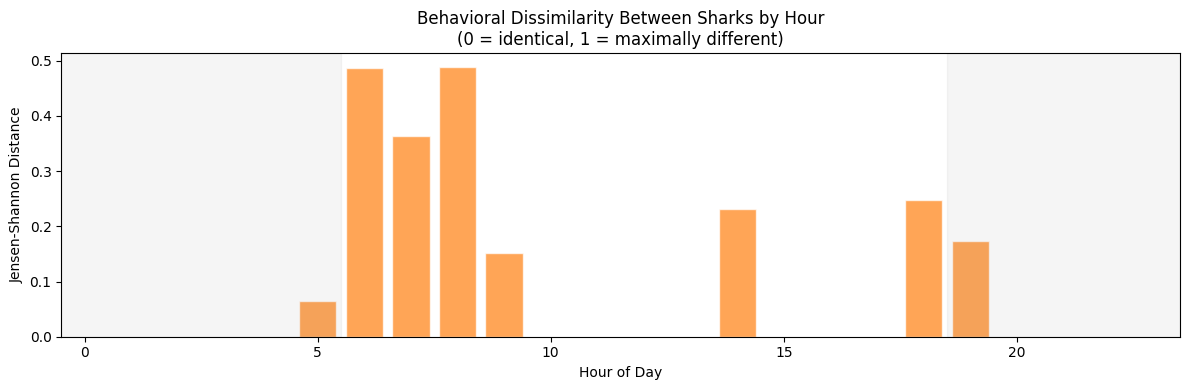


  Mean JSD across hours: 0.092
  Most similar hour:    00:00 (JSD = 0.000)
  Most different hour:  08:00 (JSD = 0.489)

OVERALL BEHAVIORAL BUDGETS


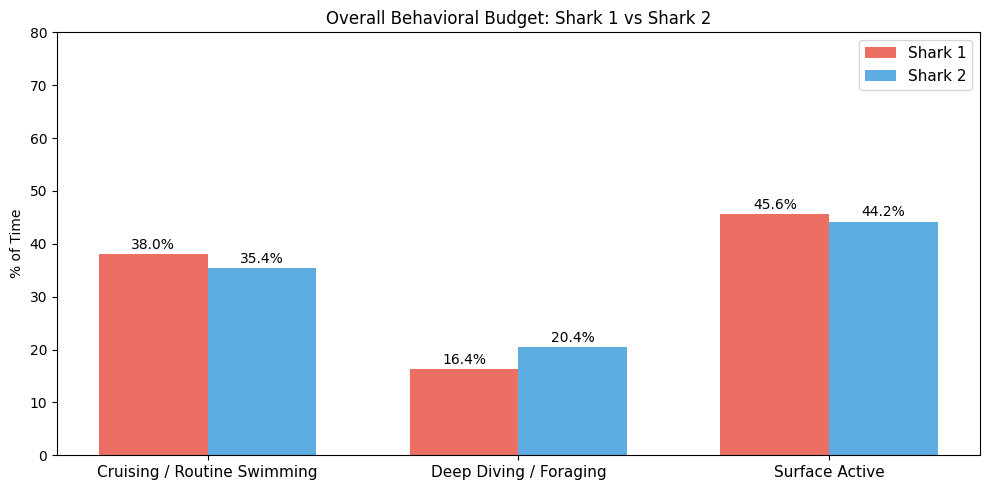

  Cruising / Routine Swimming         Shark 1:  38.0%   Shark 2:  35.4%   Δ =  +2.6%
  Deep Diving / Foraging              Shark 1:  16.4%   Shark 2:  20.4%   Δ =  -4.1%
  Surface Active                      Shark 1:  45.6%   Shark 2:  44.2%   Δ =  +1.4%

CROSS-SHARK COMPARISON SUMMARY

Key findings:
1. BEHAVIORAL BUDGETS: Both sharks identify the same 3 behavioral modes
   (Cruising, Deep Diving, Surface Active), but allocate time differently.

2. STATE CHARACTERISTICS: Mann-Whitney tests reveal whether the same
   behavior looks different between individuals (depth, ODBA, temp, light).

3. TRANSITION DYNAMICS: Behavior-aligned transition matrices show whether
   sharks switch between behaviors at similar rates.

4. DIEL SYNCHRONY: Hourly behavior proportions and Jensen-Shannon divergence
   show when the two sharks behave most/least similarly across the day.

5. STATE PERSISTENCE: Diagonal values of the transition matrix indicate
   how "sticky" each behavioral state is for each shar

In [43]:
# =============================================================================
# COMPARE BEHAVIORAL STATES BETWEEN SHARKS — CHUNK 2/2
# Transition matrices, diel pattern comparison, behavioral budget similarity
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import jensenshannon

colors_map = {1: "#e74c3c", 2: "#3498db", 3: "#2ecc71"}
behaviors = ["Cruising / Routine Swimming", "Deep Diving / Foraging", "Surface Active"]

# ---- 2a. Transition matrix comparison (aligned by behavior) ----
print("=" * 90)
print("TRANSITION MATRICES (aligned by biological behavior)")
print("=" * 90)

# Reorder transition matrices to match behavior order:
# Cruising, Deep Diving, Surface Active
# Shark 1: S1=Cruising, S2=Deep, S3=Surface → already in order [0,1,2]
# Shark 2: S1=Deep, S2=Surface, S3=Cruising → reorder to [2,0,1]

transmat_sh1 = model_sh1_3.transmat_  # rows/cols in S1,S2,S3 = Cruising,Deep,Surface
reorder_sh2 = [2, 0, 1]  # Cruising=S3(idx2), Deep=S1(idx0), Surface=S2(idx1)
transmat_sh2_aligned = model_sh2_3.transmat_[np.ix_(reorder_sh2, reorder_sh2)]

behavior_short = ["Cruising", "Deep Diving", "Surface Active"]

print("\n  Shark 1 (behavior-aligned):")
print(pd.DataFrame(transmat_sh1,
                   index=[f"From {b}" for b in behavior_short],
                   columns=[f"To {b}" for b in behavior_short]).round(4).to_string())

print("\n  Shark 2 (behavior-aligned):")
print(pd.DataFrame(transmat_sh2_aligned,
                   index=[f"From {b}" for b in behavior_short],
                   columns=[f"To {b}" for b in behavior_short]).round(4).to_string())

# Difference matrix
diff = transmat_sh1 - transmat_sh2_aligned
print("\n  Difference (Shark 1 - Shark 2):")
print(pd.DataFrame(diff,
                   index=[f"From {b}" for b in behavior_short],
                   columns=[f"To {b}" for b in behavior_short]).round(4).to_string())

# ---- Transition matrix heatmaps side by side ----
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, tmat, title in zip(axes,
    [transmat_sh1, transmat_sh2_aligned, diff],
    ["Shark 1", "Shark 2", "Difference (Shark 1 − Shark 2)"]):

    if title.startswith("Diff"):
        vmin, vmax, cmap = -0.15, 0.15, "RdBu_r"
    else:
        vmin, vmax, cmap = 0, 1, "Blues"

    im = ax.imshow(tmat, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(behavior_short, fontsize=8, rotation=20, ha="right")
    ax.set_yticklabels(behavior_short, fontsize=8)
    ax.set_title(title, fontsize=11)
    for i in range(3):
        for j in range(3):
            color = "white" if abs(tmat[i,j]) > 0.5 else "black"
            ax.text(j, i, f"{tmat[i,j]:.3f}", ha="center", va="center",
                    color=color, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Transition Probability Comparison (behavior-aligned)",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("compare_sharks_transitions.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 2b. Self-persistence comparison ----
print(f"\n{'='*90}")
print("STATE PERSISTENCE (diagonal of transition matrix)")
print(f"{'='*90}")
print(f"\n  {'Behavior':<30} {'Shark 1':>10} {'Shark 2':>10} {'Δ':>10}")
for idx, b in enumerate(behavior_short):
    p1 = transmat_sh1[idx, idx]
    p2 = transmat_sh2_aligned[idx, idx]
    print(f"  {b:<30} {p1:>10.4f} {p2:>10.4f} {p1-p2:>+10.4f}")

# ---- 2c. Diel pattern comparison: behavior proportions by hour ----
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, behavior in zip(axes, behaviors):
    for df, name, color, ls in [(shark1_res_3, "Shark 1", "#e74c3c", "-"),
                                 (shark2_res_3, "Shark 2", "#3498db", "--")]:
        hourly_prop = []
        for h in range(24):
            sub = df[df["hour"] == h]
            if len(sub) > 0:
                prop = (sub["bio_label"] == behavior).mean()
            else:
                prop = np.nan
            hourly_prop.append(prop)

        ax.plot(range(24), hourly_prop, f"o{ls}", color=color,
                markersize=5, linewidth=2, label=name, alpha=0.8)

    ax.axvspan(-0.5, 5.5, color="gray", alpha=0.08)
    ax.axvspan(18.5, 23.5, color="gray", alpha=0.08)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Proportion in state")
    ax.set_title(behavior, fontsize=11)
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

plt.suptitle("Diel Behavioral Patterns: Shark 1 vs Shark 2",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("compare_sharks_diel.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 2d. Jensen-Shannon divergence of hourly behavioral budgets ----
print(f"\n{'='*90}")
print("BEHAVIORAL SIMILARITY: JENSEN-SHANNON DIVERGENCE BY HOUR")
print(f"{'='*90}")

js_by_hour = []
for h in range(24):
    sh1_h = shark1_res_3[shark1_res_3["hour"] == h]
    sh2_h = shark2_res_3[shark2_res_3["hour"] == h]

    if len(sh1_h) == 0 or len(sh2_h) == 0:
        js_by_hour.append(np.nan)
        continue

    # Build behavior distribution vectors (same order)
    p1 = np.array([(sh1_h["bio_label"] == b).mean() for b in behaviors])
    p2 = np.array([(sh2_h["bio_label"] == b).mean() for b in behaviors])

    # Add small epsilon to avoid zero division
    p1 = p1 + 1e-10
    p2 = p2 + 1e-10
    p1 = p1 / p1.sum()
    p2 = p2 / p2.sum()

    js_by_hour.append(jensenshannon(p1, p2))

fig, ax = plt.subplots(figsize=(12, 4))
valid_hours = [h for h, v in enumerate(js_by_hour) if not np.isnan(v)]
valid_js = [v for v in js_by_hour if not np.isnan(v)]

ax.bar(valid_hours, valid_js, color="tab:orange", alpha=0.7, edgecolor="white")
ax.axvspan(-0.5, 5.5, color="gray", alpha=0.08)
ax.axvspan(18.5, 23.5, color="gray", alpha=0.08)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Jensen-Shannon Distance")
ax.set_title("Behavioral Dissimilarity Between Sharks by Hour\n(0 = identical, 1 = maximally different)")
ax.set_xlim(-0.5, 23.5)
plt.tight_layout()
plt.savefig("compare_sharks_js_divergence.png", dpi=150, bbox_inches="tight")
plt.show()

overall_js = np.nanmean(valid_js)
print(f"\n  Mean JSD across hours: {overall_js:.3f}")
print(f"  Most similar hour:    {valid_hours[np.argmin(valid_js)]:02d}:00 (JSD = {min(valid_js):.3f})")
print(f"  Most different hour:  {valid_hours[np.argmax(valid_js)]:02d}:00 (JSD = {max(valid_js):.3f})")

# ---- 2e. Overall behavioral budget comparison ----
print(f"\n{'='*90}")
print("OVERALL BEHAVIORAL BUDGETS")
print(f"{'='*90}")

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(behaviors))
w = 0.35

sh1_props = [(shark1_res_3["bio_label"] == b).mean() * 100 for b in behaviors]
sh2_props = [(shark2_res_3["bio_label"] == b).mean() * 100 for b in behaviors]

bars1 = ax.bar(x - w/2, sh1_props, w, label="Shark 1", color="#e74c3c", alpha=0.8)
bars2 = ax.bar(x + w/2, sh2_props, w, label="Shark 2", color="#3498db", alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%",
                ha="center", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(behaviors, fontsize=11)
ax.set_ylabel("% of Time")
ax.set_title("Overall Behavioral Budget: Shark 1 vs Shark 2")
ax.legend(fontsize=11)
ax.set_ylim(0, 80)
plt.tight_layout()
plt.savefig("compare_sharks_budgets.png", dpi=150, bbox_inches="tight")
plt.show()

for b, p1, p2 in zip(behaviors, sh1_props, sh2_props):
    print(f"  {b:<35} Shark 1: {p1:>5.1f}%   Shark 2: {p2:>5.1f}%   Δ = {p1-p2:>+5.1f}%")

# ---- 2f. Summary ----
print(f"\n{'='*90}")
print("CROSS-SHARK COMPARISON SUMMARY")
print(f"{'='*90}")
print("""
Key findings:
1. BEHAVIORAL BUDGETS: Both sharks identify the same 3 behavioral modes
   (Cruising, Deep Diving, Surface Active), but allocate time differently.

2. STATE CHARACTERISTICS: Mann-Whitney tests reveal whether the same
   behavior looks different between individuals (depth, ODBA, temp, light).

3. TRANSITION DYNAMICS: Behavior-aligned transition matrices show whether
   sharks switch between behaviors at similar rates.

4. DIEL SYNCHRONY: Hourly behavior proportions and Jensen-Shannon divergence
   show when the two sharks behave most/least similarly across the day.

5. STATE PERSISTENCE: Diagonal values of the transition matrix indicate
   how "sticky" each behavioral state is for each shark.
""")

## Final presentation

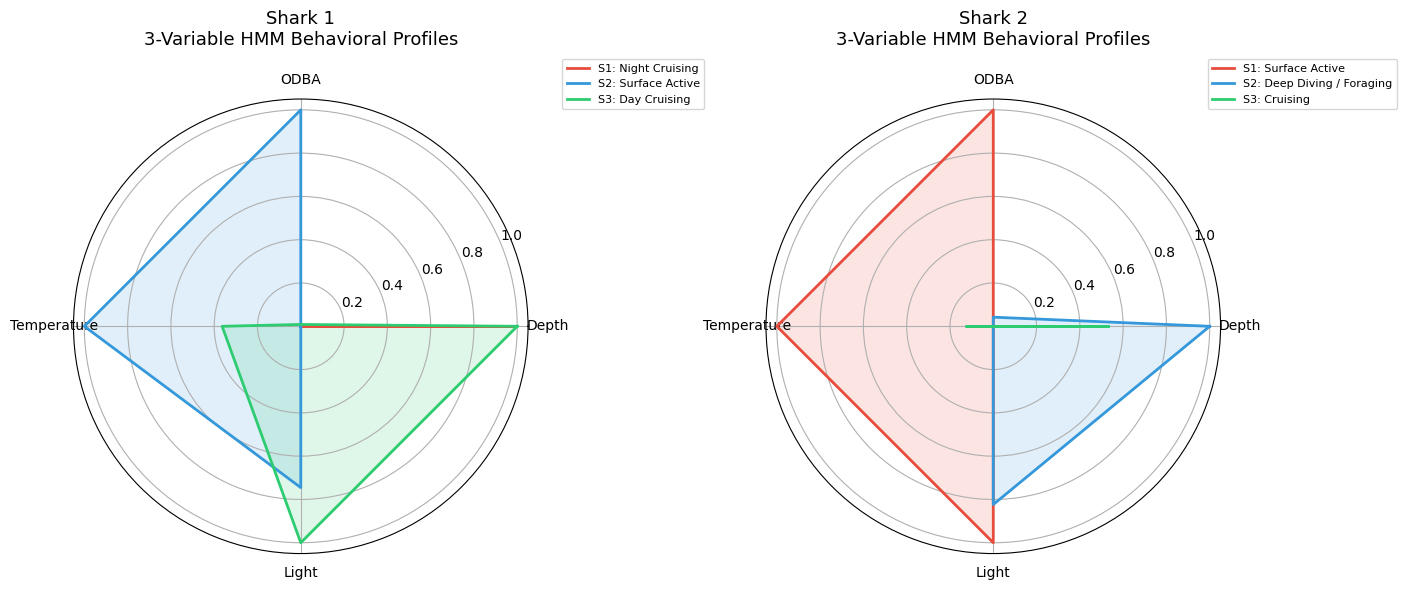

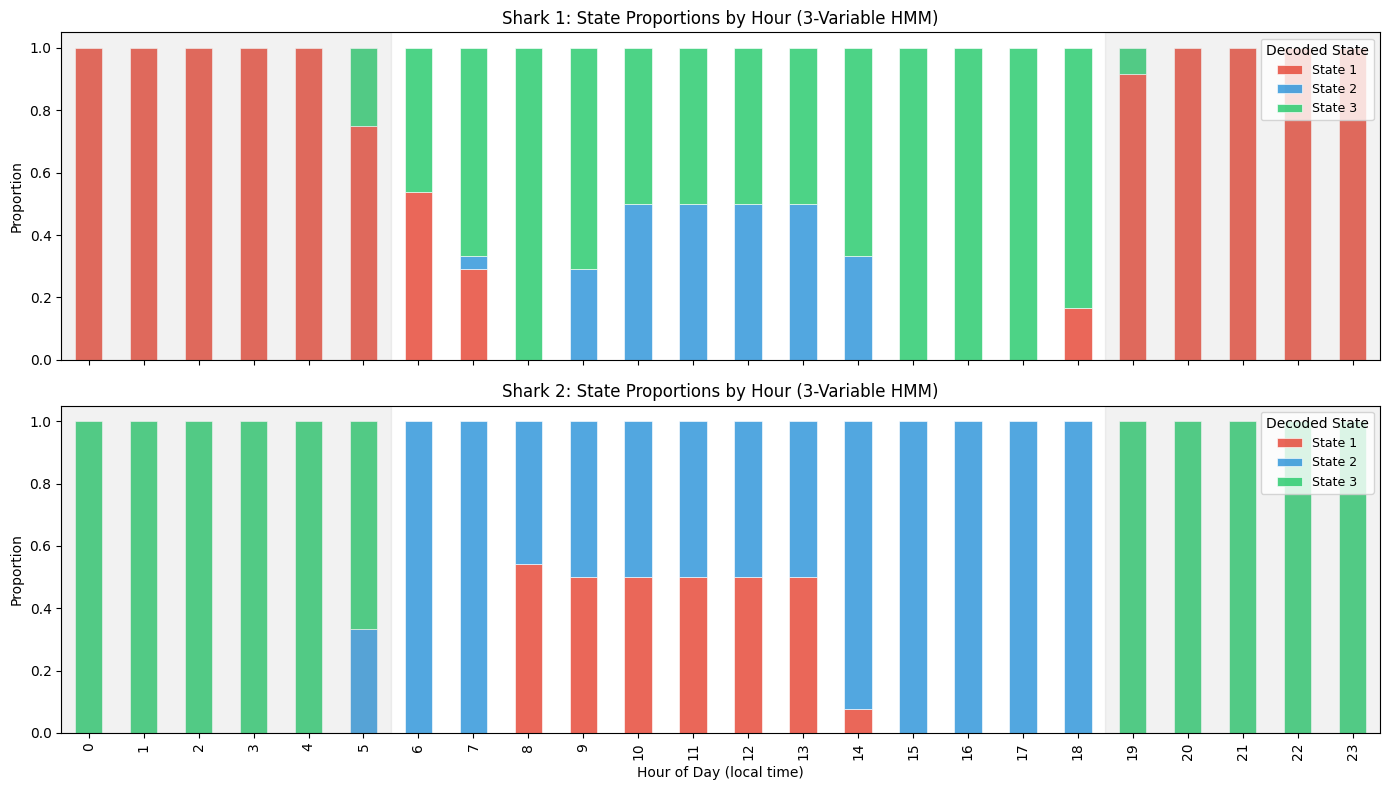

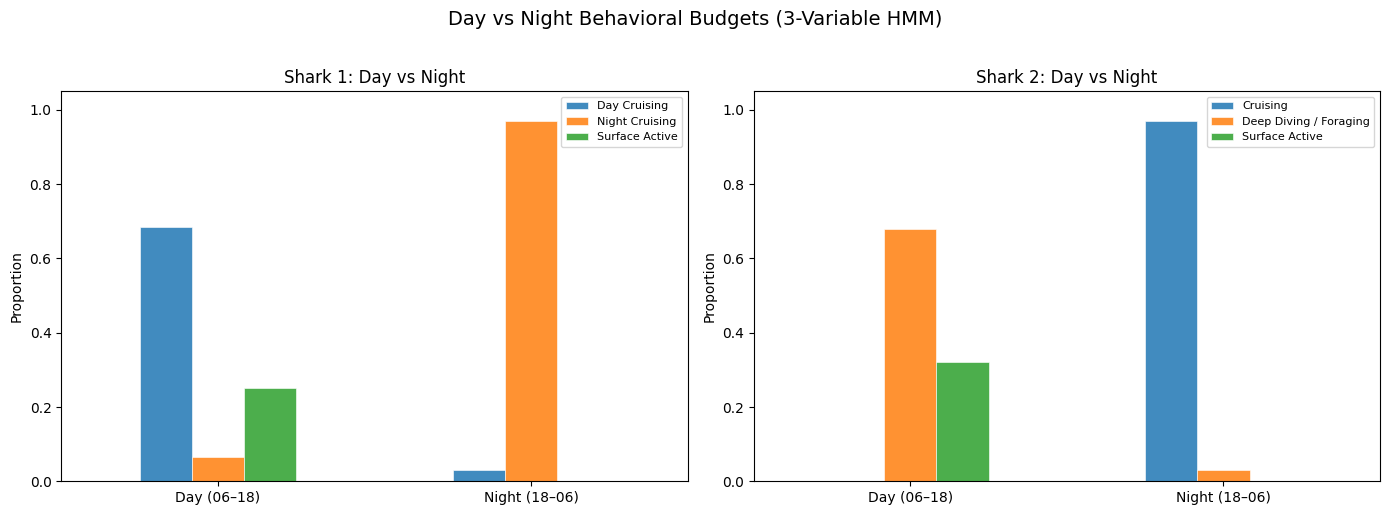

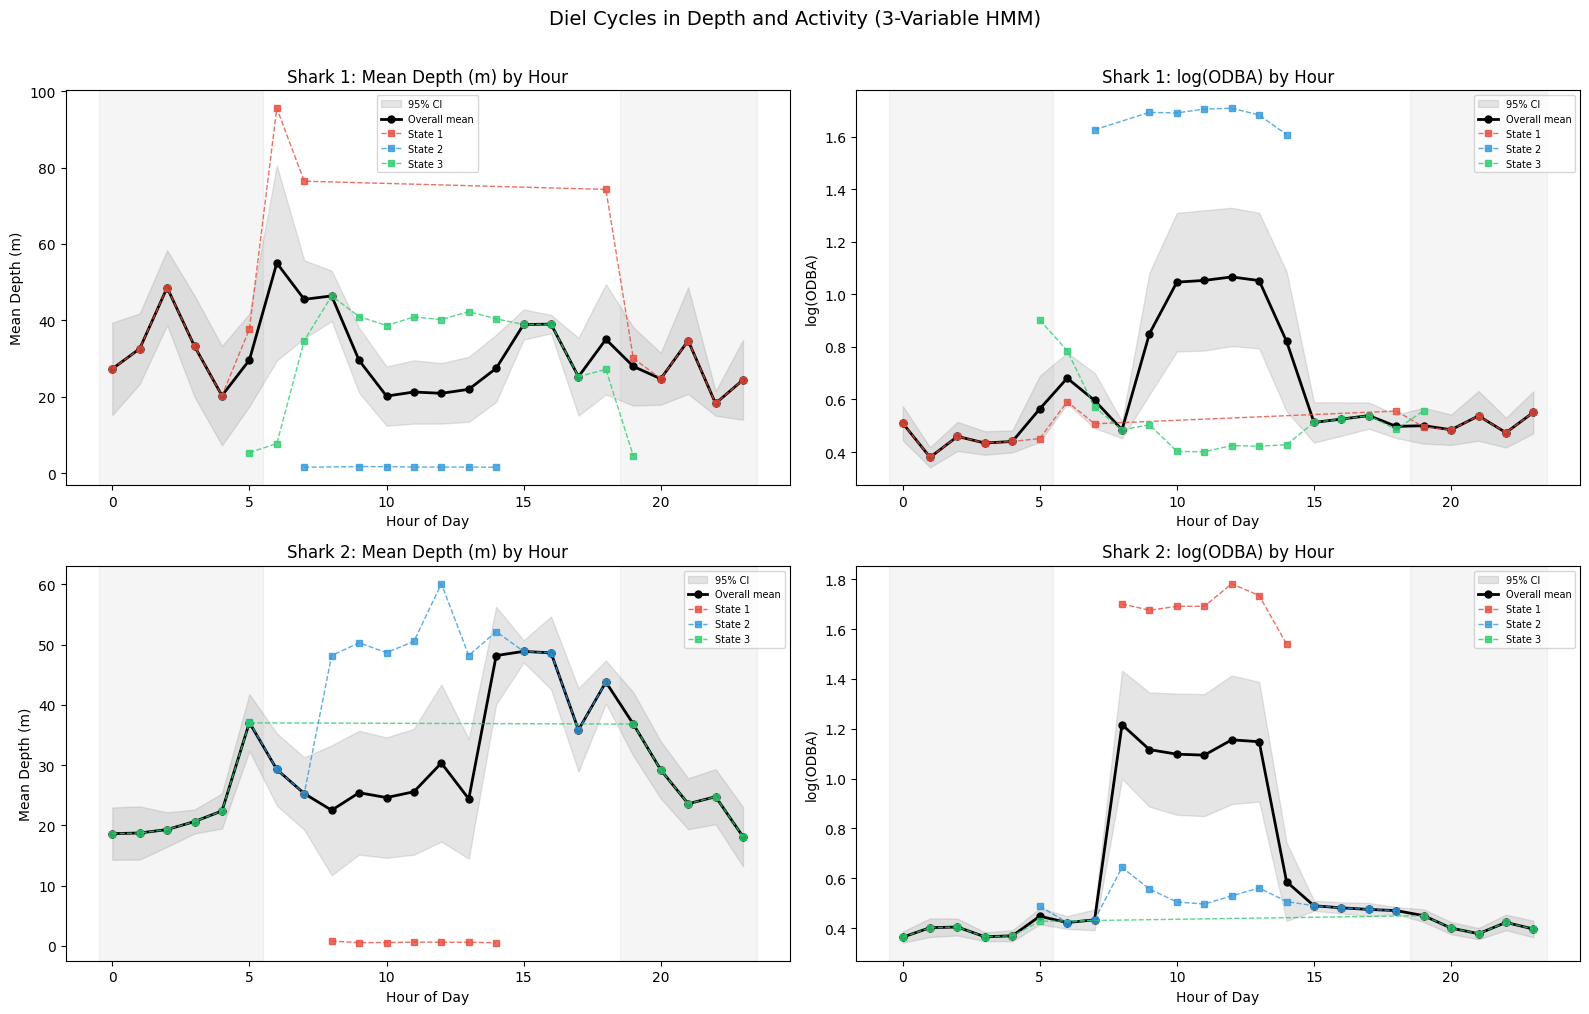

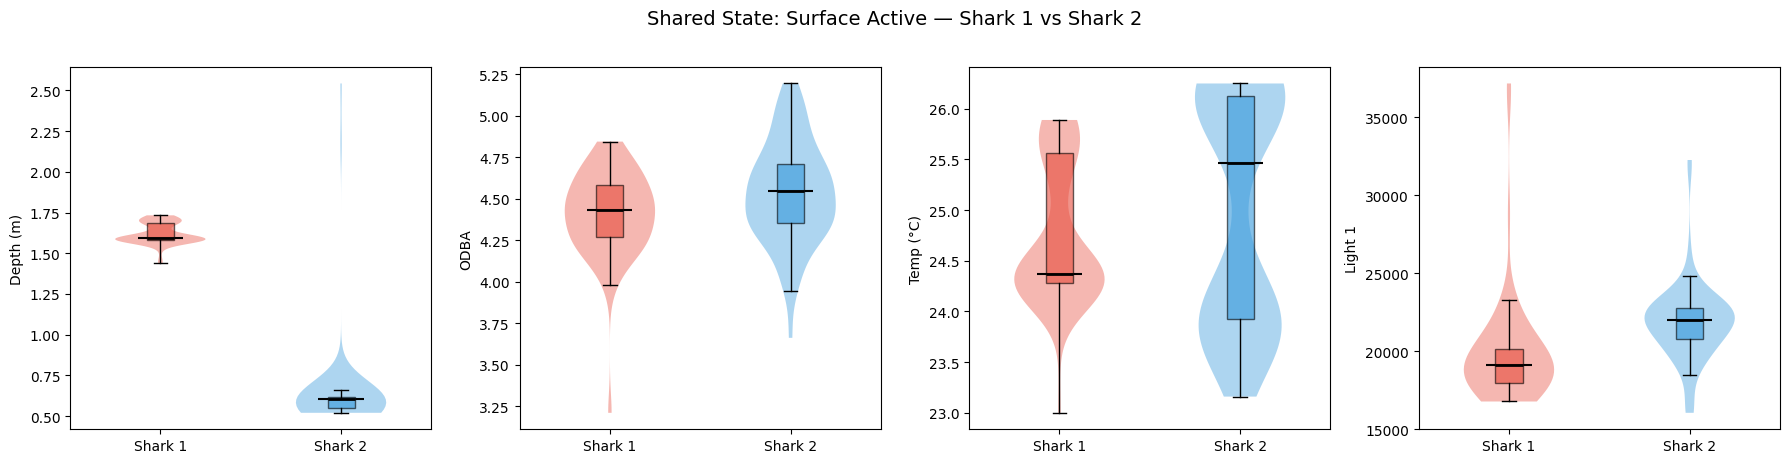

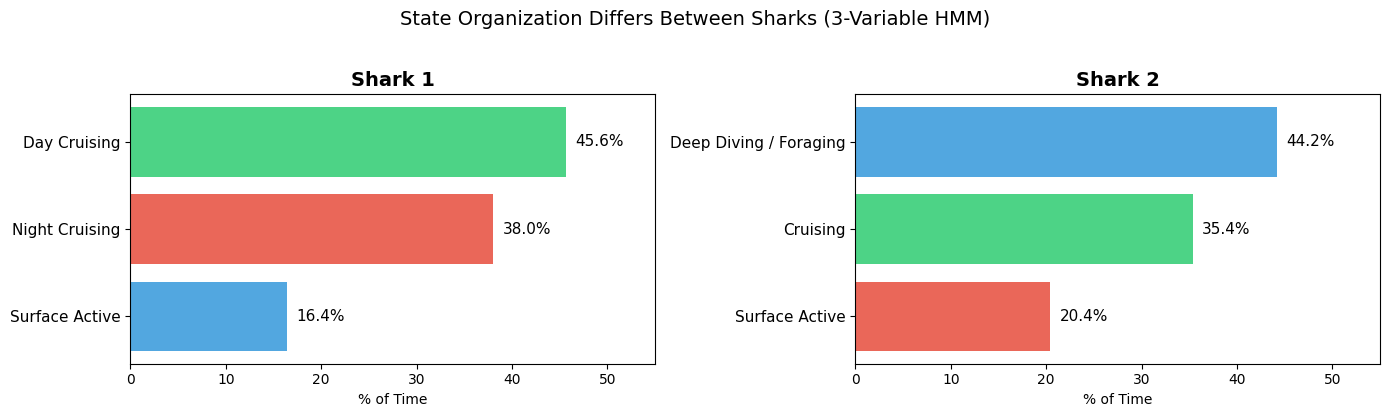

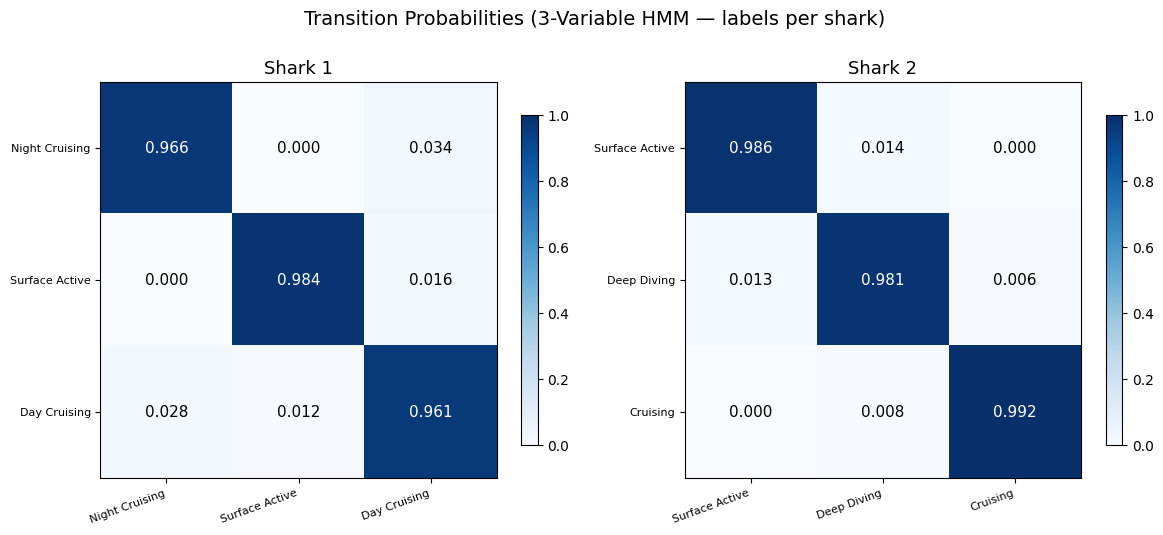

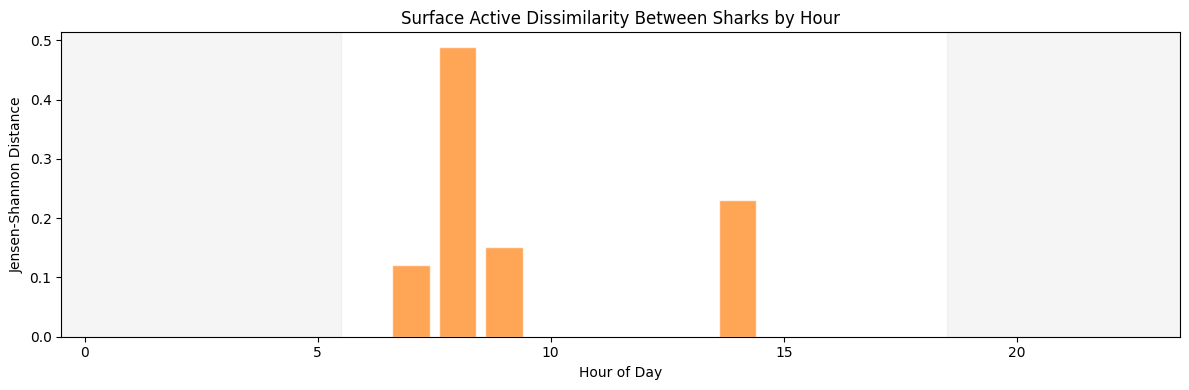

PRESENTATION STATS LOG (3-Variable HMM)

--- Shark 1 State Structure ---
  State 1: Night Cruising
    n = 144 (38.0%)
    depth = 36.0 ± 25.8 m
    ODBA  = 0.632 ± 0.200
    light = 29
    temp  = 22.7 °C
  State 2: Surface Active
    n = 62 (16.4%)
    depth = 1.6 ± 0.1 m
    ODBA  = 4.410 ± 0.261
    light = 19947
    temp  = 24.7 °C
  State 3: Day Cruising
    n = 173 (45.6%)
    depth = 36.8 ± 14.9 m
    ODBA  = 0.664 ± 0.296
    light = 26752
    temp  = 23.4 °C

--- Shark 2 State Structure ---
  State 1: Surface Active
    n = 74 (20.4%)
    depth = 0.6 ± 0.3 m
    ODBA  = 4.537 ± 0.304
    light = 21839
    temp  = 25.0 °C
  State 2: Deep Diving / Foraging
    n = 160 (44.2%)
    depth = 45.0 ± 13.6 m
    ODBA  = 0.661 ± 0.135
    light = 17986
    temp  = 23.1 °C
  State 3: Cruising
    n = 128 (35.4%)
    depth = 24.1 ± 9.5 m
    ODBA  = 0.490 ± 0.081
    light = 3
    temp  = 23.4 °C

--- Model Fit ---
  Shark 1: AIC = -32.4, BIC = 70.0
  Shark 2: AIC = -821.5, BIC = -720.4


In [44]:
# =============================================================================
# FINAL PRESENTATION FIGURES & STATS
# All outputs saved to ./pres_images/ and ./pres_log.txt
# Based on 3-variable HMM (shark1_res_3 and shark2_res_3 already overwritten)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import jensenshannon
import os, sys
from io import StringIO

# ---- Setup ----
os.makedirs("pres_images", exist_ok=True)
log = StringIO()

def log_print(*args, **kwargs):
    print(*args, **kwargs)
    print(*args, **kwargs, file=log)

colors_map = {1: "#e74c3c", 2: "#3498db", 3: "#2ecc71"}

# ---- Correct state labels for 3-variable HMM ----
# Shark 1: S1=Night Cruising (depth=36m, light=29)
#          S2=Surface Active (depth=1.6m, ODBA=4.4)
#          S3=Day Cruising (depth=36.8m, light=26752)
# Shark 2: S1=Surface Active (depth=0.6m, ODBA=4.5)
#          S2=Deep Diving (depth=45m)
#          S3=Cruising (depth=24m, light=3)

label_map_sh1 = {1: "Night Cruising", 2: "Surface Active", 3: "Day Cruising"}
label_map_sh2 = {1: "Surface Active", 2: "Deep Diving / Foraging", 3: "Cruising"}

shark1_res_3["bio_label"] = shark1_res_3["state"].map(label_map_sh1)
shark2_res_3["bio_label"] = shark2_res_3["state"].map(label_map_sh2)

# ===========================================================================
# FIG 1: Radar chart with CORRECT labels
# ===========================================================================
def normalize_col(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

radar_vars = ["mean_depth", "mean_odba", "mean_temp", "mean_light_1"]
radar_labels = ["Depth", "ODBA", "Temperature", "Light"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"polar": True})

for ax, (df, name, lmap) in zip(axes,
    [(shark1_res_3, "Shark 1", label_map_sh1),
     (shark2_res_3, "Shark 2", label_map_sh2)]):

    summary = df.groupby("state", as_index=False).agg(
        mean_depth=("mean_depth", "mean"), mean_odba=("mean_odba", "mean"),
        mean_temp=("mean_temp", "mean"), mean_light_1=("mean_light_1", "mean"),
        n=("state", "size")).copy()
    summary["prop"] = summary["n"] / summary["n"].sum()
    summary["bio_label"] = summary["state"].map(lmap)

    for col in radar_vars:
        summary[col + "_n"] = normalize_col(summary[col].values)

    angles = np.linspace(0, 2 * np.pi, len(radar_vars), endpoint=False).tolist()
    angles += angles[:1]
    colors = ["#e74c3c", "#3498db", "#2ecc71"]

    for idx, (_, r) in enumerate(summary.iterrows()):
        vals = [r[v + "_n"] for v in radar_vars] + [r[radar_vars[0] + "_n"]]
        ax.plot(angles, vals, color=colors[idx], linewidth=2,
                label=f"S{int(r['state'])}: {r['bio_label']}")
        ax.fill(angles, vals, color=colors[idx], alpha=0.15)

    ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels)
    ax.set_title(f"{name}\n3-Variable HMM Behavioral Profiles", pad=20, fontsize=13)
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)

plt.tight_layout()
plt.savefig("pres_images/fig1_radar.png", dpi=200, bbox_inches="tight")
plt.show()

# ===========================================================================
# FIG 2: Diel stacked bars (same code, but now with 3-var states)
# ===========================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (df, name) in zip(axes,
    [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]):
    ct = pd.crosstab(df["hour"], df["state"], normalize="index")
    ct.columns = [f"State {int(c)}" for c in ct.columns]
    ct.plot.bar(stacked=True, ax=ax,
                color=["#e74c3c", "#3498db", "#2ecc71"][:len(ct.columns)],
                alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_ylabel("Proportion")
    ax.set_title(f"{name}: State Proportions by Hour (3-Variable HMM)")
    ax.legend(title="Decoded State", fontsize=9)
    ax.axvspan(-0.5, 5.5, color="gray", alpha=0.1)
    ax.axvspan(18.5, 23.5, color="gray", alpha=0.1)

axes[-1].set_xlabel("Hour of Day (local time)")
plt.tight_layout()
plt.savefig("pres_images/fig2_diel_stacked.png", dpi=200, bbox_inches="tight")
plt.show()

# ===========================================================================
# FIG 3: Day vs Night state proportions
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, name, lmap) in zip(axes,
    [(shark1_res_3, "Shark 1", label_map_sh1),
     (shark2_res_3, "Shark 2", label_map_sh2)]):
    ct = pd.crosstab(df["period"], df["bio_label"], normalize="index")
    ct.plot.bar(ax=ax, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{name}: Day vs Night")
    ax.set_ylabel("Proportion")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

plt.suptitle("Day vs Night Behavioral Budgets (3-Variable HMM)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("pres_images/fig3_day_night.png", dpi=200, bbox_inches="tight")
plt.show()

# ===========================================================================
# FIG 4: Depth & ODBA diel profiles with per-state trends
# ===========================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, (var, ylabel) in enumerate([("mean_depth", "Mean Depth (m)"),
                                          ("log_odba", "log(ODBA)")]):
    for row_idx, (df, name) in enumerate([(shark1_res_3, "Shark 1"),
                                           (shark2_res_3, "Shark 2")]):
        ax = axes[row_idx, col_idx]
        hourly = df.groupby("hour")[var].agg(["mean", "std", "count"]).reset_index()
        hourly["se"] = hourly["std"] / np.sqrt(hourly["count"])
        ax.fill_between(hourly["hour"], hourly["mean"] - 1.96*hourly["se"],
                         hourly["mean"] + 1.96*hourly["se"], color="gray", alpha=0.2, label="95% CI")
        ax.plot(hourly["hour"], hourly["mean"], "o-", color="black", markersize=5, linewidth=2, label="Overall mean")
        for s in sorted(df["state"].unique()):
            sub = df[df["state"] == s]
            h = sub.groupby("hour")[var].mean().reset_index()
            ax.plot(h["hour"], h[var], "s--", color=colors_map[s], markersize=4, linewidth=1, alpha=0.8, label=f"State {s}")
        ax.axvspan(-0.5, 5.5, color="gray", alpha=0.08)
        ax.axvspan(18.5, 23.5, color="gray", alpha=0.08)
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name}: {ylabel} by Hour")
        ax.legend(fontsize=7)

plt.suptitle("Diel Cycles in Depth and Activity (3-Variable HMM)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("pres_images/fig4_diel_profiles.png", dpi=200, bbox_inches="tight")
plt.show()

# ===========================================================================
# FIG 5: How light reorganizes states — shared Surface Active comparison
# ===========================================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

# Surface Active is the only shared state
sa_sh1 = shark1_res_3[shark1_res_3["bio_label"] == "Surface Active"]
sa_sh2 = shark2_res_3[shark2_res_3["bio_label"] == "Surface Active"]

plot_vars = [("mean_depth", "Depth (m)"), ("mean_odba", "ODBA"),
             ("mean_temp", "Temp (°C)"), ("mean_light_1", "Light 1")]

for ax, (var, ylabel) in zip(axes, plot_vars):
    data = [sa_sh1[var].dropna().values, sa_sh2[var].dropna().values]
    parts = ax.violinplot(data, positions=[1, 2], showmedians=True, showextrema=False)
    for idx, body in enumerate(parts["bodies"]):
        body.set_facecolor(["#e74c3c", "#3498db"][idx])
        body.set_alpha(0.4)
    parts["cmedians"].set_color("black")
    bp = ax.boxplot(data, positions=[1, 2], widths=0.15, patch_artist=True,
                    showfliers=False, medianprops={"color": "black", "linewidth": 2})
    for idx, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(["#e74c3c", "#3498db"][idx])
        patch.set_alpha(0.6)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Shark 1", "Shark 2"])
    ax.set_ylabel(ylabel)

plt.suptitle("Shared State: Surface Active — Shark 1 vs Shark 2", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("pres_images/fig5_shared_surface_active.png", dpi=200, bbox_inches="tight")
plt.show()

# ===========================================================================
# FIG 6: Per-shark state structure summary (side by side horizontal bars)
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (df, name, lmap) in zip(axes,
    [(shark1_res_3, "Shark 1", label_map_sh1),
     (shark2_res_3, "Shark 2", label_map_sh2)]):

    props = df["bio_label"].value_counts(normalize=True).sort_values()
    bars = ax.barh(range(len(props)), props.values * 100, color=[
        colors_map[{v: k for k, v in lmap.items()}[label]] for label in props.index
    ], alpha=0.85)
    ax.set_yticks(range(len(props)))
    ax.set_yticklabels(props.index, fontsize=11)
    ax.set_xlabel("% of Time")
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlim(0, 55)
    for bar, val in zip(bars, props.values * 100):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
                va="center", fontsize=11)

plt.suptitle("State Organization Differs Between Sharks (3-Variable HMM)",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("pres_images/fig6_state_budgets.png", dpi=200, bbox_inches="tight")
plt.show()

# ===========================================================================
# FIG 7: Transition matrices (per shark, NOT aligned)
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (model, df, name, lmap) in zip(axes,
    [(model_sh1_3, shark1_res_3, "Shark 1", label_map_sh1),
     (model_sh2_3, shark2_res_3, "Shark 2", label_map_sh2)]):

    tmat = model.transmat_
    state_labels = [lmap[s+1] for s in range(3)]
    # Abbreviate labels
    short_labels = [l.replace("Cruising / Routine Swimming", "Cruising").replace("Deep Diving / Foraging", "Deep Diving")
                    for l in state_labels]

    im = ax.imshow(tmat, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(short_labels, fontsize=8, rotation=20, ha="right")
    ax.set_yticklabels(short_labels, fontsize=8)
    ax.set_title(name, fontsize=13)
    for i in range(3):
        for j in range(3):
            color = "white" if tmat[i,j] > 0.5 else "black"
            ax.text(j, i, f"{tmat[i,j]:.3f}", ha="center", va="center",
                    color=color, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Transition Probabilities (3-Variable HMM — labels per shark)",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("pres_images/fig7_transitions.png", dpi=200, bbox_inches="tight")
plt.show()

# ===========================================================================
# FIG 8: JSD by hour (how similar are the sharks hour by hour)
# ===========================================================================
# Use raw state proportions (not behavior-aligned) since structures differ
# This measures overall behavioral dissimilarity

js_by_hour = []
for h in range(24):
    sh1_h = shark1_res_3[shark1_res_3["hour"] == h]
    sh2_h = shark2_res_3[shark2_res_3["hour"] == h]
    if len(sh1_h) == 0 or len(sh2_h) == 0:
        js_by_hour.append(np.nan)
        continue
    # Compare which fraction is Surface Active (the shared state)
    p1_sa = (sh1_h["bio_label"] == "Surface Active").mean()
    p2_sa = (sh2_h["bio_label"] == "Surface Active").mean()
    # Build 2-category distributions: Surface Active vs Other
    p1 = np.array([p1_sa, 1 - p1_sa]) + 1e-10
    p2 = np.array([p2_sa, 1 - p2_sa]) + 1e-10
    p1 /= p1.sum()
    p2 /= p2.sum()
    js_by_hour.append(jensenshannon(p1, p2))

fig, ax = plt.subplots(figsize=(12, 4))
valid_hours = [h for h, v in enumerate(js_by_hour) if not np.isnan(v)]
valid_js = [js_by_hour[h] for h in valid_hours]
ax.bar(valid_hours, valid_js, color="tab:orange", alpha=0.7, edgecolor="white")
ax.axvspan(-0.5, 5.5, color="gray", alpha=0.08)
ax.axvspan(18.5, 23.5, color="gray", alpha=0.08)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Jensen-Shannon Distance")
ax.set_title("Surface Active Dissimilarity Between Sharks by Hour")
ax.set_xlim(-0.5, 23.5)
plt.tight_layout()
plt.savefig("pres_images/fig8_jsd.png", dpi=200, bbox_inches="tight")
plt.show()

# ===========================================================================
# LOG: All key statistics
# ===========================================================================
log_print("=" * 80)
log_print("PRESENTATION STATS LOG (3-Variable HMM)")
log_print("=" * 80)

# State summaries
for df, name, lmap in [(shark1_res_3, "Shark 1", label_map_sh1),
                        (shark2_res_3, "Shark 2", label_map_sh2)]:
    log_print(f"\n--- {name} State Structure ---")
    for s in sorted(df["state"].unique()):
        sub = df[df["state"] == s]
        log_print(f"  State {s}: {lmap[s]}")
        log_print(f"    n = {len(sub)} ({len(sub)/len(df):.1%})")
        log_print(f"    depth = {sub['mean_depth'].mean():.1f} ± {sub['mean_depth'].std():.1f} m")
        log_print(f"    ODBA  = {sub['mean_odba'].mean():.3f} ± {sub['mean_odba'].std():.3f}")
        log_print(f"    light = {sub['mean_light_1'].mean():.0f}")
        log_print(f"    temp  = {sub['mean_temp'].mean():.1f} °C")

# AIC/BIC
log_print(f"\n--- Model Fit ---")
log_print(f"  Shark 1: AIC = {aic_sh1_3:.1f}, BIC = {bic_sh1_3:.1f}")
log_print(f"  Shark 2: AIC = {aic_sh2_3:.1f}, BIC = {bic_sh2_3:.1f}")

# Diel stats
log_print(f"\n--- Diel: Day vs Night ---")
for df, name in [(shark1_res_3, "Shark 1"), (shark2_res_3, "Shark 2")]:
    ct = pd.crosstab(df["period"], df["state"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    log_print(f"  {name}: χ² = {chi2:.1f}, p = {p:.2e}, Cramér's V = {cramers_v:.3f}")

# Surface Active comparison
log_print(f"\n--- Shared State: Surface Active ---")
log_print(f"  Shark 1: n={len(sa_sh1)}, depth={sa_sh1['mean_depth'].mean():.1f}m, "
          f"ODBA={sa_sh1['mean_odba'].mean():.3f}, light={sa_sh1['mean_light_1'].mean():.0f}")
log_print(f"  Shark 2: n={len(sa_sh2)}, depth={sa_sh2['mean_depth'].mean():.1f}m, "
          f"ODBA={sa_sh2['mean_odba'].mean():.3f}, light={sa_sh2['mean_light_1'].mean():.0f}")

for var, label in [("mean_depth", "Depth"), ("mean_odba", "ODBA"),
                    ("mean_light_1", "Light 1")]:
    v1, v2 = sa_sh1[var].dropna(), sa_sh2[var].dropna()
    u, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    log_print(f"  {label}: U={u:.0f}, p={p:.4f} {sig}")

# State persistence
log_print(f"\n--- State Persistence (diagonal) ---")
for model, name, lmap in [(model_sh1_3, "Shark 1", label_map_sh1),
                           (model_sh2_3, "Shark 2", label_map_sh2)]:
    log_print(f"  {name}:")
    for s in range(3):
        log_print(f"    {lmap[s+1]}: {model.transmat_[s,s]:.4f}")

# Key narrative point
log_print(f"\n--- KEY FINDING ---")
log_print(f"  Light reorganizes states differently across sharks:")
log_print(f"  Shark 1: light splits Cruising into Day vs Night (no Deep Diving state)")
log_print(f"  Shark 2: light preserves Cruising / Deep Diving / Surface Active")
log_print(f"  Only Surface Active is shared and directly comparable")

# Save log
with open("pres_images/pres_log.txt", "w") as f:
    f.write(log.getvalue())

print("\n✓ All figures saved to pres_images/")
print("✓ Stats log saved to pres_images/pres_log.txt")
print(f"✓ Generated {len([f for f in os.listdir('pres_images') if f.endswith('.png')])} figures")

## Presentation fix

### 2 var

Shark 1 mapping: {1: 'Cruising / Routine Swimming', 2: 'Deep Diving / Foraging', 3: 'Surface Active'}
Shark 2 mapping: {1: 'Deep Diving / Foraging', 2: 'Surface Active', 3: 'Cruising / Routine Swimming'}


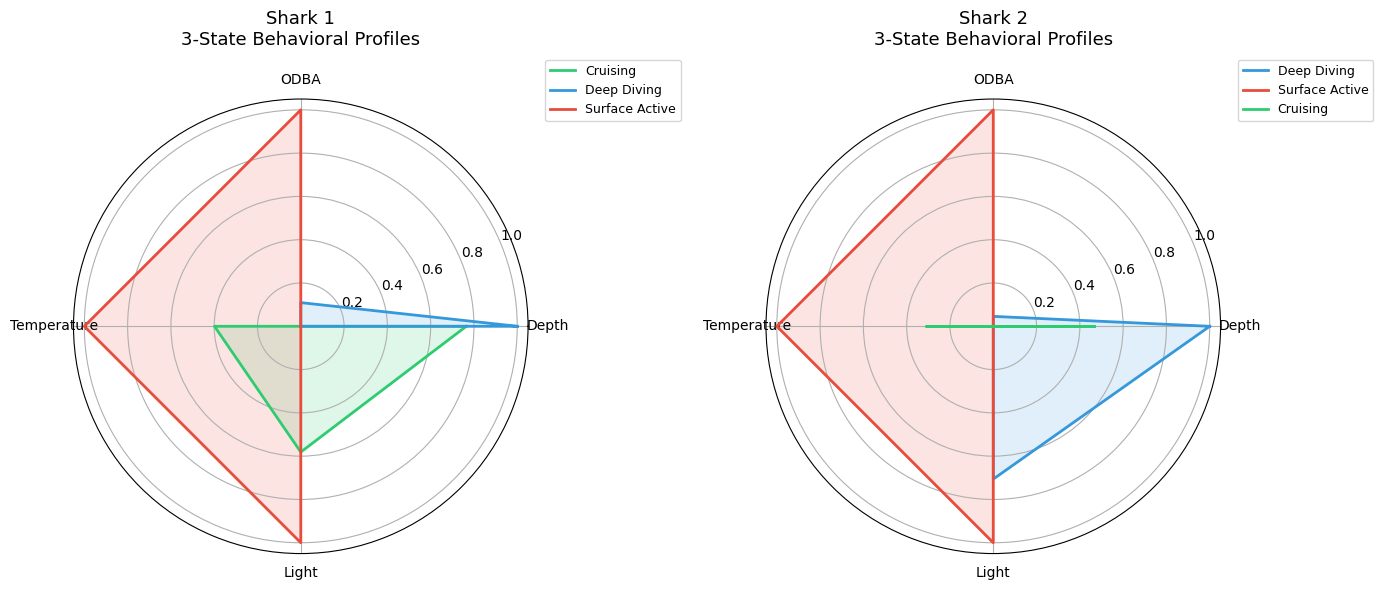

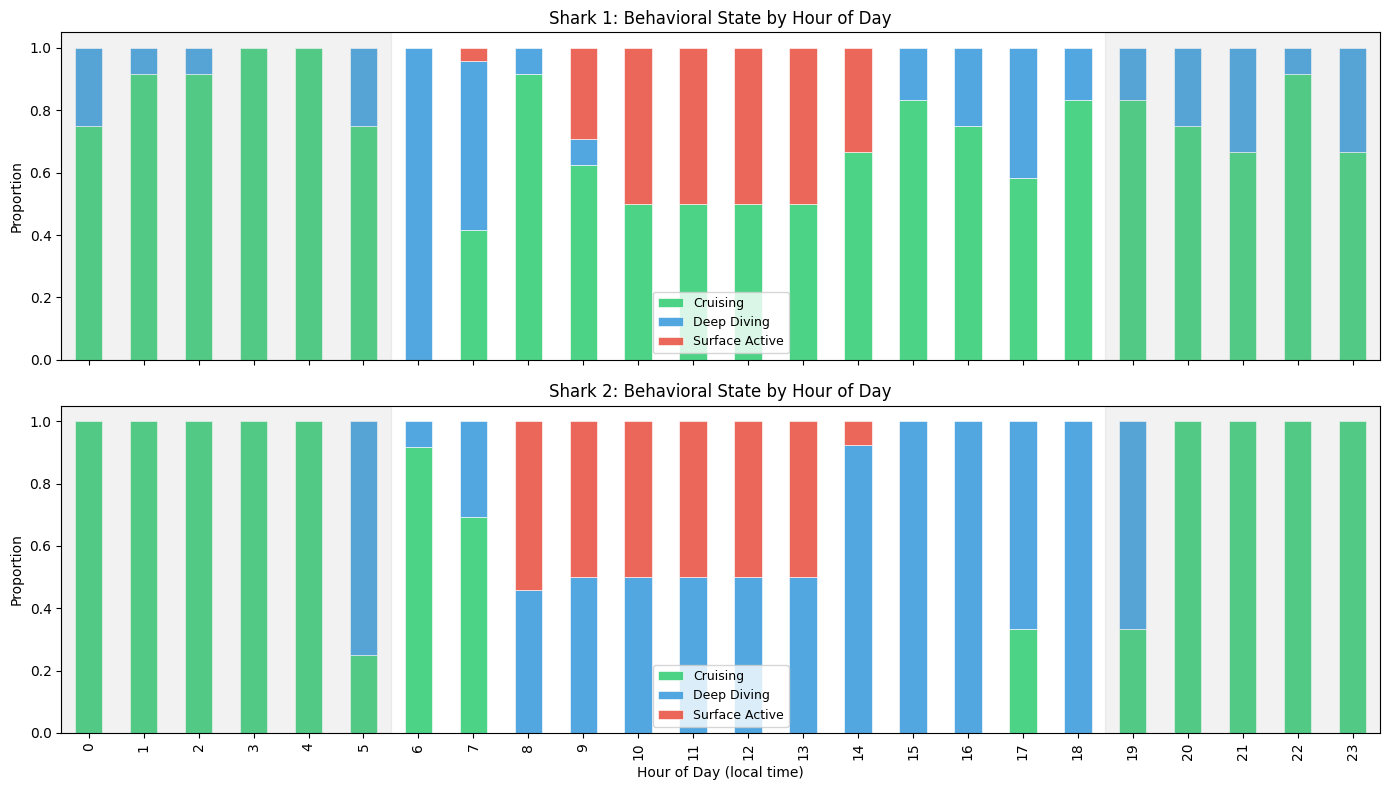

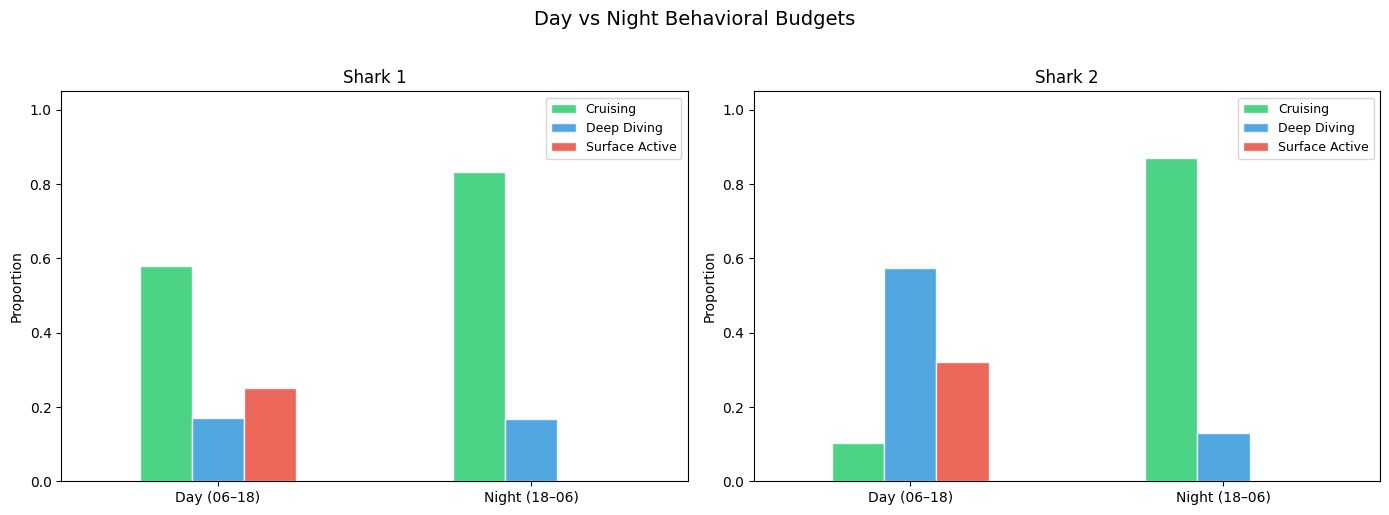

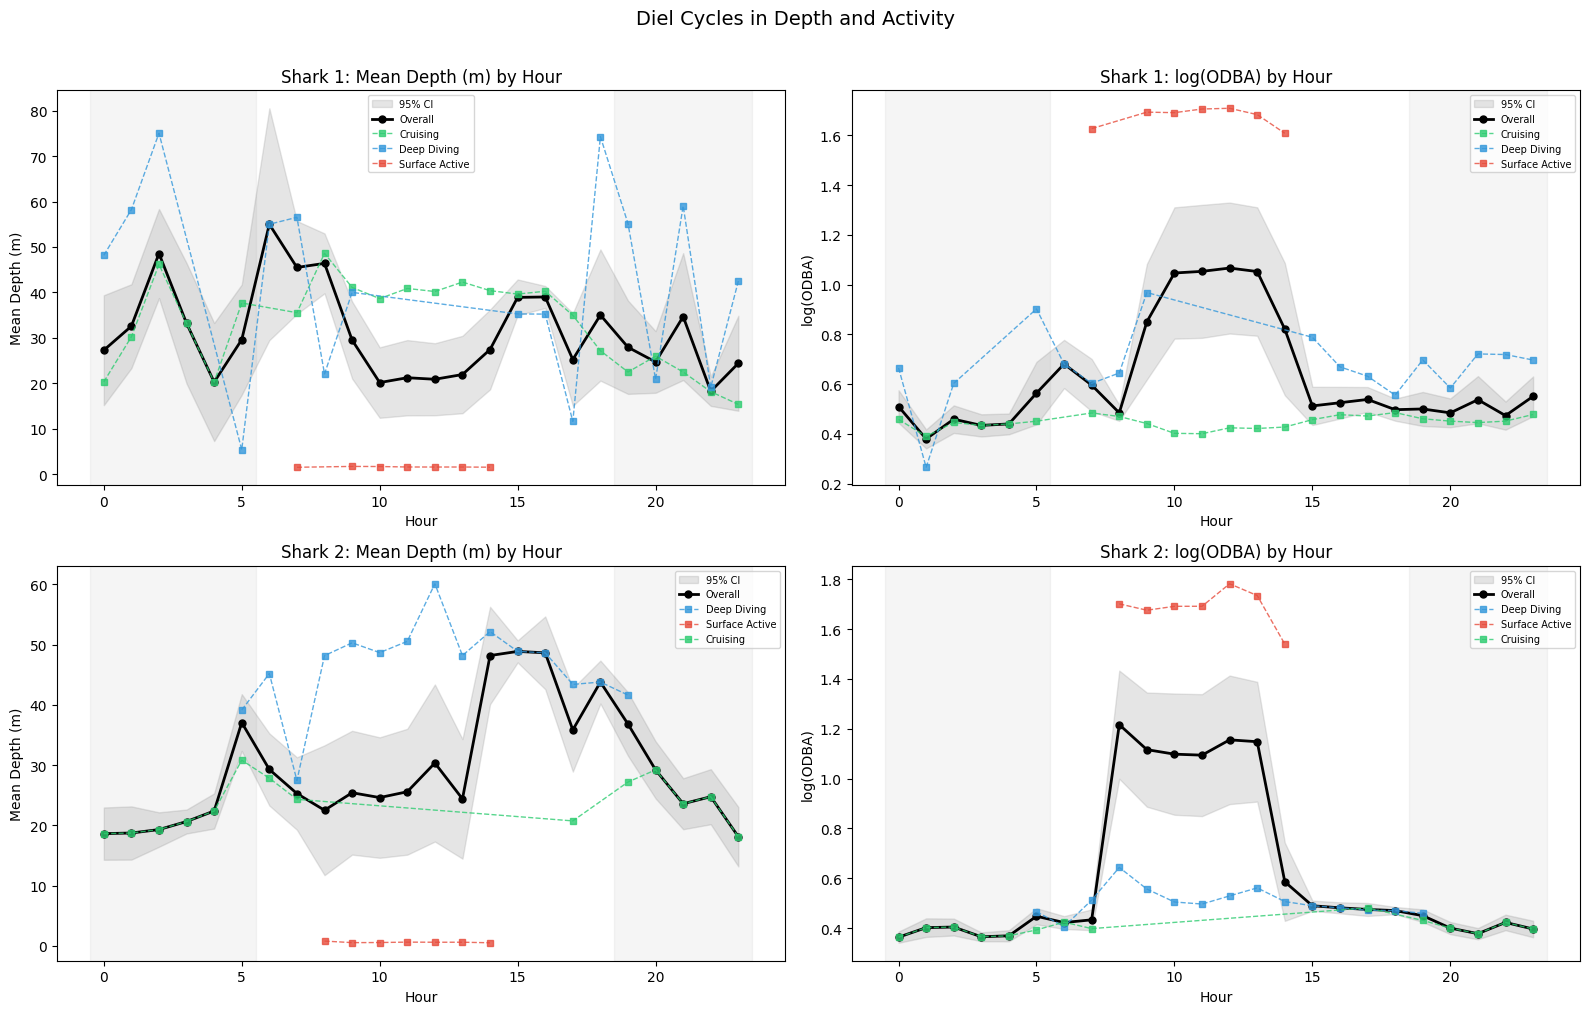

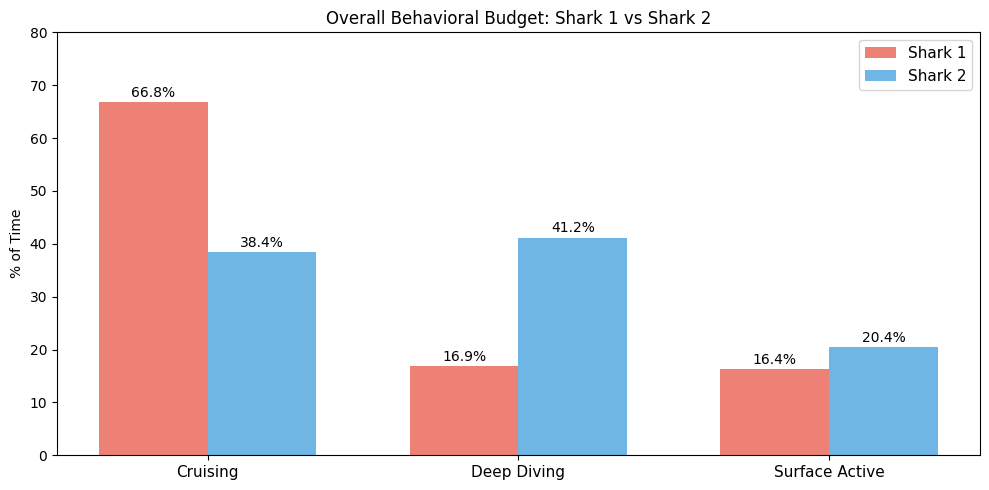

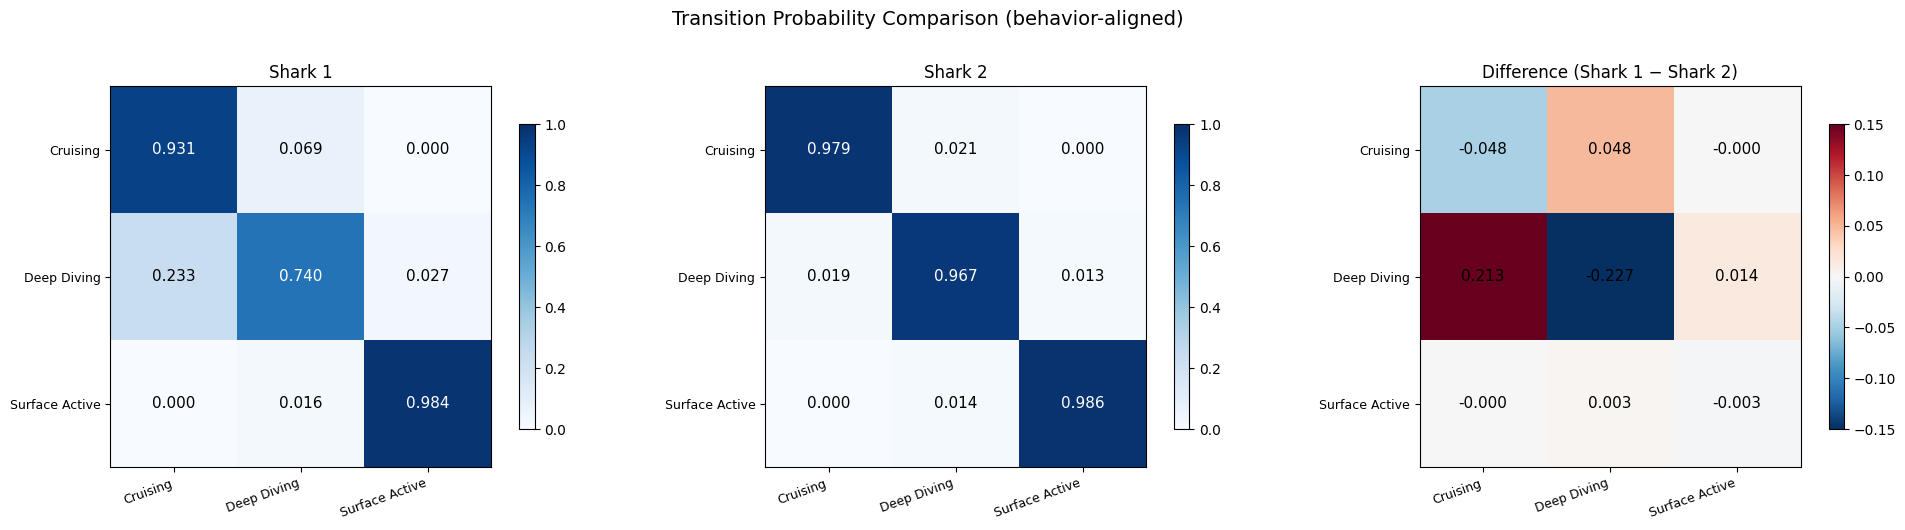

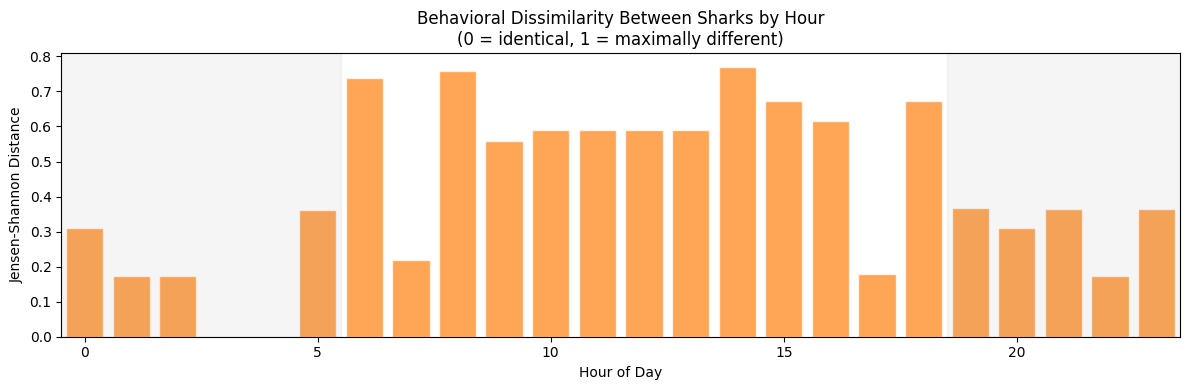

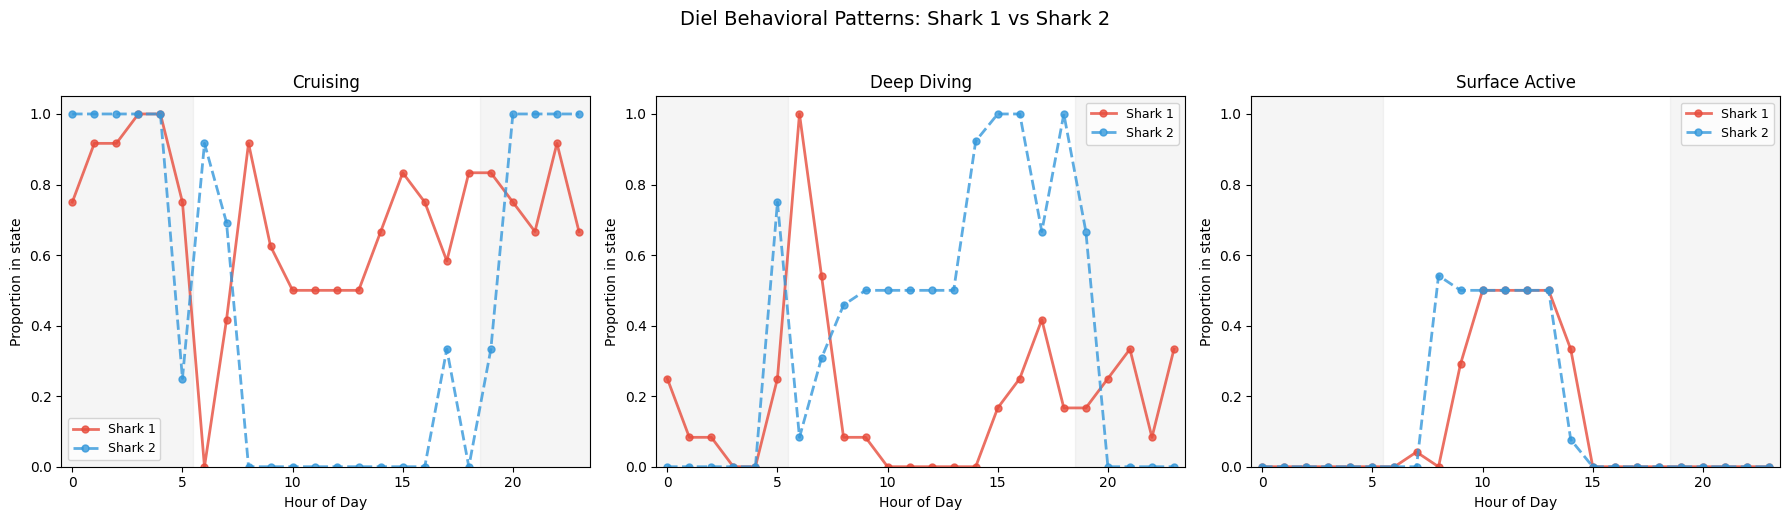


2-VARIABLE HMM PRESENTATION LOG

--- Shark 1 ---
  Cruising / Routine Swimming
    n=253 (66.8%), depth=34.4±16.4m, ODBA=0.565, temp=23.3°C, light=15780
  Deep Diving / Foraging
    n=64 (16.9%), depth=44.5±31.0m, ODBA=0.985, temp=22.3°C, light=9997
  Surface Active
    n=62 (16.4%), depth=1.6±0.1m, ODBA=4.410, temp=24.7°C, light=19947

--- Shark 2 ---
  Deep Diving / Foraging
    n=149 (41.2%), depth=47.9±11.0m, ODBA=0.674, temp=22.9°C, light=16353
  Surface Active
    n=74 (20.4%), depth=0.6±0.3m, ODBA=4.537, temp=25.0°C, light=21839
  Cruising / Routine Swimming
    n=139 (38.4%), depth=22.7±7.9m, ODBA=0.489, temp=23.6°C, light=3176

--- Diel χ² ---
  Shark 1: χ²=41.5, p=9.84e-10, V=0.331
  Shark 2: χ²=211.3, p=1.32e-46, V=0.764

--- Day vs Night ---
  Shark 1:
    Day (06–18): Cruising=58%, Deep Diving=17%, Surface Active=25%
    Night (18–06): Cruising=83%, Deep Diving=17%, Surface Active=0%
  Shark 2:
    Day (06–18): Cruising=10%, Deep Diving=57%, Surface Active=32%
    Night (

In [45]:
# =============================================================================
# 2-VARIABLE HMM: MAIN MODEL FIGURES & LOG
# Saves to ./pres_2var/
# =============================================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from scipy import stats
from scipy.spatial.distance import jensenshannon
from io import StringIO

os.makedirs("pres_2var", exist_ok=True)
log = StringIO()
def lp(*a, **kw):
    print(*a, **kw)
    print(*a, **kw, file=log)

# ---- Refit 2-var HMM (so we don't depend on overwritten variables) ----
X1_2v = shark1_win[["mean_depth_z_jit", "log_odba_z_jit"]].to_numpy()
X2_2v = shark2_win[["mean_depth_z_jit", "log_odba_z_jit"]].to_numpy()

m1, ll1 = fit_best_hmm(X1_2v, n_states=3)
m2, ll2 = fit_best_hmm(X2_2v, n_states=3)

sh1 = shark1_win.copy()
sh1["state"] = m1.predict(X1_2v) + 1
sh2 = shark2_win.copy()
sh2["state"] = m2.predict(X2_2v) + 1

# ---- Behavior labels (from 2-var state summaries) ----
def auto_label(df):
    summary = df.groupby("state").agg(
        depth=("mean_depth","mean"), odba=("mean_odba","mean")).reset_index()
    labels = {}
    for _, r in summary.iterrows():
        s = int(r["state"])
        if r["depth"] < 5 and r["odba"] > 2:
            labels[s] = "Surface Active"
        elif r["depth"] > 40:
            labels[s] = "Deep Diving / Foraging"
        else:
            labels[s] = "Cruising / Routine Swimming"
    return labels

lab1 = auto_label(sh1)
lab2 = auto_label(sh2)
sh1["bio"] = sh1["state"].map(lab1)
sh2["bio"] = sh2["state"].map(lab2)

lp("Shark 1 mapping:", lab1)
lp("Shark 2 mapping:", lab2)

# ---- Consistent colors by BEHAVIOR ----
BIO_COLORS = {
    "Surface Active": "#E74C3C",
    "Deep Diving / Foraging": "#3498DB",
    "Cruising / Routine Swimming": "#2ECC71",
}
BIO_SHORT = {
    "Surface Active": "Surface Active",
    "Deep Diving / Foraging": "Deep Diving",
    "Cruising / Routine Swimming": "Cruising",
}
BIO_ORDER = ["Cruising / Routine Swimming", "Deep Diving / Foraging", "Surface Active"]

# Helper: get color for a state number given a label map
def state_color(lmap, s):
    return BIO_COLORS[lmap[s]]

# ---- Time features ----
for df in [sh1, sh2]:
    df["hour"] = df["time_window"].dt.hour
    df["is_day"] = df["hour"].between(6, 18)
    df["period"] = df["is_day"].map({True: "Day (06–18)", False: "Night (18–06)"})

# =====================================================================
# FIG 1: Radar chart
# =====================================================================
def normalize_col(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

radar_vars = ["mean_depth", "mean_odba", "mean_temp", "mean_light_1"]
radar_labels = ["Depth", "ODBA", "Temperature", "Light"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"polar": True})
for ax, (df, name, lmap) in zip(axes,
    [(sh1, "Shark 1", lab1), (sh2, "Shark 2", lab2)]):
    summary = df.groupby("state", as_index=False).agg(
        mean_depth=("mean_depth","mean"), mean_odba=("mean_odba","mean"),
        mean_temp=("mean_temp","mean"), mean_light_1=("mean_light_1","mean"),
        n=("state","size"))
    summary["bio"] = summary["state"].map(lmap)
    for col in radar_vars:
        summary[col+"_n"] = normalize_col(summary[col].values)
    angles = np.linspace(0, 2*np.pi, len(radar_vars), endpoint=False).tolist()
    angles += angles[:1]
    for _, r in summary.iterrows():
        bio = r["bio"]
        vals = [r[v+"_n"] for v in radar_vars] + [r[radar_vars[0]+"_n"]]
        ax.plot(angles, vals, color=BIO_COLORS[bio], linewidth=2,
                label=BIO_SHORT[bio])
        ax.fill(angles, vals, color=BIO_COLORS[bio], alpha=0.15)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels)
    ax.set_title(f"{name}\n3-State Behavioral Profiles", pad=20, fontsize=13)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig("pres_2var/fig1_radar.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 2: Diel stacked bar by behavior name
# =====================================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, (df, name) in zip(axes, [(sh1, "Shark 1"), (sh2, "Shark 2")]):
    ct = pd.crosstab(df["hour"], df["bio"], normalize="index")[
        [b for b in BIO_ORDER if b in df["bio"].unique()]]
    ct.rename(columns=BIO_SHORT, inplace=True)
    ct.plot.bar(stacked=True, ax=ax,
        color=[BIO_COLORS[b] for b in BIO_ORDER if b in df["bio"].unique()],
        alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_ylabel("Proportion")
    ax.set_title(f"{name}: Behavioral State by Hour of Day")
    ax.legend(fontsize=9)
    ax.axvspan(-0.5, 5.5, color="gray", alpha=0.1)
    ax.axvspan(18.5, 23.5, color="gray", alpha=0.1)
axes[-1].set_xlabel("Hour of Day (local time)")
plt.tight_layout()
plt.savefig("pres_2var/fig2_diel_stacked.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 3: Day vs Night proportions
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, name) in zip(axes, [(sh1, "Shark 1"), (sh2, "Shark 2")]):
    ct = pd.crosstab(df["period"], df["bio"], normalize="index")
    cols = [b for b in BIO_ORDER if b in ct.columns]
    ct = ct[cols].rename(columns=BIO_SHORT)
    ct.plot.bar(ax=ax, color=[BIO_COLORS[b] for b in cols],
                alpha=0.85, edgecolor="white")
    ax.set_title(name)
    ax.set_ylabel("Proportion")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
plt.suptitle("Day vs Night Behavioral Budgets", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("pres_2var/fig3_day_night.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 4: Depth & ODBA diel profiles
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ci, (var, ylabel) in enumerate([("mean_depth","Mean Depth (m)"),("log_odba","log(ODBA)")]):
    for ri, (df, name, lmap) in enumerate([(sh1,"Shark 1",lab1),(sh2,"Shark 2",lab2)]):
        ax = axes[ri, ci]
        h_all = df.groupby("hour")[var].agg(["mean","std","count"]).reset_index()
        h_all["se"] = h_all["std"]/np.sqrt(h_all["count"])
        ax.fill_between(h_all["hour"], h_all["mean"]-1.96*h_all["se"],
                         h_all["mean"]+1.96*h_all["se"], color="gray", alpha=0.2, label="95% CI")
        ax.plot(h_all["hour"], h_all["mean"], "o-", color="black", ms=5, lw=2, label="Overall")
        for s in sorted(df["state"].unique()):
            bio = lmap[s]
            sub_h = df[df["state"]==s].groupby("hour")[var].mean().reset_index()
            ax.plot(sub_h["hour"], sub_h[var], "s--", color=BIO_COLORS[bio],
                    ms=4, lw=1, alpha=0.8, label=BIO_SHORT[bio])
        ax.axvspan(-0.5,5.5,color="gray",alpha=0.08)
        ax.axvspan(18.5,23.5,color="gray",alpha=0.08)
        ax.set_xlabel("Hour"); ax.set_ylabel(ylabel)
        ax.set_title(f"{name}: {ylabel} by Hour"); ax.legend(fontsize=7)
plt.suptitle("Diel Cycles in Depth and Activity", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("pres_2var/fig4_diel_profiles.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 5: Cross-shark behavioral budget
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(BIO_ORDER))
w = 0.35
p1 = [(sh1["bio"]==b).mean()*100 for b in BIO_ORDER]
p2 = [(sh2["bio"]==b).mean()*100 for b in BIO_ORDER]
bars1 = ax.bar(x-w/2, p1, w, label="Shark 1", color="#e74c3c", alpha=0.7)
bars2 = ax.bar(x+w/2, p2, w, label="Shark 2", color="#3498db", alpha=0.7)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.1f}%", ha="center", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([BIO_SHORT[b] for b in BIO_ORDER], fontsize=11)
ax.set_ylabel("% of Time")
ax.set_title("Overall Behavioral Budget: Shark 1 vs Shark 2")
ax.legend(fontsize=11); ax.set_ylim(0,80)
plt.tight_layout()
plt.savefig("pres_2var/fig5_budgets.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 6: Behavior-aligned transition matrices
# =====================================================================
# Reorder both matrices to [Cruising, Deep Diving, Surface Active]
def reorder_transmat(model, lmap):
    order = [None]*3
    for s, bio in lmap.items():
        idx = BIO_ORDER.index(bio)
        order[idx] = s - 1  # 0-indexed
    return model.transmat_[np.ix_(order, order)]

t1 = reorder_transmat(m1, lab1)
t2 = reorder_transmat(m2, lab2)
diff = t1 - t2
short_labels = [BIO_SHORT[b] for b in BIO_ORDER]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, tmat, title in zip(axes, [t1, t2, diff],
    ["Shark 1", "Shark 2", "Difference (Shark 1 − Shark 2)"]):
    if "Diff" in title:
        vmin, vmax, cmap = -0.15, 0.15, "RdBu_r"
    else:
        vmin, vmax, cmap = 0, 1, "Blues"
    im = ax.imshow(tmat, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(short_labels, fontsize=9, rotation=20, ha="right")
    ax.set_yticklabels(short_labels, fontsize=9)
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            c = "white" if abs(tmat[i,j]) > 0.5 else "black"
            ax.text(j, i, f"{tmat[i,j]:.3f}", ha="center", va="center", color=c, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Transition Probability Comparison (behavior-aligned)", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("pres_2var/fig6_transitions.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 7: JSD by hour
# =====================================================================
js_hours = []
for h in range(24):
    s1h = sh1[sh1["hour"]==h]; s2h = sh2[sh2["hour"]==h]
    if len(s1h)==0 or len(s2h)==0:
        js_hours.append(np.nan); continue
    p1 = np.array([(s1h["bio"]==b).mean() for b in BIO_ORDER]) + 1e-10
    p2 = np.array([(s2h["bio"]==b).mean() for b in BIO_ORDER]) + 1e-10
    js_hours.append(jensenshannon(p1/p1.sum(), p2/p2.sum()))

fig, ax = plt.subplots(figsize=(12, 4))
vh = [h for h,v in enumerate(js_hours) if not np.isnan(v)]
vj = [js_hours[h] for h in vh]
ax.bar(vh, vj, color="tab:orange", alpha=0.7, edgecolor="white")
ax.axvspan(-0.5,5.5,color="gray",alpha=0.08)
ax.axvspan(18.5,23.5,color="gray",alpha=0.08)
ax.set_xlabel("Hour of Day"); ax.set_ylabel("Jensen-Shannon Distance")
ax.set_title("Behavioral Dissimilarity Between Sharks by Hour\n(0 = identical, 1 = maximally different)")
ax.set_xlim(-0.5, 23.5)
plt.tight_layout()
plt.savefig("pres_2var/fig7_jsd.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 8: Diel behavior comparison lines (Shark 1 vs Shark 2)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, bio in zip(axes, BIO_ORDER):
    for df, name, ls in [(sh1,"Shark 1","-"),(sh2,"Shark 2","--")]:
        props = [df[df["hour"]==h]["bio"].eq(bio).mean() if len(df[df["hour"]==h])>0
                 else np.nan for h in range(24)]
        color = "#e74c3c" if name=="Shark 1" else "#3498db"
        ax.plot(range(24), props, f"o{ls}", color=color, ms=5, lw=2, label=name, alpha=0.8)
    ax.axvspan(-0.5,5.5,color="gray",alpha=0.08)
    ax.axvspan(18.5,23.5,color="gray",alpha=0.08)
    ax.set_xlabel("Hour of Day"); ax.set_ylabel("Proportion in state")
    ax.set_title(BIO_SHORT[bio]); ax.set_xlim(-0.5,23.5); ax.set_ylim(0,1.05)
    ax.legend(fontsize=9)
plt.suptitle("Diel Behavioral Patterns: Shark 1 vs Shark 2", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("pres_2var/fig8_diel_compare.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# LOG
# =====================================================================
lp("\n" + "="*80)
lp("2-VARIABLE HMM PRESENTATION LOG")
lp("="*80)

for df, name, lmap in [(sh1,"Shark 1",lab1),(sh2,"Shark 2",lab2)]:
    lp(f"\n--- {name} ---")
    for s in sorted(df["state"].unique()):
        sub = df[df["state"]==s]
        lp(f"  {lmap[s]}")
        lp(f"    n={len(sub)} ({len(sub)/len(df):.1%}), depth={sub['mean_depth'].mean():.1f}±{sub['mean_depth'].std():.1f}m, "
           f"ODBA={sub['mean_odba'].mean():.3f}, temp={sub['mean_temp'].mean():.1f}°C, light={sub['mean_light_1'].mean():.0f}")

lp(f"\n--- Diel χ² ---")
for df, name in [(sh1,"Shark 1"),(sh2,"Shark 2")]:
    ct = pd.crosstab(df["period"], df["state"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2/(ct.values.sum()*(min(ct.shape)-1)))
    lp(f"  {name}: χ²={chi2:.1f}, p={p:.2e}, V={v:.3f}")

lp(f"\n--- Day vs Night ---")
for df, name in [(sh1,"Shark 1"),(sh2,"Shark 2")]:
    lp(f"  {name}:")
    for period in ["Day (06–18)","Night (18–06)"]:
        sub = df[df["period"]==period]
        props = sub["bio"].value_counts(normalize=True)
        lp(f"    {period}: " + ", ".join(f"{BIO_SHORT[b]}={props.get(b,0):.0%}" for b in BIO_ORDER))

lp(f"\n--- Cross-shark Mann-Whitney (same behavior) ---")
for bio in BIO_ORDER:
    lp(f"  {BIO_SHORT[bio]}:")
    s1b = sh1[sh1["bio"]==bio]; s2b = sh2[sh2["bio"]==bio]
    for var, label in [("mean_depth","Depth"),("mean_odba","ODBA"),("mean_temp","Temp"),("mean_light_1","Light")]:
        v1, v2 = s1b[var].dropna(), s2b[var].dropna()
        if len(v1)>=3 and len(v2)>=3:
            u, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
            sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
            lp(f"    {label}: Sh1={v1.mean():.1f}, Sh2={v2.mean():.1f}, p={p:.4f} {sig}")

lp(f"\n--- Transition persistence ---")
for tmat, name in [(t1,"Shark 1"),(t2,"Shark 2")]:
    lp(f"  {name}: " + ", ".join(f"{BIO_SHORT[BIO_ORDER[i]]}={tmat[i,i]:.4f}" for i in range(3)))

lp(f"\n--- JSD ---")
lp(f"  Mean={np.nanmean(vj):.3f}, Most similar={vh[np.argmin(vj)]:02d}:00 ({min(vj):.3f}), "
   f"Most different={vh[np.argmax(vj)]:02d}:00 ({max(vj):.3f})")

with open("pres_2var/log.txt","w") as f:
    f.write(log.getvalue())
print(f"\n✓ Saved {len([f for f in os.listdir('pres_2var') if f.endswith('.png')])} figures + log to pres_2var/")

### 3 var

Shark 1 (3-var): {1: 'Night Cruising', 2: 'Surface Active', 3: 'Day Cruising'}
Shark 2 (3-var): {1: 'Surface Active', 2: 'Deep Diving / Foraging', 3: 'Night Cruising'}

--- AIC/BIC ---
  Shark 1: 2-var AIC=258.0 → 3-var AIC=-32.4  (ΔAIC=-290.4)
  Shark 2: 2-var AIC=-425.0 → 3-var AIC=-821.5  (ΔAIC=-396.5)


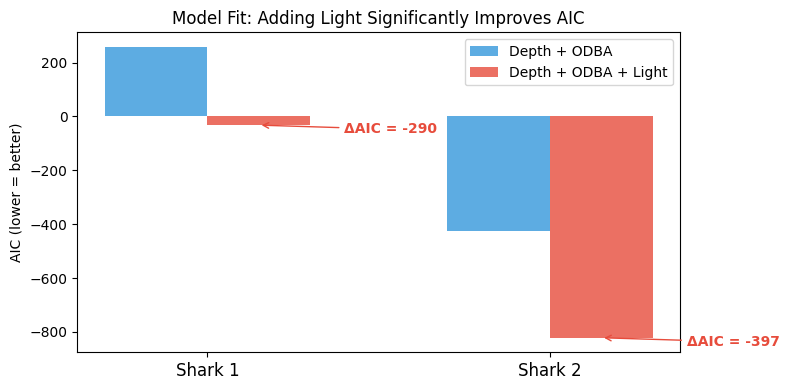

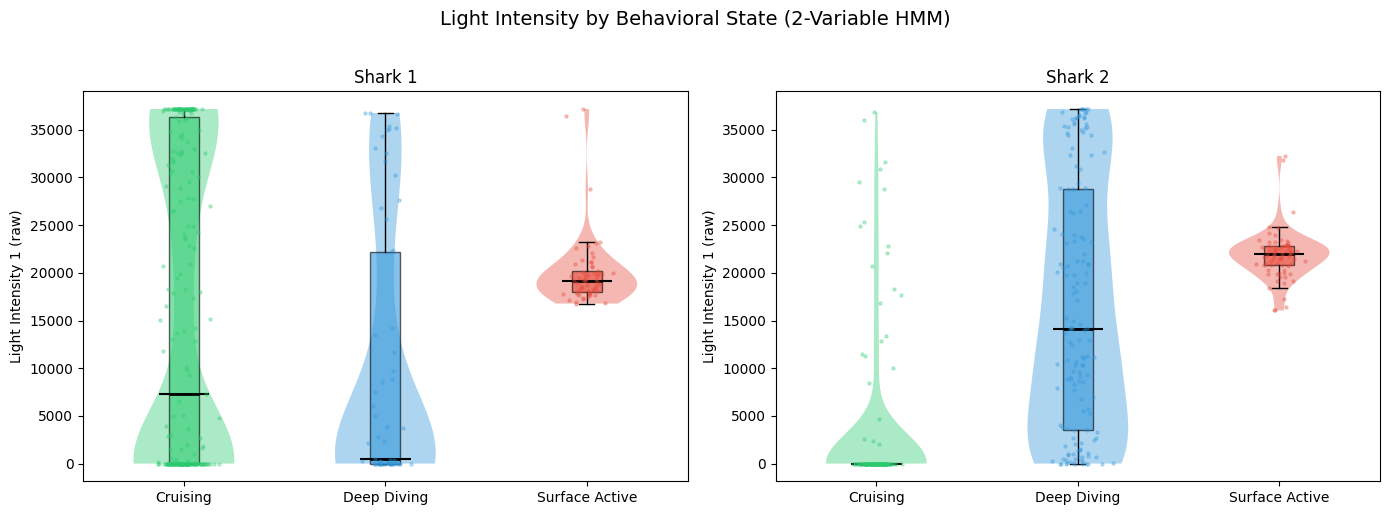

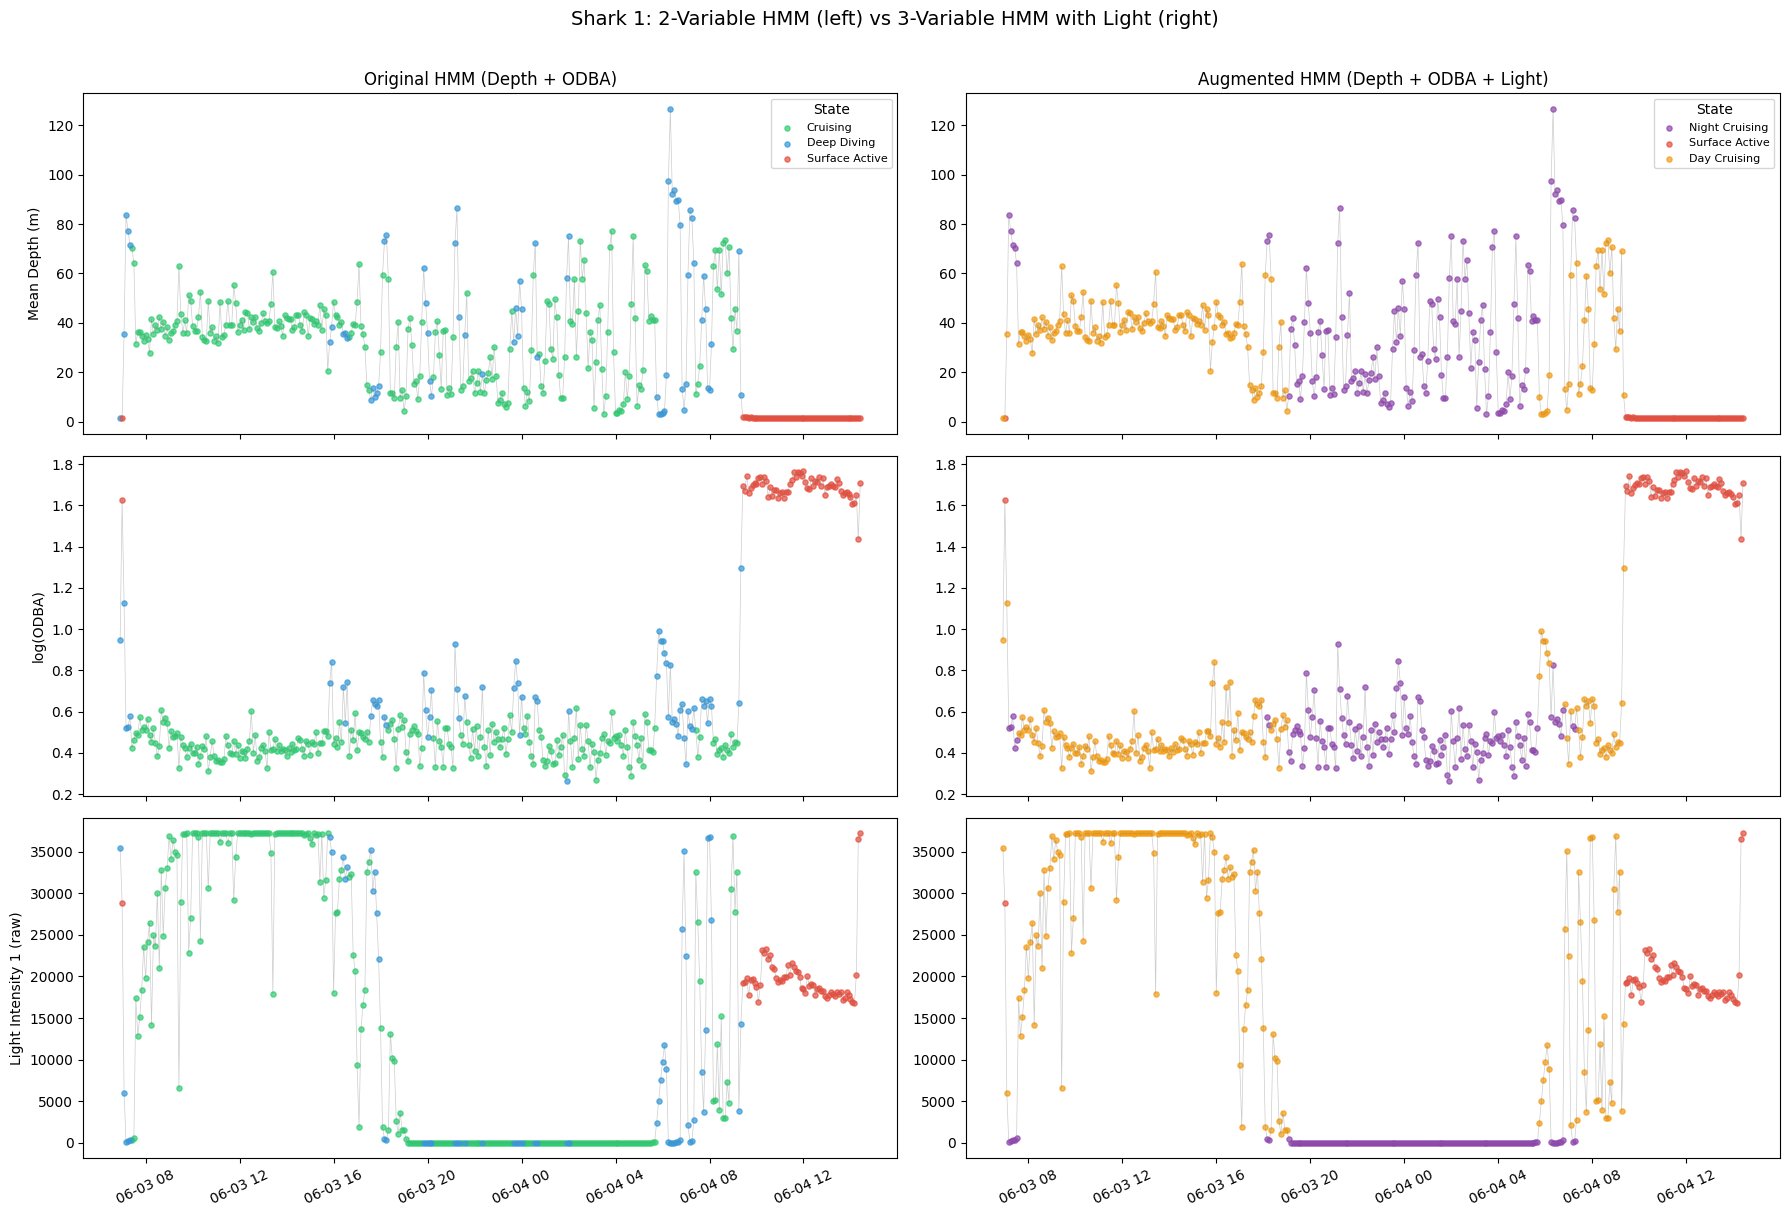

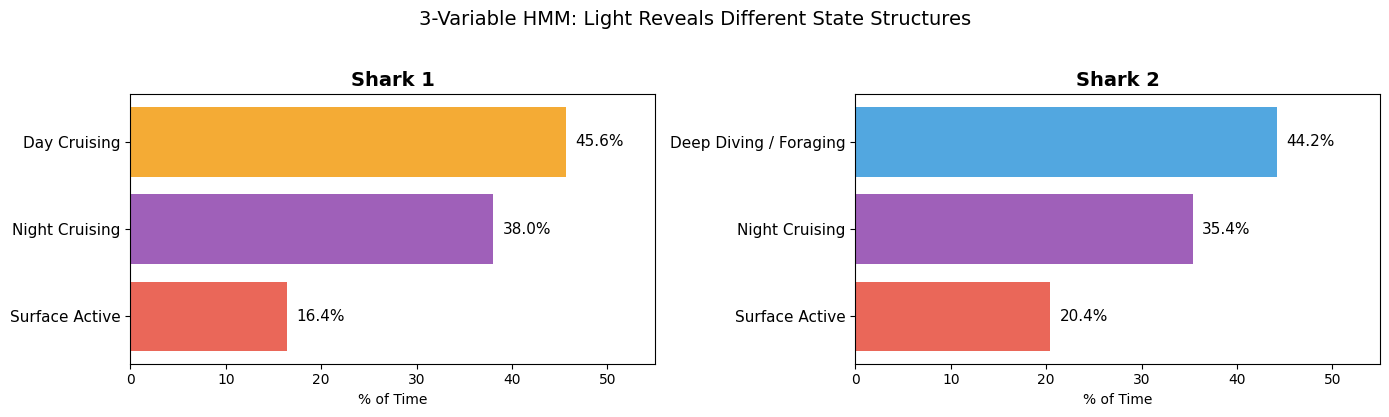


3-VARIABLE HMM LIGHT ANALYSIS LOG

--- AIC improvement ---
  Shark 1: ΔAIC = -290.4 (strong improvement)
  Shark 2: ΔAIC = -396.5 (strong improvement)

--- 3-var state structures ---
  Shark 1:
    Night Cruising: n=144 (38.0%), depth=36.0m, ODBA=0.632, light=29
    Surface Active: n=62 (16.4%), depth=1.6m, ODBA=4.410, light=19947
    Day Cruising: n=173 (45.6%), depth=36.8m, ODBA=0.664, light=26752
  Shark 2:
    Surface Active: n=74 (20.4%), depth=0.6m, ODBA=4.537, light=21839
    Deep Diving / Foraging: n=160 (44.2%), depth=45.0m, ODBA=0.661, light=17986
    Night Cruising: n=128 (35.4%), depth=24.1m, ODBA=0.490, light=3

--- KEY FINDING ---
  Adding light significantly improves model fit for BOTH sharks
  But it reorganizes states DIFFERENTLY:
  Shark 1: Cruising splits into Day Cruising vs Night Cruising (no Deep Diving)
  Shark 2: Preserves Cruising / Deep Diving / Surface Active structure
  → Light captures diel signal; its effect is individual-specific

✓ Saved 4 figures + log

In [46]:
# =============================================================================
# 3-VARIABLE HMM: LIGHT ANALYSIS FIGURES & LOG
# Saves to ./pres_3var/
# =============================================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from scipy import stats
from hmmlearn.hmm import GaussianHMM
from io import StringIO

os.makedirs("pres_3var", exist_ok=True)
log3 = StringIO()
def lp3(*a, **kw):
    print(*a, **kw)
    print(*a, **kw, file=log3)

# ---- Standardize light & fit 3-var HMM ----
for win_df in [shark1_win, shark2_win]:
    mu = win_df["mean_light_1"].mean()
    sd = win_df["mean_light_1"].std(ddof=0)
    win_df["mean_light_1_z"] = (win_df["mean_light_1"] - mu) / sd
    rng = np.random.default_rng(490)
    win_df["mean_light_1_z_jit"] = win_df["mean_light_1_z"] + rng.normal(0, 1e-6, len(win_df))

X1_3v = shark1_win[["mean_depth_z_jit","log_odba_z_jit","mean_light_1_z_jit"]].to_numpy()
X2_3v = shark2_win[["mean_depth_z_jit","log_odba_z_jit","mean_light_1_z_jit"]].to_numpy()
m1_3v, ll1_3v = fit_best_hmm(X1_3v, n_states=3)
m2_3v, ll2_3v = fit_best_hmm(X2_3v, n_states=3)

sh1_3v = shark1_win.copy(); sh1_3v["state"] = m1_3v.predict(X1_3v) + 1
sh2_3v = shark2_win.copy(); sh2_3v["state"] = m2_3v.predict(X2_3v) + 1

# Also refit 2-var for comparison
X1_2v = shark1_win[["mean_depth_z_jit","log_odba_z_jit"]].to_numpy()
X2_2v = shark2_win[["mean_depth_z_jit","log_odba_z_jit"]].to_numpy()
m1_2v, ll1_2v = fit_best_hmm(X1_2v, n_states=3)
m2_2v, ll2_2v = fit_best_hmm(X2_2v, n_states=3)

sh1_2v = shark1_win.copy(); sh1_2v["state"] = m1_2v.predict(X1_2v) + 1
sh2_2v = shark2_win.copy(); sh2_2v["state"] = m2_2v.predict(X2_2v) + 1

# ---- Labels for 3-var states ----
def auto_label_3v(df):
    summary = df.groupby("state").agg(depth=("mean_depth","mean"),
        odba=("mean_odba","mean"), light=("mean_light_1","mean")).reset_index()
    labels = {}
    for _, r in summary.iterrows():
        s = int(r["state"])
        if r["depth"] < 5 and r["odba"] > 2:
            labels[s] = "Surface Active"
        elif r["depth"] > 40:
            labels[s] = "Deep Diving / Foraging"
        elif r["light"] < 100:
            labels[s] = "Night Cruising"
        elif r["light"] > 10000 and r["depth"] > 20:
            labels[s] = "Day Cruising"
        else:
            labels[s] = "Cruising / Routine Swimming"
    return labels

lab1_3v = auto_label_3v(sh1_3v)
lab2_3v = auto_label_3v(sh2_3v)

lp3(f"Shark 1 (3-var): {lab1_3v}")
lp3(f"Shark 2 (3-var): {lab2_3v}")

COLORS_3V = {
    "Surface Active": "#E74C3C",
    "Deep Diving / Foraging": "#3498DB",
    "Cruising / Routine Swimming": "#2ECC71",
    "Night Cruising": "#8E44AD",
    "Day Cruising": "#F39C12",
}

# =====================================================================
# FIG 1: AIC/BIC comparison (2-var vs 3-var)
# =====================================================================
def aic_bic(ll, n_s, n_f, n_o):
    n_p = (n_s-1) + n_s*(n_s-1) + n_s*n_f + n_s*n_f
    return -2*ll + 2*n_p, -2*ll + np.log(n_o)*n_p

a1_2, b1_2 = aic_bic(ll1_2v, 3, 2, len(X1_2v))
a1_3, b1_3 = aic_bic(ll1_3v, 3, 3, len(X1_3v))
a2_2, b2_2 = aic_bic(ll2_2v, 3, 2, len(X2_2v))
a2_3, b2_3 = aic_bic(ll2_3v, 3, 3, len(X2_3v))

lp3(f"\n--- AIC/BIC ---")
lp3(f"  Shark 1: 2-var AIC={a1_2:.1f} → 3-var AIC={a1_3:.1f}  (ΔAIC={a1_3-a1_2:+.1f})")
lp3(f"  Shark 2: 2-var AIC={a2_2:.1f} → 3-var AIC={a2_3:.1f}  (ΔAIC={a2_3-a2_2:+.1f})")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
w = 0.3
ax.bar(x-w/2, [a1_2, a2_2], w, label="Depth + ODBA", color="#3498db", alpha=0.8)
ax.bar(x+w/2, [a1_3, a2_3], w, label="Depth + ODBA + Light", color="#e74c3c", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(["Shark 1","Shark 2"], fontsize=12)
ax.set_ylabel("AIC (lower = better)"); ax.legend(fontsize=10)
ax.set_title("Model Fit: Adding Light Significantly Improves AIC")
for i, (v2, v3) in enumerate(zip([a1_2, a2_2], [a1_3, a2_3])):
    ax.annotate(f"ΔAIC = {v3-v2:+.0f}", xy=(i+w/2, v3), xytext=(i+0.4, v3-30),
                fontsize=10, color="#e74c3c", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#e74c3c"))
plt.tight_layout()
plt.savefig("pres_3var/fig1_aic.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 2: Light distributions by 2-var state (violin)
# =====================================================================
def auto_label_2v(df):
    summary = df.groupby("state").agg(depth=("mean_depth","mean"), odba=("mean_odba","mean")).reset_index()
    labels = {}
    for _, r in summary.iterrows():
        s = int(r["state"])
        if r["depth"] < 5 and r["odba"] > 2: labels[s] = "Surface Active"
        elif r["depth"] > 40: labels[s] = "Deep Diving / Foraging"
        else: labels[s] = "Cruising / Routine Swimming"
    return labels

lab1_2v = auto_label_2v(sh1_2v)
lab2_2v = auto_label_2v(sh2_2v)

BIO_COLORS = {"Surface Active":"#E74C3C","Deep Diving / Foraging":"#3498DB","Cruising / Routine Swimming":"#2ECC71"}
BIO_ORDER = ["Cruising / Routine Swimming","Deep Diving / Foraging","Surface Active"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, name, lmap) in zip(axes, [(sh1_2v,"Shark 1",lab1_2v),(sh2_2v,"Shark 2",lab2_2v)]):
    bio_order_present = [b for b in BIO_ORDER if b in lmap.values()]
    state_order = [s for b in bio_order_present for s, bio in lmap.items() if bio == b]
    data = [df.loc[df["state"]==s, "mean_light_1"].dropna().values for s in state_order]
    labels = [lmap[s] for s in state_order]
    short = [l.replace("Cruising / Routine Swimming","Cruising").replace("Deep Diving / Foraging","Deep Diving") for l in labels]

    parts = ax.violinplot(data, positions=range(len(data)), showmedians=True, showextrema=False)
    for idx, body in enumerate(parts["bodies"]):
        body.set_facecolor(BIO_COLORS[labels[idx]]); body.set_alpha(0.4)
    parts["cmedians"].set_color("black")
    bp = ax.boxplot(data, positions=range(len(data)), widths=0.15, patch_artist=True,
                    showfliers=False, medianprops={"color":"black","linewidth":2})
    for idx, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(BIO_COLORS[labels[idx]]); patch.set_alpha(0.6)
    for idx, s in enumerate(state_order):
        vals = data[idx]
        jitter = np.random.default_rng(42).normal(0, 0.06, len(vals))
        ax.scatter(idx + jitter, vals, s=5, alpha=0.3, color=BIO_COLORS[labels[idx]], zorder=3)

    ax.set_xticks(range(len(short))); ax.set_xticklabels(short, fontsize=10)
    ax.set_ylabel("Light Intensity 1 (raw)"); ax.set_title(f"{name}")

plt.suptitle("Light Intensity by Behavioral State (2-Variable HMM)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("pres_3var/fig2_light_violins.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 3: Decoded state comparison (Shark 1, 2-var vs 3-var)
# =====================================================================
plot_vars = [("mean_depth","Mean Depth (m)"),("log_odba","log(ODBA)"),("mean_light_1","Light Intensity 1 (raw)")]

fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex="col")
fig.suptitle("Shark 1: 2-Variable HMM (left) vs 3-Variable HMM with Light (right)", fontsize=14, y=1.01)

for ri, (var, ylabel) in enumerate(plot_vars):
    # Left: 2-var
    ax_l = axes[ri, 0]
    ax_l.plot(sh1_2v["time_window"], sh1_2v[var], color="gray", lw=0.5, alpha=0.4)
    for s in sorted(sh1_2v["state"].unique()):
        mask = sh1_2v["state"]==s
        ax_l.scatter(sh1_2v.loc[mask,"time_window"], sh1_2v.loc[mask,var],
                     s=14, alpha=0.7, color=BIO_COLORS[lab1_2v[s]], label=lab1_2v[s].replace("Cruising / Routine Swimming","Cruising").replace("Deep Diving / Foraging","Deep Diving"))
    ax_l.set_ylabel(ylabel)
    if ri==0: ax_l.set_title("Original HMM (Depth + ODBA)"); ax_l.legend(fontsize=8, title="State")
    if ri==2: ax_l.tick_params(axis="x", rotation=25)

    # Right: 3-var
    ax_r = axes[ri, 1]
    ax_r.plot(sh1_3v["time_window"], sh1_3v[var], color="gray", lw=0.5, alpha=0.4)
    for s in sorted(sh1_3v["state"].unique()):
        mask = sh1_3v["state"]==s
        ax_r.scatter(sh1_3v.loc[mask,"time_window"], sh1_3v.loc[mask,var],
                     s=14, alpha=0.7, color=COLORS_3V.get(lab1_3v[s],"gray"), label=lab1_3v[s])
    if ri==0: ax_r.set_title("Augmented HMM (Depth + ODBA + Light)"); ax_r.legend(fontsize=8, title="State")
    if ri==2: ax_r.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("pres_3var/fig3_decoded_shark1.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# FIG 4: 3-var state structure side by side (horizontal bars per shark)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (df, name, lmap) in zip(axes,
    [(sh1_3v,"Shark 1",lab1_3v),(sh2_3v,"Shark 2",lab2_3v)]):
    props = df["state"].map(lmap).value_counts(normalize=True).sort_values()
    colors = [COLORS_3V.get(l,"gray") for l in props.index]
    bars = ax.barh(range(len(props)), props.values*100, color=colors, alpha=0.85)
    ax.set_yticks(range(len(props))); ax.set_yticklabels(props.index, fontsize=11)
    ax.set_xlabel("% of Time"); ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlim(0, 55)
    for bar, val in zip(bars, props.values*100):
        ax.text(val+1, bar.get_y()+bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=11)
plt.suptitle("3-Variable HMM: Light Reveals Different State Structures", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("pres_3var/fig4_3var_structure.png", dpi=200, bbox_inches="tight")
plt.show()

# =====================================================================
# LOG
# =====================================================================
lp3(f"\n{'='*80}")
lp3(f"3-VARIABLE HMM LIGHT ANALYSIS LOG")
lp3(f"{'='*80}")

lp3(f"\n--- AIC improvement ---")
lp3(f"  Shark 1: ΔAIC = {a1_3-a1_2:+.1f} (strong improvement)")
lp3(f"  Shark 2: ΔAIC = {a2_3-a2_2:+.1f} (strong improvement)")

lp3(f"\n--- 3-var state structures ---")
for df, name, lmap in [(sh1_3v,"Shark 1",lab1_3v),(sh2_3v,"Shark 2",lab2_3v)]:
    lp3(f"  {name}:")
    for s in sorted(df["state"].unique()):
        sub = df[df["state"]==s]
        lp3(f"    {lmap[s]}: n={len(sub)} ({len(sub)/len(df):.1%}), "
            f"depth={sub['mean_depth'].mean():.1f}m, ODBA={sub['mean_odba'].mean():.3f}, "
            f"light={sub['mean_light_1'].mean():.0f}")

lp3(f"\n--- KEY FINDING ---")
lp3(f"  Adding light significantly improves model fit for BOTH sharks")
lp3(f"  But it reorganizes states DIFFERENTLY:")
lp3(f"  Shark 1: Cruising splits into Day Cruising vs Night Cruising (no Deep Diving)")
lp3(f"  Shark 2: Preserves Cruising / Deep Diving / Surface Active structure")
lp3(f"  → Light captures diel signal; its effect is individual-specific")

with open("pres_3var/log.txt","w") as f:
    f.write(log3.getvalue())
print(f"\n✓ Saved {len([f for f in os.listdir('pres_3var') if f.endswith('.png')])} figures + log to pres_3var/")